# 02 — Extrakcia zo stĺpcov

Notebook nadväzuje na **01_Nacitanie_a_transformacia.ipynb**. 

Zameriava sa na extrakciu príznakov zo stĺpcov `Epikríza`, `Epidemiologická anamnéza`, `Osobná anamnéza`, `Diagnózy` a ďalších.

### Použité knižnice

In [92]:
import pandas as pd
import numpy as np
import seaborn as sns
import os.path
from datetime import datetime
from matplotlib import pyplot as plt
from typing import Union, List, Dict, Tuple
import unidecode
import re
from openpyxl.utils import get_column_letter
from openpyxl.styles import Alignment
from collections import Counter
from itertools import combinations
from IPython.display import display

## 1. Načítanie predspracovaných dát z notebooku 01

In [93]:
df_ref = pd.read_parquet('01_nacitanie_transformacia.parquet')
print(f'Načítané: {df_ref.shape}')
df_ref.head()

Načítané: (3848, 591)


,Poradie,Meno,Pohlavie,Vek,Dátum príjmu,Kód príjmu,Dátum prepustenia,Kód prepustenia,HLN Dg.,Diagnózy,...,S-VITD_posledna_ref_status,S-VITD_posledna_allowed_status,WBC_prva_ref_status,WBC_prva_allowed_status,WBC_posledna_ref_status,WBC_posledna_allowed_status,Pocet_abn_prva_ref,Pocet_abn_prva_allowed,Pocet_abn_posledna_ref,Pocet_abn_posledna_allowed
0,1,WMHAMJXUHHAEZEHBMNRM,Žena,75,2020-11-23,1,2020-11-30,1,J12.8 | Iný vírusový zápal pľúc | B,J12.8 | Iný vírusový zápal pľúc | B; _x000D_\n...,...,low,normal,normal,normal,high,normal,14,0,16,0
1,2,WMHAMJHBMHPKDJOQLNAH,Žena,65,2020-12-24,1,2021-01-06,1,J12.8 | Iný vírusový zápal pľúc | B,J12.8 | Iný vírusový zápal pľúc | B; _x000D_\n,...,normal,normal,normal,normal,high,normal,11,0,13,0
2,3,BJHAMJHJYYFMYGYGUAMT,Žena,64,2020-12-12,1,2020-12-26,6,J12.8 | Iný vírusový zápal pľúc | B,J12.8 | Iný vírusový zápal pľúc | Z; _x000D_\n,...,low,normal,low,normal,high,normal,27,0,26,0
3,4,KXHAMJTAHMEVZFLVULVZ,Muž,67,2020-12-16,1,2020-12-21,1,J12.8 | Iný vírusový zápal pľúc | Z,B34.2 | Koronavírusová infekcia bez bližšieho ...,...,low,normal,normal,normal,normal,normal,9,0,9,0
4,5,TBHAMJTMUMUUJKDBNYED,Muž,82,2020-12-18,1,2020-12-21,6,J12.8 | Iný vírusový zápal pľúc | Z,J12.8 | Iný vírusový zápal pľúc | Z; _x000D_\n,...,normal,normal,high,normal,high,normal,21,1,20,1


## 1.1 Funkcie pre vyhľadávanie slov a detekciu stavu vakcinácie pacientov

- prevzaté z práce Ing. Pavla Almášiho

In [94]:
def _search_keywords(row, columns, keywords):
    for keyword in keywords:
        pattern = re.compile(keyword, re.IGNORECASE)
        for column in columns:
            for column_value in str(row[column]).lower().split(","):
                if pattern.search(column_value):
                    return True

    return False

In [95]:
def detect_vaccination(
    row,
    positive_keywords,
    negative_keywords,
    columns_to_check=None,
):
    if not columns_to_check:
        columns_to_check = ["Epikríza", "Epidemiologická anamnéza"]

    positive_result = _search_keywords(row, columns_to_check, positive_keywords)
    negative_result = _search_keywords(row, columns_to_check, negative_keywords)

    if negative_result:
        return False

    if positive_result:
        return True

    return False


def detect_keywords(row: pd.Series, keywords: list[str]) -> bool:
    columns_to_check = ["Osobná anamnéza", "Epikríza", "Diagnózy"]
    for keyword in keywords:
        for column in columns_to_check:
            if keyword.lower() in str(row[column]).lower():
                return True

    return False


In [96]:
def normalize_text(text):
    text = text.lower()                  # všetko na malé písmená
    text = unidecode.unidecode(text)     # odstránenie diakritiky
    text = " ".join(text.split())        # zjednotenie medzier, tabov, nových riadkov
    return text


## 2. Porovnanie "Kódu prepustenia" a extrahovaných výsledkov zo stĺpca "Epikríza"

### Funkcia delenia 

`classify_discharge` analyzuje text stĺpca `Epikríza` a na základe kľúčových slov
priradí každému záznamu jednu z kategórií stavu prepustenia:
exitus, preloženie, ambulantná starostlivosť alebo neznámy stav.

In [97]:
def classify_discharge(text):

    txt = normalize_text(text)  

    # prepustenie ambulantnej starostlivosti 
    ambulant_patterns = [
        r'prepust.*amb.*starostl.*',
        r'prepust.*domac.*ambu.*starostl.*',
        r'prepust.*bez\s+nutnosti\s+izolac.*ambu.*starostl.*'
    ]
    
    # úmrtie
    exitus_patterns = [
        r'exitus\s+letalis',
        r'umrtie',
        r'zomrel',
        r'zomrela',
        r'zosnula?',
        r'zosnul'
    ]

    # kontrola poradia – najprv exitus, potom ambulant
    if any(re.search(p, txt) for p in exitus_patterns):
        return "exitus letalis"

    if any(re.search(p, txt) for p in ambulant_patterns):
        return "prepustenie amb. star."

    return "neznamy alebo prelozeny"


### 2.1 Zistenie počtu prázdnych a nejasných (šablonovitých výpisov v stĺpci "Epikríza")

V tejto časti sa vytvára pracovná kópia dátového rámca `df_ref` a na 
základe textu v stĺpci `Epikríza` sa dopĺňa nový stĺpec `Stav prepustenia`, ktorý bude v časti 
03_Modelovanie figurovať ako cieľová premenná pre modelovacú úlohu.

V rámci analýzy Epikríz sme narazili na prázdne a nejasné (šablónovité texty), ktoré nám neposkytovali
dostatočnú informáciu o priebehu hospitalizácie pacienta a jeho konečnom stave. Tieto nejasnosti sme vo finále vyriešili
zohľadnením "Kódu prepustenia" každého nejasného pacienta.

In [98]:
df_epi = df_ref.copy()

#Pridanie nového stĺpca s klasifikáciou na základe "Epikríza" - cieľová premenná pre modelovanie
df_epi['Stav prepustenia'] = df_epi['Epikríza'].apply(classify_discharge)

string_to_ignore = "Epikríza:"
text_to_find = """Epikríza:   - ročný pacient prijatý pre febrility a bolesti hrdla. V laboratórnom obraze prítomná ....... Klinický obraz svedčí pre ...... Kultivačné vyšetrenia ...... Začatá ...... Pri uvedenej liečbe sa stav pacienta zlepšuje, dochádza k ústupu ťažkostí. Pacient v celkovo dobrom stave, afebrilný, prepustený do ambulantnej starostlivosti """


is_empty_or_nan = (
    df_epi['Epikríza'].isna() |
    (df_epi['Epikríza'].astype(str).str.strip() == '') |
    (df_epi['Epikríza'].astype(str).str.strip() == string_to_ignore)
)
is_match = df_epi['Epikríza'].astype(str).str.contains(text_to_find, regex=False, case=False, na=False)

df_epi.loc[is_empty_or_nan, 'Stav prepustenia'] = "???"
df_epi.loc[is_match, 'Stav prepustenia'] = "Nejasna epikriza"

print(df_epi['Stav prepustenia'].value_counts())
print(df_epi.head(25))

# Výpočet počtu dní hospitalizácie pacientov
df_epi['Pocet dni hosp.'] = (df_epi['Dátum prepustenia'] - df_epi['Dátum príjmu']).dt.days
df_epi.dtypes

Stav prepustenia
prepustenie amb. star.     2427
neznamy alebo prelozeny     831
exitus letalis              343
Nejasna epikriza            144
???                         103
Name: count, dtype: int64
    Poradie                  Meno Pohlavie  Vek Dátum príjmu  Kód príjmu  \
0         1  WMHAMJXUHHAEZEHBMNRM     Žena   75   2020-11-23           1   
1         2  WMHAMJHBMHPKDJOQLNAH     Žena   65   2020-12-24           1   
2         3  BJHAMJHJYYFMYGYGUAMT     Žena   64   2020-12-12           1   
3         4  KXHAMJTAHMEVZFLVULVZ      Muž   67   2020-12-16           1   
4         5  TBHAMJTMUMUUJKDBNYED      Muž   82   2020-12-18           1   
5         6  ECHAMJTYMJIUDHFKGRCL     Žena   74   2020-12-11           1   
6         7  VZHAMJYXXMJNAAPJJYUT      Muž   48   2020-10-06           1   
7         8  CVHAMJUHMBMASWPTISNN      Muž   36   2021-01-27           1   
8         9  AFHAMXHHHYAGDSHEIQPA     Žena   79   2020-12-29           1   
9        10  AGHAMXHUYTHEKURLSXNA    

Poradie                                int64
Meno                                  object
Pohlavie                            category
Vek                                    int64
Dátum príjmu                  datetime64[ns]
                                   ...      
Pocet_abn_prva_allowed                 int64
Pocet_abn_posledna_ref                 int64
Pocet_abn_posledna_allowed             int64
Stav prepustenia                      object
Pocet dni hosp.                        int64
Length: 593, dtype: object

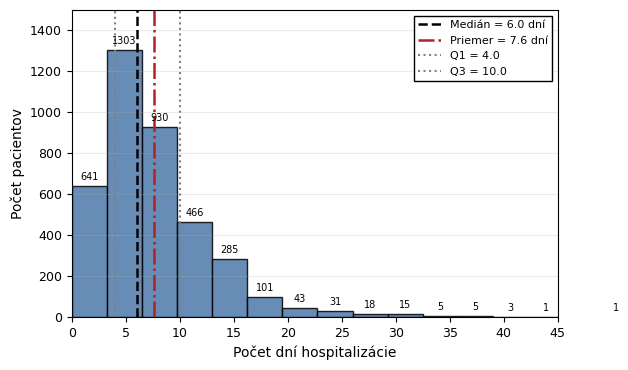

In [99]:
# vyčistenie dát
los = df_epi['Pocet dni hosp.'].dropna()
los = los[los >= 0]

# základné štatistiky
median_los = los.median()
q1 = los.quantile(0.25)
q3 = los.quantile(0.75)
mean_los = los.mean()

plt.figure(figsize=(6.4, 3.8))

counts, bins, patches = plt.hist(
    los,
    bins=16,   # menej binov = lepšia čitateľnosť
    color='#4C78A8',
    edgecolor='black',
    alpha=0.85
)

# početnosti nad stĺpcami
y_offset = max(counts) * 0.015

for count, left, right in zip(counts, bins[:-1], bins[1:]):
    if count > 0:
        x = (left + right) / 2
        y = count
        plt.text(
            x, y + y_offset,
            f'{int(count)}',
            ha='center',
            va='bottom',
            fontsize=7
        )

# štatistické čiary
plt.axvline(
    median_los,
    color='black',
    linestyle='--',
    linewidth=1.8,
    label=f'Medián = {median_los:.1f} dní'
)

plt.axvline(
    mean_los,
    color='#B22222',
    linestyle='-.',
    linewidth=1.8,
    label=f'Priemer = {mean_los:.1f} dní'
)

plt.axvline(
    q1,
    color='gray',
    linestyle=':',
    linewidth=1.5,
    label=f'Q1 = {q1:.1f}'
)

plt.axvline(
    q3,
    color='gray',
    linestyle=':',
    linewidth=1.5,
    label=f'Q3 = {q3:.1f}'
)

plt.xlabel('Počet dní hospitalizácie', fontsize=10)
plt.ylabel('Počet pacientov', fontsize=10)

plt.xticks(fontsize=9)
plt.yticks(fontsize=9)

plt.grid(axis='y', alpha=0.25)
plt.xlim(0, 45)

plt.ylim(0, max(counts) * 1.15)

# legenda s orámovaním
legend = plt.legend(
    fontsize=8,
    frameon=True,
    fancybox=False,
    edgecolor='black',
    loc='upper right'
)
legend.get_frame().set_alpha(1)

plt.tight_layout()

#plt.savefig('histogram_los_word.png', dpi=300, bbox_inches='tight')
#plt.savefig('histogram_los_word.pdf', bbox_inches='tight')

plt.show()

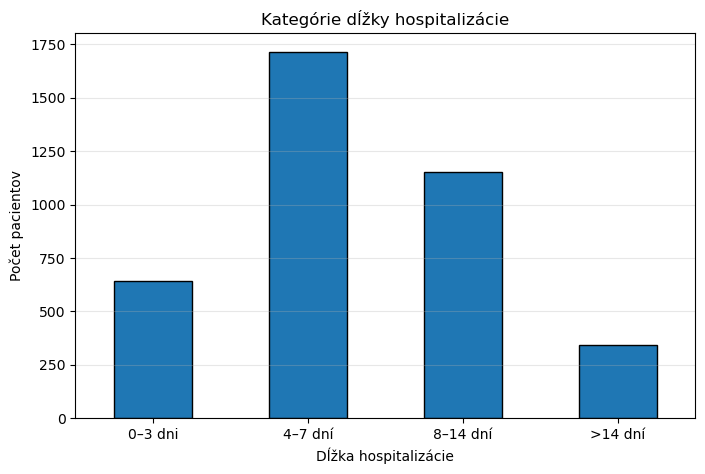

Kategoria hospitalizacie
0–3 dni      641
4–7 dní     1716
8–14 dní    1150
>14 dní      341
Name: count, dtype: int64
Kategoria hospitalizacie
0–3 dni     16.7
4–7 dní     44.6
8–14 dní    29.9
>14 dní      8.9
Name: count, dtype: float64


In [100]:
bins = [-1, 3, 7, 14, np.inf]
labels = ['0–3 dni', '4–7 dní', '8–14 dní', '>14 dní']

df_epi['Kategoria hospitalizacie'] = pd.cut(
    df_epi['Pocet dni hosp.'],
    bins=bins,
    labels=labels
)

category_counts = df_epi['Kategoria hospitalizacie'].value_counts().sort_index()

plt.figure(figsize=(8, 5))
category_counts.plot(kind='bar', edgecolor='black')

plt.title('Kategórie dĺžky hospitalizácie')
plt.xlabel('Dĺžka hospitalizácie')
plt.ylabel('Počet pacientov')
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)
plt.show()

print(category_counts)
print((category_counts / category_counts.sum() * 100).round(1))

## 3. Reorganizácia stĺpcov a čistenie dát

Funkcia `build_lab_columns` zostaví pre každý laboratórny parameter blok 12 odvodených stĺpcov
(surová hodnota, prvá/posledná hodnota + status + dátum, minimum, medián, maximum).

`reorder_df_epi` následne zoradí celý DataFrame do logickej štruktúry:
**identifikácia pacienta → laboratórne bloky → počty abnormalít → ostatné stĺpce.**
Chýbajúce stĺpce sú vypísané do konzoly bez prerušenia behu.

In [101]:
columns_to_check = [
    'S-Bil-T', 'S-AST', 'S-ALT', 'S-GMT', 'S-ALP', 'S-Chol', 'S-CB', 'S-Na', 'S-K', 'S-CL',
    'S-IgG', 'S-IgA', 'S-Ig M', 'S-CRP', 'S-Alb', 'S-Bil-D', 'S-Gluk', 'S-Urea', 'S-Kreat',
    'S-KM', 'S-AMS', 'S-CK', 'S-CK-MB', 'S-LD', 'P-Laktát', 'S-FER', 'HGB', 'WBC', 'PLT',
    'Neu abs', 'Eo abs', 'Ly abs', 'PT (INR)', 'APTT-R', 'Fib', 'CD3+', 'CD4+', 'CD8+',
    'CD4+/CD8+', 'PDW', 'S-PBNP', 'S-IL6', 'CD19+', 'NK', 'S-VITD', 'NE/LY(NLR)', 'D-dimér HS'
]

def build_lab_columns(df: pd.DataFrame, labs: List[str]) -> List[str]:
    df_cols = list(df.columns)
    lab_cols: List[str] = []
    missing_cols: List[str] = []

    for lab in labs:
        block = [
    lab,

    f"{lab}_prva_hodnota",
    f"{lab}_prva_ref_status",
    f"{lab}_prva_allowed_status",
    f"{lab}_datum_prva_hodnota",

    f"{lab}_minimum",
    f"{lab}_median",
    f"{lab}_maximum",

    f"{lab}_posledna_hodnota",
    f"{lab}_posledna_ref_status",
    f"{lab}_posledna_allowed_status",
    f"{lab}_datum_posledna_hodnota",
]

        for target in block:
            if target in df_cols:
                lab_cols.append(target)
            else:
                missing_cols.append(target)

    if missing_cols:
        print("\nCHÝBAJÚCE LAB STĹPCE PRI ÚPRAVE:")
        for col in missing_cols:
            print(f"{col} chýba pri úprave")
        print("--------------------------------------------------\n")

    return lab_cols


def reorder_df_epi(df_epi: pd.DataFrame, labs: List[str]) -> pd.DataFrame:
    header_cols = [
        "Poradie","Meno","Pohlavie","Vek","vlna","Dátum príjmu","Kód príjmu",
        "Dátum prepustenia","Kód prepustenia","Pocet dni hosp.","Stav prepustenia",
        "HLN Dg.","Diagnózy","DRG výkony","Liečba","SVLZ správy","Mikrobiológia ",
        "Epikríza","Terajšie ochorenie","Dôvod hospitalizácie","Objektívny nález",
        "Osobná anamnéza","Lieková anamnéza","Návyková anamnéza",
        "Epidemiologická anamnéza",
    ]

    abnormal_cols = [
        "Pocet_abn_prva_ref",
        "Pocet_abn_prva_allowed",
        "Pocet_abn_posledna_ref",
        "Pocet_abn_posledna_allowed",
    ]

    # kontrola hlavičkových stĺpcov
    missing_header = [c for c in header_cols if c not in df_epi.columns]
    if missing_header:
        print("\nCHÝBAJÚCE HLAVIČKOVÉ STĹPCE:")
        for col in missing_header:
            print(f" {col} chýba pri úprave")
        print("--------------------------------------------------\n")

    header_existing = [c for c in header_cols if c in df_epi.columns]

    # lab stĺpce + kontrola
    lab_cols = build_lab_columns(df_epi, labs)

    # počty abnormalít až za všetkými lab testami
    abnormal_existing = [c for c in abnormal_cols if c in df_epi.columns]

    missing_abnormal = [c for c in abnormal_cols if c not in df_epi.columns]
    if missing_abnormal:
        print("\nCHÝBAJÚCE STĹPCE POČTU ABNORMALÍT:")
        for col in missing_abnormal:
            print(f"{col} chýba pri úprave")
        print("--------------------------------------------------\n")

    # ostatné stĺpce, ktoré nie sú v hlavičke ani v lab blokoch ani v abnormal counts
    used_cols = set(header_existing + lab_cols + abnormal_existing)
    remaining_cols = [c for c in df_epi.columns if c not in used_cols]

    new_order = header_existing + lab_cols + abnormal_existing + remaining_cols

    df_final = df_epi.loc[:, new_order].copy()

    return df_final


df_final = reorder_df_epi(df_epi, columns_to_check)
df_final.head()

,Poradie,Meno,Pohlavie,Vek,vlna,Dátum príjmu,Kód príjmu,Dátum prepustenia,Kód prepustenia,Pocet dni hosp.,...,D-dimér HS_maximum,D-dimér HS_posledna_hodnota,D-dimér HS_posledna_ref_status,D-dimér HS_posledna_allowed_status,D-dimér HS_datum_posledna_hodnota,Pocet_abn_prva_ref,Pocet_abn_prva_allowed,Pocet_abn_posledna_ref,Pocet_abn_posledna_allowed,Kategoria hospitalizacie
0,1,WMHAMJXUHHAEZEHBMNRM,Žena,75,1,2020-11-23,1,2020-11-30,1,7,...,0.897,0.897,high,normal,2020-11-28,14,0,16,0,4–7 dní
1,2,WMHAMJHBMHPKDJOQLNAH,Žena,65,1,2020-12-24,1,2021-01-06,1,13,...,1.086,1.082,high,normal,2020-12-29,11,0,13,0,8–14 dní
2,3,BJHAMJHJYYFMYGYGUAMT,Žena,64,1,2020-12-12,1,2020-12-26,6,14,...,1.034,0.694,high,normal,2020-12-16,27,0,26,0,8–14 dní
3,4,KXHAMJTAHMEVZFLVULVZ,Muž,67,1,2020-12-16,1,2020-12-21,1,5,...,0.301,0.301,normal,normal,2020-12-17,9,0,9,0,4–7 dní
4,5,TBHAMJTMUMUUJKDBNYED,Muž,82,1,2020-12-18,1,2020-12-21,6,3,...,14.242,14.242,high,high,2020-12-18,21,1,20,1,0–3 dni


In [102]:
len(columns_to_check)


47

In [103]:
print(df_final["Stav prepustenia"])

0        prepustenie amb. star.
1       neznamy alebo prelozeny
2                exitus letalis
3        prepustenie amb. star.
4                exitus letalis
                 ...           
3843    neznamy alebo prelozeny
3844     prepustenie amb. star.
3845     prepustenie amb. star.
3846     prepustenie amb. star.
3847     prepustenie amb. star.
Name: Stav prepustenia, Length: 3848, dtype: object


### 3.1 Prečíslovanie záznamov

Po zlúčení a reorganizácii stĺpcov sa poradie pacientov resetuje na súvislý rozsah 1 až 3848.
Výsledkom je `df_final` s konzistentným indexom bez medzier po filtrovaní.

In [104]:
df_final['Poradie'] = range(1,len(df_final)+1)
print(df_final['Poradie'].head())
print(df_final['Poradie'].tail())

0    1
1    2
2    3
3    4
4    5
Name: Poradie, dtype: int64
3843    3844
3844    3845
3845    3846
3846    3847
3847    3848
Name: Poradie, dtype: int64


In [105]:
print(df_final.head(),"\n\n")
print(df_final['Stav prepustenia'].value_counts())

   Poradie                  Meno Pohlavie  Vek  vlna Dátum príjmu  Kód príjmu  \
0        1  WMHAMJXUHHAEZEHBMNRM     Žena   75     1   2020-11-23           1   
1        2  WMHAMJHBMHPKDJOQLNAH     Žena   65     1   2020-12-24           1   
2        3  BJHAMJHJYYFMYGYGUAMT     Žena   64     1   2020-12-12           1   
3        4  KXHAMJTAHMEVZFLVULVZ      Muž   67     1   2020-12-16           1   
4        5  TBHAMJTMUMUUJKDBNYED      Muž   82     1   2020-12-18           1   

  Dátum prepustenia  Kód prepustenia  Pocet dni hosp.  ... D-dimér HS_maximum  \
0        2020-11-30                1                7  ...              0.897   
1        2021-01-06                1               13  ...              1.086   
2        2020-12-26                6               14  ...              1.034   
3        2020-12-21                1                5  ...              0.301   
4        2020-12-21                6                3  ...             14.242   

  D-dimér HS_posledna_hodn

## 4. Klasifikácia prepustení pacientov na základe stĺpca "Epikríza"

Táto kapitola slúži na odvodenie stavu prepustenia pacienta z textového poľa `Epikríza`.  
Pomocou textovej klasifikácie sa identifikujú prípady, pri ktorých bol pacient prepustený do ambulantnej starostlivosti, preložený na iné pracovisko, hospitalizovaný na JIS/KICM/ARO/OAIM alebo počas hospitalizácie zomrel.

V rámci tejto časti sa:

- aplikuje funkcia na klasifikáciu prepustenia podľa obsahu epikrízy,
- ošetria prázdne, neúplné alebo šablónové epikrízy,
- doplní nový stĺpec `Stav prepustenia`,
- výsledky sa skontrolujú pomocou frekvenčného rozdelenia a náhľadu dát.

In [106]:
def classify_department(text: str) -> str:
    txt = normalize_text(text)

    # Univerzálne vzory pre kľúčové akcie a názvy oddelení
    transfer_keywords = r'(preklad|prelozen[yae]|prekladame|presun|presunut[ya]|prijat[yae]|prijem)'
    # Slovník s mapovaním názvu oddelenia a jeho kľúčových slov
    department_keywords = {
        "preklad na OAIM": r'oaim',
        "preklad na KAIM": r'kaim',
        "preklad na AIM": r'aim',
        "preklad na ARO": r'aro',
        "preklad na kliniku infektológie": r'klinik[aeu].*infektolog'
    }

    for dept_name, dept_pattern in department_keywords.items():   
        pattern = re.compile(f'({transfer_keywords}).{{0,30}}({dept_pattern})')
        if re.search(pattern, txt):
            return dept_name
            
    # Ak sa nenájde žiadna zhoda, vráti sa predvolená hodnota
    return "nezaradené / nenašlo sa"


Výsledný DataFrame po úprave stĺpca 'Stav prepustenia':
Stav prepustenia
prepustenie amb. star.     2427
neznamy alebo prelozeny     831
exitus letalis              343
Nejasna epikriza            144
???                         103
Name: count, dtype: int64
Stav prepustenia
prepustenie amb. star.     2427
neznamy alebo prelozeny     831
exitus letalis              343
Nejasna epikriza            144
???                         103
Name: count, dtype: int64


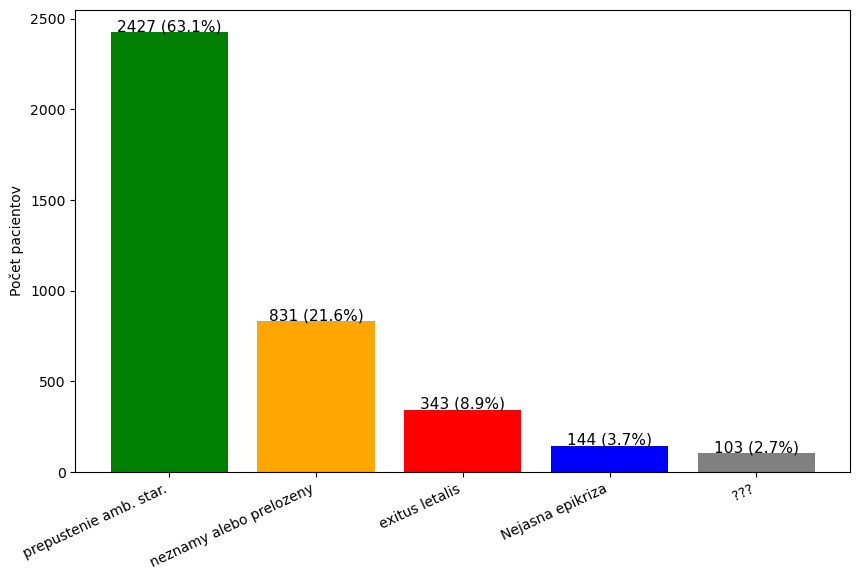

In [107]:
# Nasadenie na DataFrame 
df_epik = df_final.copy()

# Klasifikácia stĺpca 'Epikríza'
classification_series = df_epik['Epikríza'].apply(classify_department)

aro_oaim_mask = (classification_series == "preklad na ARO") | (classification_series == "preklad na OAIM")| (classification_series == "preklad na KAIM") | (classification_series == "preklad na AIM")| (classification_series == "preklad na kliniku infektológie")

# Zobrazenie výsledného DataFrame
print("Výsledný DataFrame po úprave stĺpca 'Stav prepustenia':")
print(df_epik['Stav prepustenia'].value_counts())

counts = df_epik["Stav prepustenia"].value_counts()
percents = counts / len(df_epik) * 100

print(counts)

plt.figure(figsize=(10,6))

# Klinické farby (môžeš upraviť)
color_map = {
    "prepustenie amb. star.": "green",
    "neznamy alebo prelozeny": "orange",
    "Nejasna epikriza": "blue",
    "exitus letalis": "red",
    "???": "gray"
}

# farby podľa kategórie
colors = [color_map.get(cat, "gray") for cat in counts.index]

bars = plt.bar(counts.index, counts.values, color=colors)

plt.ylabel("Počet pacientov")
plt.xticks(rotation=25, ha="right")

# Popisky nad stĺpce
for i, bar in enumerate(bars):
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 5,
        f"{counts.values[i]} ({percents.values[i]:.1f}%)",
        ha="center",
        fontsize=11
    )

plt.show()



### 4.1 Detekcia preložení pacientov na JIS a iné klinické jednotky

Kód prepustenia 3 alebo 4 označuje preloženie pacienta, no nedáva informáciu
o tom, na *ktorú* jednotku bol pacient preložený. Túto informáciu extrahujeme
priamo z textu Epikrízy.

`find_jis_mentions` klasifikuje každý záznam do jednej z 5 kategórií podľa
sily signálu: `JIS_KICM` (JIS infektologickej kliniky) → `KICM` → `JIS`
(iná jednotka intenzívnej starostlivosti) → `KPaF` → `VŠOUG`.

Graf následne ukazuje, koľko pacientov z každej kategórie má kód prepustenia
3 alebo 4 (očakávaný kód pri preložení) oproti ostatným kódom — čo pomáha
odhaliť záznamy kde kód prepustenia nezodpovedá skutočnosti zachytenej v texte.

In [108]:
def find_consecutive_terms(df: pd.DataFrame, column_name: str, term1: str, term2: str) -> pd.DataFrame:
    """Vráti riadky, kde sa v stĺpci column_name nachádza term1 nasledovaný term2."""
    pattern = f'{term1}.*{term2}'
    return df[df[column_name].str.contains(pattern, case=False, na=False, regex=True)]

df_vysledok = find_consecutive_terms(df_epik, 'Epikríza', 'JIS', 'KICM')
print(df_vysledok.shape[0])

53


In [109]:
def find_jis_mentions(
    df: pd.DataFrame,
    column_name: str = "Epikríza",
) -> pd.DataFrame:
    """
    Hierarchia (od najsilnejšieho signálu):
      1) JIS_KICM  — JIS a KICM do 50 znakov od seba
      2) KICM      — KICM bez JIS v blízkosti
      3) JIS       — JIS bez KICM v blízkosti
      4) KPaF      — zmienka o KPaF
      5) VŠOUG     — zmienka o VŠOUG / sv. Lukáš / Lukáša
    """
    text = df[column_name].fillna("").astype(str).str.lower()

    # ── Masky ───────────────────────────────────────────────

    mask_jis_kicm = text.str.contains(
        r"\bjis\b.{0,50}?\bkicm\b|\bkicm\b.{0,50}?\bjis\b",
        regex=True, na=False
    )

    mask_kicm_samo = (
        text.str.contains(r"\bkicm\b", regex=True, na=False)
        & ~mask_jis_kicm
    )

    mask_jis_samo = (
        text.str.contains(r"\bjis\b", regex=True, na=False)
        & ~mask_jis_kicm
    )

    mask_kpaf = text.str.contains(
        r"\bkpaf\b",
        regex=True, na=False
    )

    mask_vsoug = text.str.contains(
        r"\b(?:všoug|vsoug)\b|sv\.?\s*luk[aá][šs]|luk[aá]š\w*",
        regex=True, na=False
    )

    # ── Priradenie kategórie (priorita zhora) ────────────────
    any_mask = (
        mask_jis_kicm | mask_kicm_samo | mask_jis_samo |
        mask_kpaf | mask_vsoug
    )

    typ = pd.Series(pd.NA, index=df.index, dtype="object")
    typ[mask_vsoug]     = "VŠOUG"
    typ[mask_kpaf]      = "KPaF"
    typ[mask_jis_samo]  = "JIS"
    typ[mask_kicm_samo] = "KICM"
    typ[mask_jis_kicm]  = "JIS_KICM"

    out = df.copy()
    out["jednotka_typ"] = typ
    return out[any_mask]


# ── Použitie ─────────────────────────────────────────────────
df_jed = find_jis_mentions(df_epik, "Epikríza")

print(f"Spolu záznamov: {len(df_jed)}")
print("\nRozdelenie podľa typu:")
print(df_jed["jednotka_typ"].value_counts())

Spolu záznamov: 647

Rozdelenie podľa typu:
jednotka_typ
KICM        343
VŠOUG        97
KPaF         87
JIS          70
JIS_KICM     50
Name: count, dtype: int64


In [110]:
df_jed = find_jis_mentions(df_epik, "Epikríza")

# Informatívne — pozri ako sa rozkladajú kódy prepustenia
print(df_jed.groupby("jednotka_typ")["Kód prepustenia"].value_counts())

jednotka_typ  Kód prepustenia
JIS           3                   57
              6                    7
              1                    3
              4                    2
              7                    1
JIS_KICM      3                   46
              1                    2
              6                    2
KICM          1                  198
              3                   48
              4                   32
              7                   29
              6                   21
              5                    9
              2                    5
              10                   1
KPaF          1                   61
              3                   21
              6                    4
              2                    1
VŠOUG         4                   80
              2                    8
              1                    3
              3                    3
              6                    1
              7                    1
        

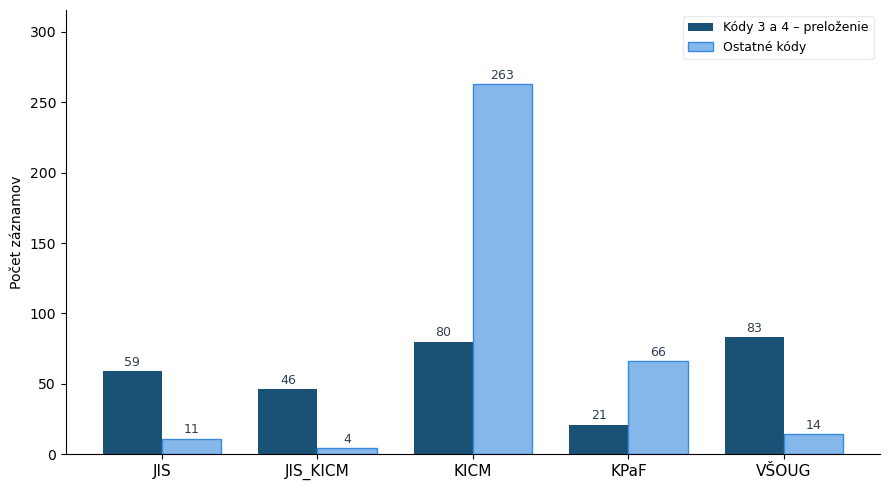

In [111]:
# ── Výpočet z df_jed ─────────────────────────────────────────
categories = ["JIS", "JIS_KICM", "KICM", "KPaF", "VŠOUG"]

counts_34  = []
counts_ost = []

for cat in categories:
    subset = df_jed[df_jed["jednotka_typ"] == cat]["Kód prepustenia"]
    counts_34.append(subset.isin([3, 4]).sum())
    counts_ost.append((~subset.isin([3, 4])).sum())

# ── Graf ─────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 5))

x     = np.arange(len(categories))
width = 0.38

bars1 = ax.bar(x - width/2, counts_34,  width, label="Kódy 3 a 4 – preloženie",
               color="#1A5276", edgecolor="white", linewidth=0)
bars2 = ax.bar(x + width/2, counts_ost, width, label="Ostatné kódy",
               color="#85B7EB", edgecolor="#378ADD", linewidth=1)

for bar, val in zip(list(bars1) + list(bars2), counts_34 + counts_ost):
    if val > 0:
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 1.5,
            str(val),
            ha="center", va="bottom", fontsize=9, color="#2C3E50"
        )

ax.set_xticks(x)
ax.set_xticklabels(categories, fontsize=11)
ax.set_ylabel("Počet záznamov", fontsize=10)
ax.legend(fontsize=9, framealpha=0.4)
ax.spines[["top", "right"]].set_visible(False)
ax.set_ylim(0, max(counts_ost) * 1.2)

plt.tight_layout()

plt.show()

### 4.2 Extrakcia informácie o UPV (Umelej pľúcnej ventilácii)

Z textu Epikrízy sa pomocou regulárnych výrazov identifikujú pacienti,
u ktorých bola počas hospitalizácie nasadená umelá pľúcna ventilácia.
Rozlišujú sa rôzne formy zápisu (UPV, umelá ventilácia, pľúcna ventilácia)
a výsledok sa porovnáva s kódom prepustenia

In [112]:
df_vysledok['Epikríza'] = df_vysledok['Epikríza'].apply(normalize_text)


ventilacia_pattern = r'(?:umel.?|plucn.?)? ?ventilaci.?|upv'

match_mask = df_vysledok['Epikríza'].str.contains(
    ventilacia_pattern,
    regex=True,
    na=False
)


count = match_mask.sum()
print(f"Celkový počet riadkov s hľadanými frázami: {count}\n")

filtered_df = df_vysledok[match_mask]
print("Riadky, ktoré obsahujú hľadané frázy:")
print(filtered_df[['Poradie', 'Epikríza','Kód prepustenia']])

Celkový počet riadkov s hľadanými frázami: 2

Riadky, ktoré obsahujú hľadané frázy:
      Poradie                                           Epikríza  \
1769     1770  epikriza: 56- rocny diabetik prijaty na jis ki...   
1941     1942  75- rocny pacient, bez vyznamneho predchorobia...   

      Kód prepustenia  
1769                3  
1941                1  


C:\Users\DELL\AppData\Local\Temp\ipykernel_31484\271009247.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_vysledok['Epikríza'] = df_vysledok['Epikríza'].apply(normalize_text)


In [113]:
terms = {
    "UPV": [
        "upv",
        "umela plucna ventilacia",
        "umela pulmonalna ventilacia",
        "umela ventilacia",
        "plucna ventilacia"
    ]
}

search_dict = {}

for canonical, variants in terms.items():
    for variant in variants:
        search_dict[normalize_text(variant)] = canonical


def najdi_pojmy(df: pd.DataFrame, text_col: str, kod_col: str):
    vysledky = []

    for idx, row in df.iterrows():
        text = normalize_text(str(row[text_col])) if pd.notnull(row[text_col]) else ""

        for variant, canonical in search_dict.items():
            if variant in text:
                vysledky.append({
                    "index": idx,
                    "Poradie": row["Poradie"],
                    "Kód prepustenia": row[kod_col],
                    "Stav prepustenia": row["Stav prepustenia"],
                    "najdeny_pojem": canonical,
                    "najdeny_variant": variant
                })
                break

    return pd.DataFrame(vysledky)

df_upv = df_epik.copy()

vysledky_upv = najdi_pojmy(
    df=df_upv,
    text_col="Epikríza",
    kod_col="Kód prepustenia"
)

print(f"Počet riadkov s UPV: {len(vysledky_upv)}")

if not vysledky_upv.empty:
    print("\nDetaily riadkov:")
    print(vysledky_upv)
else:
    print("Žiadne riadky nenájdené.")

Počet riadkov s UPV: 73

Detaily riadkov:
    index  Poradie  Kód prepustenia         Stav prepustenia najdeny_pojem  \
0       2        3                6           exitus letalis           UPV   
1      25       26                3  neznamy alebo prelozeny           UPV   
2      36       37                1   prepustenie amb. star.           UPV   
3      87       88                4  neznamy alebo prelozeny           UPV   
4     110      111                3  neznamy alebo prelozeny           UPV   
..    ...      ...              ...                      ...           ...   
68   3338     3339                1   prepustenie amb. star.           UPV   
69   3373     3374                4  neznamy alebo prelozeny           UPV   
70   3612     3613                7           exitus letalis           UPV   
71   3657     3658                1   prepustenie amb. star.           UPV   
72   3671     3672                3  neznamy alebo prelozeny           UPV   

   najdeny_variant  


In [114]:

terms = {
    "UPV": [
        "upv",
        "umela plucna ventilacia",
        "umela pulmonalna ventilacia",
        "umela ventilacia",
        "plucna ventilacia"
    ],
    "Oxygenoterapia": [
        "oxygenoterapia",
        "oxygenoterapii",
        "oxygenoterapiou",
        "kyslikova terapia",
        "kyslikova liecba",
        "podavanie kyslika",
        "aplikacia kyslika",
        "inhalacia kyslika",
        "O2 terapia",
        "terapia kyslikom",
        "vysokoprutokovy kyslik",
        "high flow",
        "highflow",
        "hfno",                    # high flow nasal oxygen
        "neinvazivna ventilacia",
        "niv",                     # non-invasive ventilation
        "cpap",
        "bipap"
    ]
}

search_dict = {}
for canonical, variants in terms.items():
    for variant in variants:
        search_dict[normalize_text(variant)] = canonical


def najdi_pojmy(df: pd.DataFrame, text_col: str, kod_col: str):
    vysledky = []

    for idx, row in df.iterrows():
        text = normalize_text(str(row[text_col])) if pd.notnull(row[text_col]) else ""

        # Pre každý riadok hľadáme všetky pojmy — nie len prvý
        najdene = {}
        for variant, canonical in search_dict.items():
            if variant in text and canonical not in najdene:
                najdene[canonical] = variant

        for canonical, variant in najdene.items():
            vysledky.append({
                "index"            : idx,
                "Poradie"          : row["Poradie"],
                "Kód prepustenia"  : row[kod_col],
                "Stav prepustenia" : row["Stav prepustenia"],
                "najdeny_pojem"    : canonical,
                "najdeny_variant"  : variant
            })

    return pd.DataFrame(vysledky)


df_upv = df_epik.copy()

vysledky_upv = najdi_pojmy(
    df=df_upv,
    text_col="Epikríza",
    kod_col="Kód prepustenia"
)

# ── Súhrnné výsledky ─────────────────────────────────────────

print("SÚHRN NÁJDENÝCH POJMOV")

print(vysledky_upv["najdeny_pojem"].value_counts())

upv_count  = len(vysledky_upv[vysledky_upv["najdeny_pojem"] == "UPV"])
oxy_count  = len(vysledky_upv[vysledky_upv["najdeny_pojem"] == "Oxygenoterapia"])
both_count = len(
    vysledky_upv[vysledky_upv["najdeny_pojem"] == "UPV"]["index"]
    .isin(vysledky_upv[vysledky_upv["najdeny_pojem"] == "Oxygenoterapia"]["index"])
    .pipe(lambda s: s[s])
)

print(f"\nUPV                     : {upv_count}")
print(f"Oxygenoterapia          : {oxy_count}")
print(f"Oboje súčasne           : {both_count}")

# ── Kontrast výsledkov hospitalizácie ────────────────────────
print("\nKódy prepustenia — UPV:")
print(vysledky_upv[vysledky_upv["najdeny_pojem"] == "UPV"]
      ["Kód prepustenia"].value_counts())

print("\nKódy prepustenia — Oxygenoterapia:")
print(vysledky_upv[vysledky_upv["najdeny_pojem"] == "Oxygenoterapia"]
      ["Kód prepustenia"].value_counts())


SÚHRN NÁJDENÝCH POJMOV
najdeny_pojem
Oxygenoterapia    2144
UPV                 73
Name: count, dtype: int64

UPV                     : 73
Oxygenoterapia          : 2144
Oboje súčasne           : 56

Kódy prepustenia — UPV:
Kód prepustenia
6    33
3    24
1     7
4     5
7     4
Name: count, dtype: int64

Kódy prepustenia — Oxygenoterapia:
Kód prepustenia
1     1364
3      244
6      215
4      149
7      116
5       31
2       22
10       2
12       1
Name: count, dtype: int64


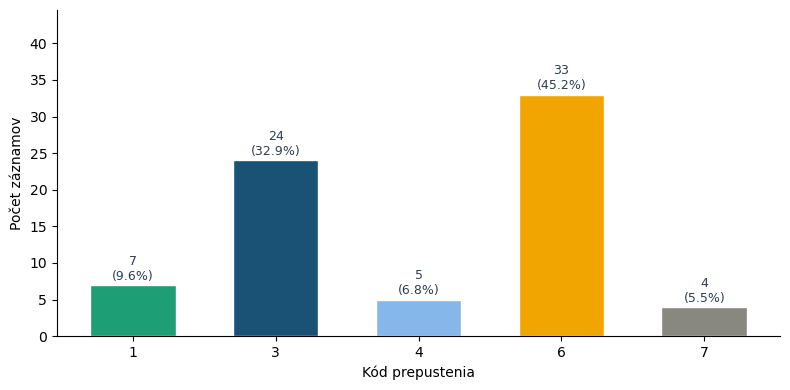

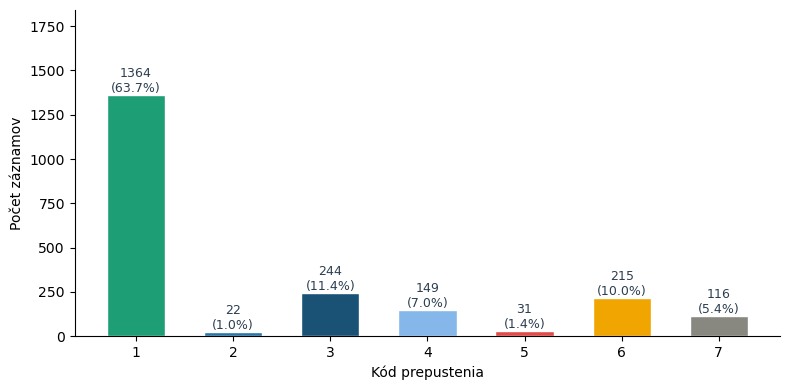

In [115]:
VYNECHANE_KODY = [10, 12]

kod_colors = {
    1 : "#1D9E75",   # prepustenie domov – zelená
    2 : "#2874A6",   # preloženie v rámci – modrá
    3 : "#1A5276",   # preloženie do iného nem. – tmavá modrá
    4 : "#85B7EB",   # preloženie na iné odd. – svetlá modrá
    5 : "#E24B4A",   # exitus – červená
    6 : "#F0A500",   # odchod proti rade – žltá
    7 : "#888780",   # iné – šedá
    8 : "#6C3483",   # útok – fialová
    9 : "#A569BD",   # neoprávnené – svetlá fialová
}
# ── UPV ──────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 4))

subset_upv = vysledky_upv[
    (vysledky_upv["najdeny_pojem"] == "UPV") &
    (~vysledky_upv["Kód prepustenia"].isin(VYNECHANE_KODY))
]
counts_upv = subset_upv["Kód prepustenia"].value_counts().sort_index()
colors_upv = [kod_colors.get(k, "#888780") for k in counts_upv.index]

bars = ax.bar(
    range(len(counts_upv)), counts_upv.values,
    color=colors_upv, edgecolor="white", width=0.6
)
for bar, val in zip(bars, counts_upv.values):
    pct = round(val / counts_upv.sum() * 100, 1)
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.3,
        f"{val}\n({pct}%)",
        ha="center", va="bottom", fontsize=9, color="#2C3E50"
    )

ax.set_xticks(range(len(counts_upv)))
ax.set_xticklabels(
    [str(k) for k in counts_upv.index],
    fontsize=10
)
ax.set_xlabel("Kód prepustenia", fontsize=10)
ax.set_ylabel("Počet záznamov", fontsize=10)
# ax.set_title(f"UPV  (n={len(subset_upv)})", fontsize=12, fontweight="bold", pad=10)
ax.spines[["top", "right"]].set_visible(False)
ax.set_ylim(0, counts_upv.max() * 1.35)

plt.tight_layout()
#plt.savefig("viz_upv_kody.png", dpi=150, bbox_inches="tight")
plt.show()


# ── Oxygenoterapia ────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 4))

subset_oxy = vysledky_upv[
    (vysledky_upv["najdeny_pojem"] == "Oxygenoterapia") &
    (~vysledky_upv["Kód prepustenia"].isin(VYNECHANE_KODY))
]
counts_oxy = subset_oxy["Kód prepustenia"].value_counts().sort_index()
colors_oxy = [kod_colors.get(k, "#888780") for k in counts_oxy.index]

bars = ax.bar(
    range(len(counts_oxy)), counts_oxy.values,
    color=colors_oxy, edgecolor="white", width=0.6
)
for bar, val in zip(bars, counts_oxy.values):
    pct = round(val / counts_oxy.sum() * 100, 1)
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.3,
        f"{val}\n({pct}%)",
        ha="center", va="bottom", fontsize=9, color="#2C3E50"
    )

ax.set_xticks(range(len(counts_oxy)))
ax.set_xticklabels(
    [str(k) for k in counts_oxy.index],
    fontsize=10
)
ax.set_xlabel("Kód prepustenia", fontsize=10)
ax.set_ylabel("Počet záznamov", fontsize=10)
# ax.set_title(f"Oxygenoterapia  (n={len(subset_oxy)})", fontsize=12, fontweight="bold", pad=10)
ax.spines[["top", "right"]].set_visible(False)
ax.set_ylim(0, counts_oxy.max() * 1.35)

plt.tight_layout()
#plt.savefig("viz_oxygenoterapia_kody.png", dpi=150, bbox_inches="tight")
plt.show()

### 4.3 Extrakcia ARO/OAIM pacientov

Z textu Epikrízy sa identifikujú pacienti, ktorí boli počas hospitalizácie
preložení na Anesteziologicko-resuscitačné oddelenie (ARO) alebo
Oddelenie anesteziológie a intenzívnej medicíny (OAIM).

Porovnávajú sa dva varianty filtrovania podľa kódu prepustenia —
širší (kódy 1–5) a konzervatívny (kódy 3–4) — aby sa minimalizovalo
riziko zachytenia pacientov s chybne priradeným kódom.

In [116]:

df_aro = df_epik.copy()

# Variant A: Zahŕňa aj pacientov, ktorí môžu mať chybne priradený kód prepustenia.
codes_aro_check_all = [1, 2, 3, 4, 5]

# Variant B: Zahŕňa len kódy, ktoré primárne reprezentujú preloženie.
codes_aro_check_34 = [3, 4]

keywords_aro = ["ARO", "OAIM", "KAIM", "KAICM"]

regex_aro = re.compile(
    r"\b(" + "|".join(keywords_aro) + r")\b",
    re.IGNORECASE
)


def find_aro_matches(df, codes_to_check):
    """
    Vyhľadá pacientov, u ktorých sa v epikríze nachádza zmienka
    o ARO/OAIM/KAIM/KAICM a zároveň majú vybraný Kód prepustenia.
    """

    df_candidates = df[
        df["Kód prepustenia"].isin(codes_to_check)
    ].copy()

    mask_aro = df_candidates["Epikríza"].apply(
        lambda text: bool(regex_aro.search(str(text)))
    )

    df_matches = df_candidates.loc[
        mask_aro,
        ["Poradie", "Kód prepustenia", "Stav prepustenia", "Epikríza"]
    ].copy()

    return df_candidates, df_matches

# Vyhľadanie ARO/OAIM pri širšom variante kódov 1–5
df_candidates_all, df_matches_all = find_aro_matches(
    df=df_epik,
    codes_to_check=codes_aro_check_all
)

# Vyhľadanie ARO/OAIM pri konzervatívnom variante kódov 3–4
df_candidates_34, df_matches_34 = find_aro_matches(
    df=df_epik,
    codes_to_check=codes_aro_check_34
)

# Porovnanie výsledkov
print("Porovnanie filtrov ARO/OAIM")
print("-" * 40)

print(f"Kódy {codes_aro_check_all}:")
print(f"Počet kontrolovaných riadkov: {len(df_candidates_all)}")
print(f"Počet ARO/OAIM nálezov: {len(df_matches_all)}")

print(f"\nKódy {codes_aro_check_34}:")
print(f"Počet kontrolovaných riadkov: {len(df_candidates_34)}")
print(f"Počet ARO/OAIM nálezov: {len(df_matches_34)}")

# Pacienti zachytení iba širším filtrom
extra_aro_matches = df_matches_all[
    ~df_matches_all.index.isin(df_matches_34.index)
].copy()

print(f"Počet pacientov navyše pri širšom filtri: {len(extra_aro_matches)}")

extra_aro_matches[
    ["Poradie", "Kód prepustenia", "Stav prepustenia", "Epikríza"]
]

Porovnanie filtrov ARO/OAIM
----------------------------------------
Kódy [1, 2, 3, 4, 5]:
Počet kontrolovaných riadkov: 3408
Počet ARO/OAIM nálezov: 77

Kódy [3, 4]:
Počet kontrolovaných riadkov: 774
Počet ARO/OAIM nálezov: 71
Počet pacientov navyše pri širšom filtri: 6


,Poradie,Kód prepustenia,Stav prepustenia,Epikríza
36,37,1,prepustenie amb. star.,67-ročný pozit. Ag COVID-19 pacient v rámci c...
375,376,1,prepustenie amb. star.,38-ročný pacient bol dňa 9.10.2020 pozitívne t...
1038,1039,1,neznamy alebo prelozeny,38- ročný COVID-19 pozitívny pacient prijatý p...
1751,1752,1,neznamy alebo prelozeny,49-ročný nonkompliantný pacient s chronickým s...
2250,2251,1,neznamy alebo prelozeny,46-ročná pacientka anamnesticky bez iných záva...
3527,3528,5,neznamy alebo prelozeny,Epikríza: 77-ročný polymorbídny pacient bez v...


In [117]:
df_aro = df_epik.copy()

df_aro.loc[
    df_matches_all.index,
    "Stav prepustenia"
] = "ARO/OAIM"

# Konzervatívny variant ponechaný na porovnanie
df_aro_conservative = df_epik.copy()

df_aro_conservative.loc[
    df_matches_34.index,
    "Stav prepustenia"
] = "ARO/OAIM"

print("Rozdelenie stavov prepustenia pred doplnením ARO/OAIM:")
print(df_epik["Stav prepustenia"].value_counts(dropna=False))

print("\nRozdelenie stavov prepustenia po doplnení ARO/OAIM - širší variant:")
print(df_aro["Stav prepustenia"].value_counts(dropna=False))

print("\nRozdelenie stavov prepustenia po doplnení ARO/OAIM - konzervatívny variant:")
print(df_aro_conservative["Stav prepustenia"].value_counts(dropna=False))

Rozdelenie stavov prepustenia pred doplnením ARO/OAIM:
Stav prepustenia
prepustenie amb. star.     2427
neznamy alebo prelozeny     831
exitus letalis              343
Nejasna epikriza            144
???                         103
Name: count, dtype: int64

Rozdelenie stavov prepustenia po doplnení ARO/OAIM - širší variant:
Stav prepustenia
prepustenie amb. star.     2424
neznamy alebo prelozeny     758
exitus letalis              342
Nejasna epikriza            144
???                         103
ARO/OAIM                     77
Name: count, dtype: int64

Rozdelenie stavov prepustenia po doplnení ARO/OAIM - konzervatívny variant:
Stav prepustenia
prepustenie amb. star.     2426
neznamy alebo prelozeny     762
exitus letalis              342
Nejasna epikriza            144
???                         103
ARO/OAIM                     71
Name: count, dtype: int64


### 4.4 Klasifikácia pacientov podľa "Kódu prepustenia" na cieľové skupiny

In [118]:
# Pracovná kópia datasetu po doplnení ARO/OAIM klasifikácie
df_class = df_aro.copy()

# Vytvorenie novej kategórie podľa kódov prepustenia
df_class["Skupiny_Kod_prepustenia"] = np.select(
    [
        df_class["Kód prepustenia"].isin([1, 2, 5]),
        df_class["Kód prepustenia"].isin([3, 4]),
        df_class["Kód prepustenia"].isin([6, 7])
    ],
    [
        "Prepustený",
        "Preložený",
        "Exitus letalis"
    ],
    default="Neznáme"
)

# Výpis počtov skupín
print(df_class["Skupiny_Kod_prepustenia"].value_counts())

Skupiny_Kod_prepustenia
Prepustený        2634
Preložený          774
Exitus letalis     437
Neznáme              3
Name: count, dtype: int64


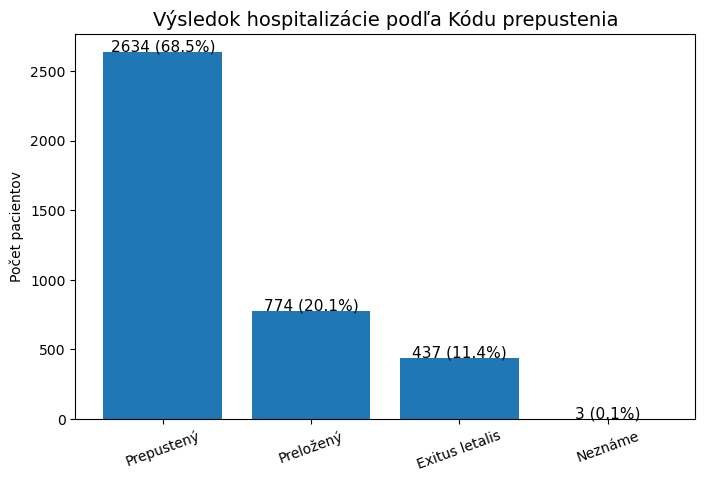

In [119]:
# Počty a percentá
counts = df_class["Skupiny_Kod_prepustenia"].value_counts()
percents = counts / len(df_class) * 100

plt.figure(figsize=(8, 5))

bars = plt.bar(counts.index, counts.values)

plt.title("Výsledok hospitalizácie podľa Kódu prepustenia", fontsize=14)
plt.ylabel("Počet pacientov")
plt.xticks(rotation=20)

# Text nad stĺpcami: počet + percento
for i, bar in enumerate(bars):
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 5,
        f"{counts.values[i]} ({percents.values[i]:.1f}%)",
        ha="center",
        fontsize=11
    )

plt.show()

## 5. Priradenie extrahovaných komorbidít


V tejto časti sa pomocou vopred definovaných kľúčových slov identifikujú vybrané komorbidity a diagnózy v textových záznamoch pacienta.  
Pre každú skupinu ochorení sa vytvorí samostatný binárny stĺpec, ktorý označuje prítomnosť alebo neprítomnosť danej komorbidity.

Na kontrolu výsledkov sa následne vytvorí súhrnná tabuľka s počtom a percentom pacientov pre každú komorbiditu a grafické zobrazenie ich výskytu v datasete.

In [120]:
df_features = df_class.copy()
# Slovník komorbidít a ich kľúčových slov
comorbidity_keywords = {
    "Hypertenzia": [
        "Hypertenzia",
        "vysoký krvný tlak"
    ],

    "Diabetes mellitus": [
        "Diabetes",
        "cukrovka"
    ],

    "Kardiovaskulárne ochorenia": [
        "Kardiovaskulárne",
        "srdcové zlyhanie",
        "ischemická choroba srdca",
        "angina pectoris",
        "infarkt",
        "aritmia",
        "flutter",
        "fibrilácia predsiení",
        "dilatácia aorty",
        "hypertenzia",
        "mitrálna regurgitácia",
    ],

    "Chronické respiračné ochorenia": [
        "chronická obštrukčná",
        "choroba pľúc",
        "astma",
        "emfyzém",
        "bronchitída",
        "pľúcna fibóza",
    ],

    "Pečeňové ochorenia": [
        "chronické zlyhanie obličiek",
        "renálna insuficiencia",
        "glomerulonefritída",
        "pyelonefritída",
        "nefrolitiáza",
        "nefropatia",
        "Nefritický",
        "insuficiencia",
    ],

    "Onkologické ochorenia": [
        "onkológ",
        "nádor",
        "tumor",
        "rakovin"
    ],

    "Imunosupresia": [
        "imunosupres",
        "kortikoster",
        "cyklofosfamid",
        "HIV",
        "antiretrovirálne",
    ],
}


# Aplikácia detekcie kľúčových slov pre každú komorbiditu
for column_name, keywords in comorbidity_keywords.items():
    df_features[column_name] = df_features.apply(
        detect_keywords,
        axis=1,
        keywords=keywords
    )

In [121]:
# Súhrn počtu a percenta pacientov s jednotlivými komorbiditami
comorbidity_columns = list(comorbidity_keywords.keys())

summary_comorbidities = pd.DataFrame({
    "Komorbidita": comorbidity_columns,
    "Počet pacientov": [df_features[col].sum() for col in comorbidity_columns],
    "Percento pacientov": [
        df_features[col].mean() * 100 for col in comorbidity_columns
    ]
})

summary_comorbidities = summary_comorbidities.sort_values(
    "Počet pacientov",
    ascending=False
)

summary_comorbidities.style.format({
    "Percento pacientov": "{:.2f} %"
})

,Komorbidita,Počet pacientov,Percento pacientov
2,Kardiovaskulárne ochorenia,2389,62.08 %
0,Hypertenzia,2313,60.11 %
4,Pečeňové ochorenia,1525,39.63 %
1,Diabetes mellitus,863,22.43 %
3,Chronické respiračné ochorenia,406,10.55 %
5,Onkologické ochorenia,291,7.56 %
6,Imunosupresia,166,4.31 %


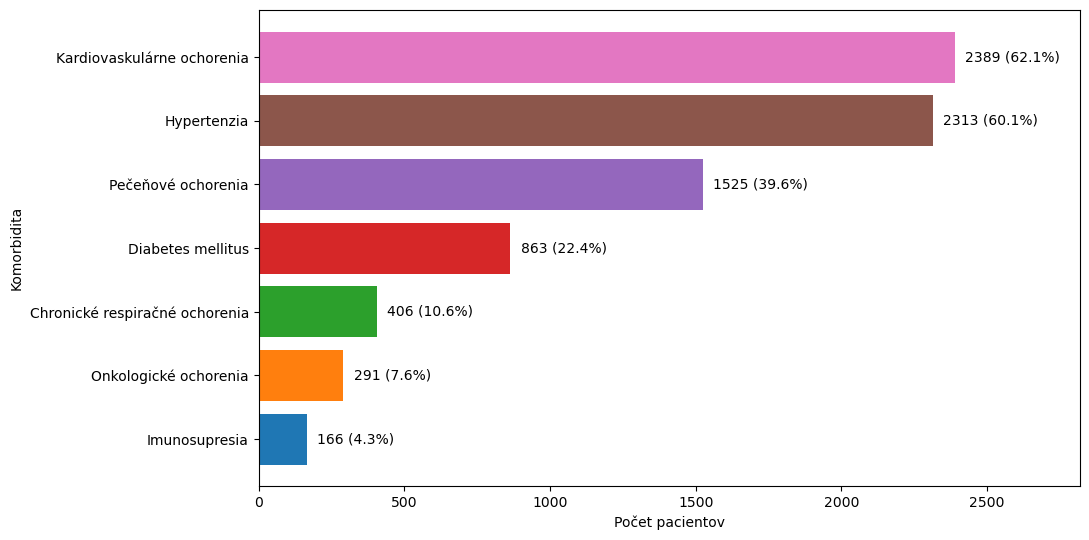

In [122]:
summary_comorbidities_sorted = summary_comorbidities.sort_values(
    "Počet pacientov",
    ascending=True
)

plt.figure(figsize=(11, 5.5))

colors = plt.cm.tab10(range(len(summary_comorbidities_sorted)))

bars = plt.barh(
    summary_comorbidities_sorted["Komorbidita"],
    summary_comorbidities_sorted["Počet pacientov"],
    color=colors
)

plt.xlabel("Počet pacientov")
plt.ylabel("Komorbidita")

# predĺženie osi X, aby sa zmestili popisy
max_value = summary_comorbidities_sorted["Počet pacientov"].max()
plt.xlim(0, max_value * 1.18)

for bar, count, percent in zip(
    bars,
    summary_comorbidities_sorted["Počet pacientov"],
    summary_comorbidities_sorted["Percento pacientov"]
):
    plt.text(
        bar.get_width() + max_value * 0.015,
        bar.get_y() + bar.get_height() / 2,
        f"{count} ({percent:.1f}%)",
        va="center",
        fontsize=10
    )

plt.tight_layout()
plt.show()

In [123]:
def get_vaccination_count(
    row,
    columns_to_check=["Epikríza", "Epidemiologická anamnéza"]
):
    vaccination_count_patterns = [
        r"očkovanie \b(\d+)x",
        r"očkovan[ý|ie|á] (\d+)[x|\.]$",
        r"očkovan[ý|ie|á] (\d+)[x|\.]\s+",
        r"\b(\d+)\s?dávok",
        r"\b(\d+)\s?dávkov",
        r"\b(\d+)\s?dávky",
        r"\b(\d+)\s?dávka",
        r"\b(\d+)\s?x$",
        r"\b(\d+)\s?x\s+",
        r"\b(\d+)x očkov",
        r"\b(\d+)\.\s?dáv",
        r"očkov.+(\d+)krát",
        r"(\d+). dávk",
    ]

    if row["Vakcinácia"] == False:
        return 0

    for column in columns_to_check:
        for pattern_text in vaccination_count_patterns:
            pattern = re.compile(pattern_text, re.IGNORECASE)

            for row_value in str(row[column]).lower().split(","):
                match = re.search(pattern, row_value)

                if match:
                    result = int(match.group(1))

                    if result > 4:
                        return 1

                    return result

    return 1

def get_vaccination_type(
    row,
    columns_to_check=["Epikríza", "Epidemiologická anamnéza"]
):
    m_rna_keywords = [
        "mrna",
        "pfizer",
        "moderna",
        "biontech",
        "biontec",
        "comirnaty"
    ]

    viral_vector_keywords = [
        "astrazeneca",
        "johnson",
        "janssen",
        "astra",
        "zeneca"
    ]

    for column in columns_to_check:
        text = str(row[column]).lower()

        for keyword in m_rna_keywords:
            if keyword in text:
                return "mRNA"

        for keyword in viral_vector_keywords:
            if keyword in text:
                return "vector"

    return None

# Detekcia informácie o vakcinácii
df_features["Vakcinácia"] = df_features.apply(
    detect_vaccination,
    axis=1,
    positive_keywords=[
        "vakcín",
        "vakcin",
        "očkovan"
    ],
    negative_keywords=[
        r"\bne.+\s?očkov",
        "neočkov",
        r"očkov.+\s?\bne",
        r"očkov.+\s?\bnie",
        "nie je očkov",
        "nepodstúpil očkov",
        "nepodstúpila očkov",
        r"vakcín.+\s?\bne",
        r"vakcín.+\s?\bnie",
    ],
)

# Detekcia typu vakcíny
df_features["Typ vakcíny"] = df_features.apply(
    get_vaccination_type,
    axis=1
)

# Ak je identifikovaný typ vakcíny, pacient je považovaný za vakcinovaného
df_features.loc[
    df_features["Typ vakcíny"].notnull(),
    "Vakcinácia"
] = True

# Detekcia počtu dávok
df_features["Počet dávok"] = df_features.apply(
    get_vaccination_count,
    axis=1
)


In [124]:

comorbidity_columns = [
    "Hypertenzia",
    "Diabetes mellitus",
    "Kardiovaskulárne ochorenia",
    "Chronické respiračné ochorenia",
    "Pečeňové ochorenia",
    "Onkologické ochorenia",
    "Imunosupresia"
]

# zabezpečenie bool hodnôt
df_features[comorbidity_columns] = df_features[comorbidity_columns].fillna(False).astype(bool)

# počet pacientov v jednotlivých vlnách
patients_per_wave = df_features.groupby("vlna").size().rename("Počet pacientov vo vlne")

# dlhý formát dát
comorbidity_by_wave = (
    df_features
    .melt(
        id_vars="vlna",
        value_vars=comorbidity_columns,
        var_name="Komorbidita",
        value_name="Prítomnosť"
    )
)

# súhrnná tabuľka
summary_comorbidities_wave = (
    comorbidity_by_wave
    .groupby(["vlna", "Komorbidita"])["Prítomnosť"]
    .sum()
    .reset_index(name="Počet pacientov")
)

summary_comorbidities_wave = summary_comorbidities_wave.merge(
    patients_per_wave,
    on="vlna"
)

summary_comorbidities_wave["Percento pacientov"] = (
    summary_comorbidities_wave["Počet pacientov"] /
    summary_comorbidities_wave["Počet pacientov vo vlne"] * 100
).round(1)

summary_comorbidities_wave

,vlna,Komorbidita,Počet pacientov,Počet pacientov vo vlne,Percento pacientov
0,1,Chronické respiračné ochorenia,85,1124,7.6
1,1,Diabetes mellitus,229,1124,20.4
2,1,Hypertenzia,630,1124,56.0
3,1,Imunosupresia,23,1124,2.0
4,1,Kardiovaskulárne ochorenia,652,1124,58.0
5,1,Onkologické ochorenia,58,1124,5.2
6,1,Pečeňové ochorenia,384,1124,34.2
7,2,Chronické respiračné ochorenia,80,824,9.7
8,2,Diabetes mellitus,141,824,17.1
9,2,Hypertenzia,443,824,53.8


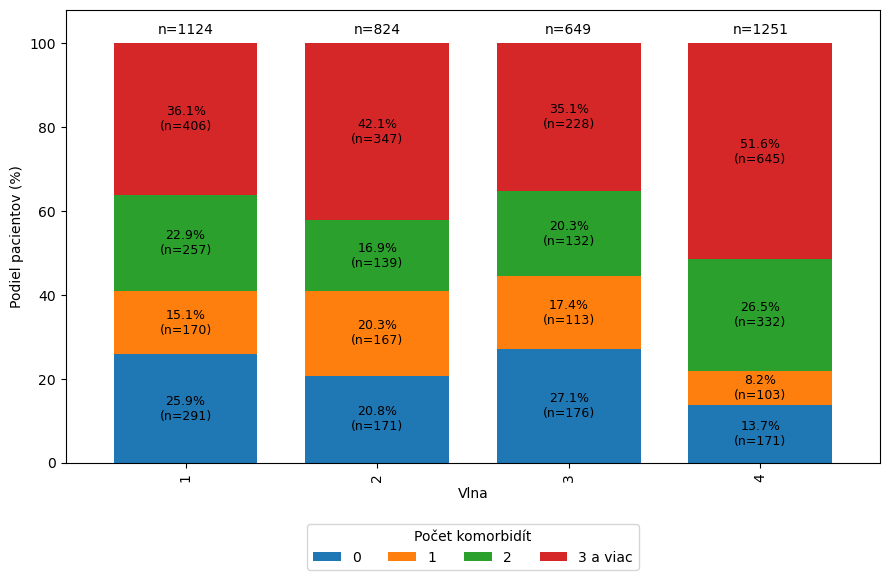

In [125]:
# počet komorbidít na pacienta
df_features["Počet komorbidít"] = df_features[comorbidity_columns].sum(axis=1)

def categorize_comorbidity_count(x):
    if x == 0:
        return "0"
    elif x == 1:
        return "1"
    elif x == 2:
        return "2"
    else:
        return "3 a viac"

df_features["Kategória počtu komorbidít"] = df_features["Počet komorbidít"].apply(
    categorize_comorbidity_count
)

# absolútne počty
comorbidity_count_wave_abs = pd.crosstab(
    df_features["vlna"],
    df_features["Kategória počtu komorbidít"]
)

# percentá
comorbidity_count_wave_pct = pd.crosstab(
    df_features["vlna"],
    df_features["Kategória počtu komorbidít"],
    normalize="index"
) * 100

# poradie stĺpcov
ordered_cols = ["0", "1", "2", "3 a viac"]

comorbidity_count_wave_abs = comorbidity_count_wave_abs.reindex(columns=ordered_cols, fill_value=0)
comorbidity_count_wave_pct = comorbidity_count_wave_pct.reindex(columns=ordered_cols, fill_value=0)

# graf
ax = comorbidity_count_wave_pct.plot(
    kind="bar",
    stacked=True,
    figsize=(9, 6),
    width=0.75
)

plt.ylabel("Podiel pacientov (%)")
plt.xlabel("Vlna")

# legenda pod grafom
ax.legend(
    title="Počet komorbidít",
    loc="upper center",
    bbox_to_anchor=(0.5, -0.12),
    ncol=4,
    frameon=True
)

# pridanie popisov do segmentov
for i, wave in enumerate(comorbidity_count_wave_pct.index):
    cumulative = 0
    for col in ordered_cols:
        pct = comorbidity_count_wave_pct.loc[wave, col]
        count = comorbidity_count_wave_abs.loc[wave, col]

        if pct > 4:
            ax.text(
                i,
                cumulative + pct / 2,
                f"{pct:.1f}%\n(n={count})",
                ha="center",
                va="center",
                fontsize=9
            )

        cumulative += pct

# celkový počet pacientov nad stĺpcom
total_per_wave = comorbidity_count_wave_abs.sum(axis=1)

for i, wave in enumerate(comorbidity_count_wave_pct.index):
    ax.text(
        i,
        101.5,
        f"n={total_per_wave.loc[wave]}",
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.ylim(0, 108)

# viac priestoru dole pre legendu
plt.tight_layout()
plt.subplots_adjust(bottom=0.22)

plt.show()

In [126]:

from itertools import combinations

# istota, že komorbidity sú bool hodnoty
df_features[comorbidity_columns] = (
    df_features[comorbidity_columns]
    .fillna(False)
    .astype(bool)
)

def get_comorbidity_combination(row):
    present = [col for col in comorbidity_columns if row[col]]

    if len(present) == 0:
        return "Bez komorbidity"
    
    return " + ".join(present)

df_features["Kombinácia komorbidít"] = df_features.apply(
    get_comorbidity_combination,
    axis=1
)

df_features["Počet komorbidít"] = df_features[comorbidity_columns].sum(axis=1)
# počet pacientov vo vlnách
patients_per_wave = df_features.groupby("vlna").size().rename("Počet pacientov vo vlne")

# kombinácie podľa vĺn
combination_by_wave = (
    df_features
    .groupby(["vlna", "Kombinácia komorbidít"])
    .size()
    .reset_index(name="Počet pacientov")
)

combination_by_wave = combination_by_wave.merge(
    patients_per_wave,
    on="vlna"
)

combination_by_wave["Percento pacientov vo vlne"] = (
    combination_by_wave["Počet pacientov"] /
    combination_by_wave["Počet pacientov vo vlne"] * 100
).round(1)

combination_by_wave = combination_by_wave.sort_values(
    ["vlna", "Počet pacientov"],
    ascending=[True, False]
)

combination_by_wave.head(20)

combination_by_wave_multiple = combination_by_wave[
    ~combination_by_wave["Kombinácia komorbidít"].isin(["Bez komorbidity"])
].copy()

combination_by_wave_multiple["Počet komorbidít v kombinácii"] = (
    combination_by_wave_multiple["Kombinácia komorbidít"]
    .apply(lambda x: len(x.split(" + ")))
)

combination_by_wave_multiple = combination_by_wave_multiple[
    combination_by_wave_multiple["Počet komorbidít v kombinácii"] >= 2
]

top_multiple_combinations_by_wave = (
    combination_by_wave_multiple
    .sort_values(["vlna", "Počet pacientov"], ascending=[True, False])
    .groupby("vlna")
    .head(10)
    .reset_index(drop=True)
)

top_multiple_combinations_by_wave

,vlna,Kombinácia komorbidít,Počet pacientov,Počet pacientov vo vlne,Percento pacientov vo vlne,Počet komorbidít v kombinácii
0,1,Hypertenzia + Kardiovaskulárne ochorenia,225,1124,20.0,2
1,1,Hypertenzia + Kardiovaskulárne ochorenia + Peč...,144,1124,12.8,3
2,1,Hypertenzia + Diabetes mellitus + Kardiovaskul...,85,1124,7.6,3
3,1,Hypertenzia + Diabetes mellitus + Kardiovaskul...,65,1124,5.8,4
4,1,Hypertenzia + Kardiovaskulárne ochorenia + Chr...,24,1124,2.1,3
5,1,Hypertenzia + Kardiovaskulárne ochorenia + Chr...,12,1124,1.1,4
6,1,Hypertenzia + Kardiovaskulárne ochorenia + Onk...,12,1124,1.1,3
7,1,Diabetes mellitus + Pečeňové ochorenia,11,1124,1.0,2
8,1,Hypertenzia + Diabetes mellitus + Kardiovaskul...,9,1124,0.8,4
9,1,Chronické respiračné ochorenia + Pečeňové ocho...,8,1124,0.7,2


In [127]:
#  Súhrn vakcinácie
vaccination_summary = pd.DataFrame({
    "Kategória": ["Nevakcinovaní", "Vakcinovaní"],
    "Počet pacientov": [
        (df_features["Vakcinácia"] == False).sum(),
        (df_features["Vakcinácia"] == True).sum()
    ]
})

vaccination_summary["Percento pacientov"] = (
    vaccination_summary["Počet pacientov"] / len(df_features) * 100
)

vaccination_summary.style.format({
    "Percento pacientov": "{:.2f} %"
})


,Kategória,Počet pacientov,Percento pacientov
0,Nevakcinovaní,2966,77.08 %
1,Vakcinovaní,882,22.92 %


In [128]:
df_features["Vakcinácia"] = df_features["Vakcinácia"].fillna(False).astype(bool)

vaccination_by_wave = pd.crosstab(
    df_features["vlna"],
    df_features["Vakcinácia"],
    margins=True
)

vaccination_by_wave_percent = pd.crosstab(
    df_features["vlna"],
    df_features["Vakcinácia"],
    normalize="index"
) * 100

vaccination_by_wave_percent = vaccination_by_wave_percent.round(1)

vaccination_by_wave

Vakcinácia,False,True,All
vlna,,,
1,1050,74,1124
2,746,78,824
3,513,136,649
4,657,594,1251
All,2966,882,3848


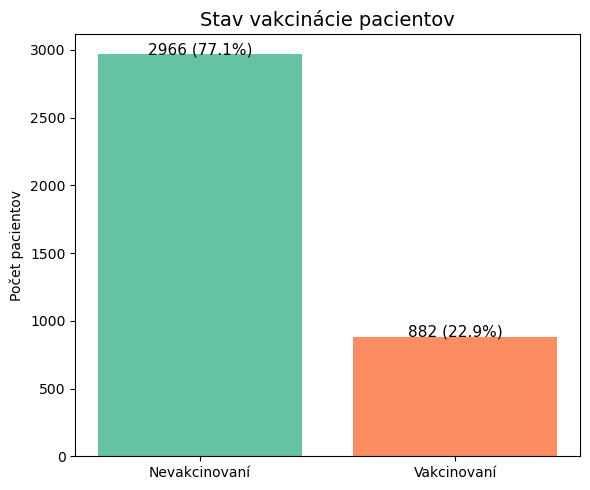

In [129]:
plt.figure(figsize=(6, 5))

bars = plt.bar(
    vaccination_summary["Kategória"],
    vaccination_summary["Počet pacientov"],
    color=plt.cm.Set2(range(len(vaccination_summary)))
)

plt.title("Stav vakcinácie pacientov", fontsize=14)
plt.ylabel("Počet pacientov")

for bar, count, percent in zip(
    bars,
    vaccination_summary["Počet pacientov"],
    vaccination_summary["Percento pacientov"]
):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 2,
        f"{count} ({percent:.1f}%)",
        ha="center",
        fontsize=11
    )

plt.tight_layout()
plt.show()

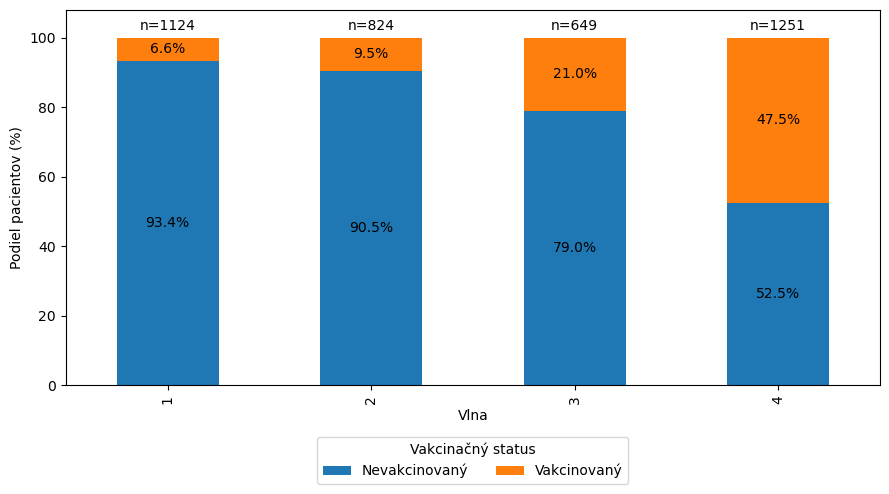

In [130]:
vaccination_plot = pd.crosstab(
    df_features["vlna"],
    df_features["Vakcinácia"],
    normalize="index"
) * 100

vaccination_plot = vaccination_plot.rename(
    columns={
        False: "Nevakcinovaný",
        True: "Vakcinovaný"
    }
)

vaccination_plot = vaccination_plot[["Nevakcinovaný", "Vakcinovaný"]]

# absolútne počty pacientov vo vlnách
total_per_wave = df_features.groupby("vlna").size()

ax = vaccination_plot.plot(
    kind="bar",
    stacked=True,
    figsize=(9, 5)
)

plt.ylabel("Podiel pacientov (%)")
plt.xlabel("Vlna")

# legenda pod grafom
ax.legend(
    title="Vakcinačný status",
    loc="upper center",
    bbox_to_anchor=(0.5, -0.12),
    ncol=2,
    frameon=True
)

# percentá v segmentoch
for i, wave in enumerate(vaccination_plot.index):
    cumulative = 0
    for col in vaccination_plot.columns:
        value = vaccination_plot.loc[wave, col]

        if value > 3:
            ax.text(
                i,
                cumulative + value / 2,
                f"{value:.1f}%",
                ha="center",
                va="center",
                fontsize=10,
                color="black"
            )

        cumulative += value

    # celkový počet pacientov nad stĺpcom
    ax.text(
        i,
        101.5,
        f"n={total_per_wave.loc[wave]}",
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.ylim(0, 108)

plt.tight_layout()
plt.subplots_adjust(bottom=0.22)

plt.show()

Typ vakcíny  mRNA  vector
vlna                     
1            83.3    16.7
2            75.7    24.3
3            80.6    19.4
4            91.3     8.7


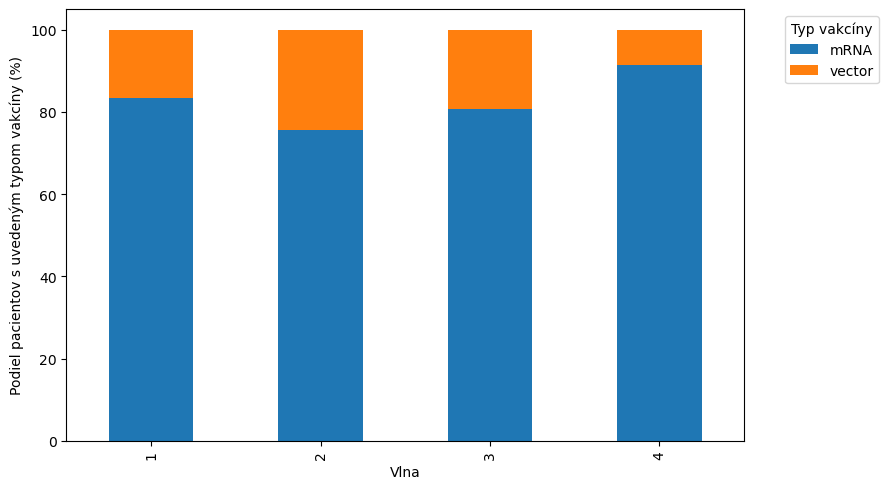

In [131]:
vaccinated_with_type = df_features[
    df_features["Typ vakcíny"].notna()
].copy()

vaccine_type_by_wave = pd.crosstab(
    vaccinated_with_type["vlna"],
    vaccinated_with_type["Typ vakcíny"],
    normalize="index"
) * 100

vaccine_type_by_wave = vaccine_type_by_wave.round(1)

print(vaccine_type_by_wave)

ax = vaccine_type_by_wave.plot(
    kind="bar",
    stacked=True,
    figsize=(9, 5)
)

plt.ylabel("Podiel pacientov s uvedeným typom vakcíny (%)")
plt.xlabel("Vlna")
# plt.title("Typ vakcíny podľa jednotlivých vĺn")
plt.legend(title="Typ vakcíny", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

## 6. Reorganizácia získaných (prázdnych a nejasných) prepustení zo stĺpca "Epikríza" podľa stĺpca "Kód prepustenia" 

In [132]:
print("df_epik:")
print(df_epik["Stav prepustenia"].value_counts(dropna=False))

print("\ndf_aro:")
print(df_aro["Stav prepustenia"].value_counts(dropna=False))

print("\ndf_features:")
print(df_features["Stav prepustenia"].value_counts(dropna=False))

df_epik:
Stav prepustenia
prepustenie amb. star.     2427
neznamy alebo prelozeny     831
exitus letalis              343
Nejasna epikriza            144
???                         103
Name: count, dtype: int64

df_aro:
Stav prepustenia
prepustenie amb. star.     2424
neznamy alebo prelozeny     758
exitus letalis              342
Nejasna epikriza            144
???                         103
ARO/OAIM                     77
Name: count, dtype: int64

df_features:
Stav prepustenia
prepustenie amb. star.     2424
neznamy alebo prelozeny     758
exitus letalis              342
Nejasna epikriza            144
???                         103
ARO/OAIM                     77
Name: count, dtype: int64


In [133]:
#  Kontrola a korekcia ARO/OAIM po pridaní features
print(df_features.info())

print(df_features["Stav prepustenia"].value_counts(dropna=False))
print(df_features["Kód prepustenia"].value_counts(dropna=False))

# Kontrola ARO/OAIM pacientov s kódom prepustenia = 3
aro_code_3 = df_features[
    (df_features["Stav prepustenia"] == "ARO/OAIM") &
    (df_features["Kód prepustenia"] == 3)
]
aro_code_4 = df_features[
    (df_features["Stav prepustenia"] == "ARO/OAIM") &
    (df_features["Kód prepustenia"] == 4)
]

print(
    "Počet riadkov so 'Stav prepustenia' = ARO/OAIM "
    f"a 'Kód prepustenia' = 3: {len(aro_code_3)}"
)

print(
    aro_code_3[
        ["Poradie", "Kód prepustenia", "Stav prepustenia"]
    ]
)
print(
    "Počet riadkov so 'Stav prepustenia' = ARO/OAIM "
    f"a 'Kód prepustenia' = 4: {len(aro_code_4)}"
)

print(
    aro_code_4[
        ["Poradie", "Kód prepustenia", "Stav prepustenia"]
    ]
)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3848 entries, 0 to 3847
Columns: 608 entries, Poradie to Kombinácia komorbidít
dtypes: bool(8), category(190), datetime64[ns](96), float64(235), int64(12), object(67)
memory usage: 12.8+ MB
None
Stav prepustenia
prepustenie amb. star.     2424
neznamy alebo prelozeny     758
exitus letalis              342
Nejasna epikriza            144
???                         103
ARO/OAIM                     77
Name: count, dtype: int64
Kód prepustenia
1     2540
3      551
6      290
4      223
7      147
5       53
2       41
10       2
12       1
Name: count, dtype: int64
Počet riadkov so 'Stav prepustenia' = ARO/OAIM a 'Kód prepustenia' = 3: 60
      Poradie  Kód prepustenia Stav prepustenia
9          10                3         ARO/OAIM
22         23                3         ARO/OAIM
45         46                3         ARO/OAIM
52         53                3         ARO/OAIM
79         80                3         ARO/OAIM
110       111   

In [134]:
print(df_features.info())

print(df_features["Stav prepustenia"].value_counts())
print(df_features["Kód prepustenia"].value_counts())

aro_code_3 = df_features[
    (df_features["Stav prepustenia"] == "ARO/OAIM") &
    (df_features["Kód prepustenia"] == 3)
]

print(
    "Počet riadkov so 'Stav prepustenia' = ARO/OAIM "
    f"a 'Kód prepustenia' = 3: {len(aro_code_3)}"
)

print(
    aro_code_3[
        ["Poradie", "Kód prepustenia", "Stav prepustenia"]
    ]
)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3848 entries, 0 to 3847
Columns: 608 entries, Poradie to Kombinácia komorbidít
dtypes: bool(8), category(190), datetime64[ns](96), float64(235), int64(12), object(67)
memory usage: 12.8+ MB
None
Stav prepustenia
prepustenie amb. star.     2424
neznamy alebo prelozeny     758
exitus letalis              342
Nejasna epikriza            144
???                         103
ARO/OAIM                     77
Name: count, dtype: int64
Kód prepustenia
1     2540
3      551
6      290
4      223
7      147
5       53
2       41
10       2
12       1
Name: count, dtype: int64
Počet riadkov so 'Stav prepustenia' = ARO/OAIM a 'Kód prepustenia' = 3: 60
      Poradie  Kód prepustenia Stav prepustenia
9          10                3         ARO/OAIM
22         23                3         ARO/OAIM
45         46                3         ARO/OAIM
52         53                3         ARO/OAIM
79         80                3         ARO/OAIM
110       111   

In [135]:
df_features.head()

,Poradie,Meno,Pohlavie,Vek,vlna,Dátum príjmu,Kód príjmu,Dátum prepustenia,Kód prepustenia,Pocet dni hosp.,...,Chronické respiračné ochorenia,Pečeňové ochorenia,Onkologické ochorenia,Imunosupresia,Vakcinácia,Typ vakcíny,Počet dávok,Počet komorbidít,Kategória počtu komorbidít,Kombinácia komorbidít
0,1,WMHAMJXUHHAEZEHBMNRM,Žena,75,1,2020-11-23,1,2020-11-30,1,7,...,False,False,False,False,False,None,0,0,0,Bez komorbidity
1,2,WMHAMJHBMHPKDJOQLNAH,Žena,65,1,2020-12-24,1,2021-01-06,1,13,...,False,False,False,False,False,None,0,1,1,Diabetes mellitus
2,3,BJHAMJHJYYFMYGYGUAMT,Žena,64,1,2020-12-12,1,2020-12-26,6,14,...,False,False,False,False,False,None,0,0,0,Bez komorbidity
3,4,KXHAMJTAHMEVZFLVULVZ,Muž,67,1,2020-12-16,1,2020-12-21,1,5,...,False,False,False,False,False,None,0,0,0,Bez komorbidity
4,5,TBHAMJTMUMUUJKDBNYED,Muž,82,1,2020-12-18,1,2020-12-21,6,3,...,False,False,False,False,False,None,0,2,2,Hypertenzia + Kardiovaskulárne ochorenia


In [136]:
# Kontrola ARO/OAIM pacientov s iným kódom prepustenia ako 3
aro_non_code_3 = df_features[
    (df_features["Stav prepustenia"] == "ARO/OAIM") &
    (df_features["Kód prepustenia"] != 3)
]

print(
    "Počet riadkov so 'Stav prepustenia' = ARO/OAIM "
    f"a 'Kód prepustenia' iný ako 3: {len(aro_non_code_3)}"
)

print(
    aro_non_code_3[
        ["Poradie", "Kód prepustenia", "Stav prepustenia"]
    ]
)

df_aro_corr = df_features.copy()

# Korekcia vybraných ARO/OAIM prípadov s kódmi 1 alebo 5
# Výnimka: Poradie 376 ostáva ARO/OAIM
mask_aro_to_ambulatory = (
    (df_aro_corr["Stav prepustenia"] == "ARO/OAIM") &
    (df_aro_corr["Kód prepustenia"].isin([1, 5])) &
    (df_aro_corr["Poradie"] != 376)
)

df_aro_corr.loc[
    mask_aro_to_ambulatory,
    "Stav prepustenia"
] = "prepustenie amb. star."

# Kontrola ARO/OAIM pacientov po korekcii
aro_non_code_3_after_correction = df_aro_corr[
    (df_aro_corr["Stav prepustenia"] == "ARO/OAIM") &
    (df_aro_corr["Kód prepustenia"] != 3)
]

print(
    "\n\nPočet ARO/OAIM riadkov s kódom prepustenia iným ako 3 "
    f"po korekcii: {len(aro_non_code_3_after_correction)}"
)

print(
    aro_non_code_3_after_correction[
        ["Poradie", "Kód prepustenia", "Stav prepustenia"]
    ]
)

print("\nRozdelenie stavov prepustenia po korekcii:")
print(df_aro_corr["Stav prepustenia"].value_counts(dropna=False))

Počet riadkov so 'Stav prepustenia' = ARO/OAIM a 'Kód prepustenia' iný ako 3: 17
      Poradie  Kód prepustenia Stav prepustenia
36         37                1         ARO/OAIM
87         88                4         ARO/OAIM
232       233                4         ARO/OAIM
266       267                4         ARO/OAIM
304       305                4         ARO/OAIM
310       311                4         ARO/OAIM
358       359                4         ARO/OAIM
375       376                1         ARO/OAIM
393       394                4         ARO/OAIM
525       526                4         ARO/OAIM
591       592                4         ARO/OAIM
711       712                4         ARO/OAIM
1038     1039                1         ARO/OAIM
1751     1752                1         ARO/OAIM
2250     2251                1         ARO/OAIM
3373     3374                4         ARO/OAIM
3527     3528                5         ARO/OAIM


Počet ARO/OAIM riadkov s kódom prepustenia iným ako 3

In [137]:
df_aro_corr.head()

,Poradie,Meno,Pohlavie,Vek,vlna,Dátum príjmu,Kód príjmu,Dátum prepustenia,Kód prepustenia,Pocet dni hosp.,...,Chronické respiračné ochorenia,Pečeňové ochorenia,Onkologické ochorenia,Imunosupresia,Vakcinácia,Typ vakcíny,Počet dávok,Počet komorbidít,Kategória počtu komorbidít,Kombinácia komorbidít
0,1,WMHAMJXUHHAEZEHBMNRM,Žena,75,1,2020-11-23,1,2020-11-30,1,7,...,False,False,False,False,False,None,0,0,0,Bez komorbidity
1,2,WMHAMJHBMHPKDJOQLNAH,Žena,65,1,2020-12-24,1,2021-01-06,1,13,...,False,False,False,False,False,None,0,1,1,Diabetes mellitus
2,3,BJHAMJHJYYFMYGYGUAMT,Žena,64,1,2020-12-12,1,2020-12-26,6,14,...,False,False,False,False,False,None,0,0,0,Bez komorbidity
3,4,KXHAMJTAHMEVZFLVULVZ,Muž,67,1,2020-12-16,1,2020-12-21,1,5,...,False,False,False,False,False,None,0,0,0,Bez komorbidity
4,5,TBHAMJTMUMUUJKDBNYED,Muž,82,1,2020-12-18,1,2020-12-21,6,3,...,False,False,False,False,False,None,0,2,2,Hypertenzia + Kardiovaskulárne ochorenia


### 6.1 Upráva tried v "Stav prepustenia"



In [138]:
df_f = df_aro_corr.copy()

mask_epikriza = df_f['Stav prepustenia'].isin(['Nejasna epikriza','???'])
print(df_f.columns)
print(mask_epikriza.sum())

# Priradenie podľa kódu prepustenia
df_f.loc[mask_epikriza & df_f['Kód prepustenia'].isin([1, 2, 5]), 'Stav prepustenia'] = 'prepustenie amb. star.'
df_f.loc[mask_epikriza & df_f['Kód prepustenia'].isin([6, 7]), 'Stav prepustenia'] = 'exitus letalis'
df_f.loc[mask_epikriza & df_f['Kód prepustenia'].isin([3, 4]), 'Stav prepustenia'] = 'preložený'

# prepíš všetky 'neznamy' a 'prelozeny' na 'preložený'
df_f['Stav prepustenia'] = df_f['Stav prepustenia'].replace(
    ['neznamy alebo prelozeny'],
    'preložený'
)
print(df_f['Kód prepustenia'].value_counts())
df_f['Stav prepustenia'].value_counts()

Index(['Poradie', 'Meno', 'Pohlavie', 'Vek', 'vlna', 'Dátum príjmu',
       'Kód príjmu', 'Dátum prepustenia', 'Kód prepustenia', 'Pocet dni hosp.',
       ...
       'Chronické respiračné ochorenia', 'Pečeňové ochorenia',
       'Onkologické ochorenia', 'Imunosupresia', 'Vakcinácia', 'Typ vakcíny',
       'Počet dávok', 'Počet komorbidít', 'Kategória počtu komorbidít',
       'Kombinácia komorbidít'],
      dtype='object', length=608)
247
Kód prepustenia
1     2540
3      551
6      290
4      223
7      147
5       53
2       41
10       2
12       1
Name: count, dtype: int64


Stav prepustenia
prepustenie amb. star.    2525
preložený                  881
exitus letalis             370
ARO/OAIM                    72
Name: count, dtype: int64

In [139]:
df_f.head()

,Poradie,Meno,Pohlavie,Vek,vlna,Dátum príjmu,Kód príjmu,Dátum prepustenia,Kód prepustenia,Pocet dni hosp.,...,Chronické respiračné ochorenia,Pečeňové ochorenia,Onkologické ochorenia,Imunosupresia,Vakcinácia,Typ vakcíny,Počet dávok,Počet komorbidít,Kategória počtu komorbidít,Kombinácia komorbidít
0,1,WMHAMJXUHHAEZEHBMNRM,Žena,75,1,2020-11-23,1,2020-11-30,1,7,...,False,False,False,False,False,None,0,0,0,Bez komorbidity
1,2,WMHAMJHBMHPKDJOQLNAH,Žena,65,1,2020-12-24,1,2021-01-06,1,13,...,False,False,False,False,False,None,0,1,1,Diabetes mellitus
2,3,BJHAMJHJYYFMYGYGUAMT,Žena,64,1,2020-12-12,1,2020-12-26,6,14,...,False,False,False,False,False,None,0,0,0,Bez komorbidity
3,4,KXHAMJTAHMEVZFLVULVZ,Muž,67,1,2020-12-16,1,2020-12-21,1,5,...,False,False,False,False,False,None,0,0,0,Bez komorbidity
4,5,TBHAMJTMUMUUJKDBNYED,Muž,82,1,2020-12-18,1,2020-12-21,6,3,...,False,False,False,False,False,None,0,2,2,Hypertenzia + Kardiovaskulárne ochorenia


### 6.2 Rozdelenie chybných zápisov v "Kóde prepustenia" podľa Epikríz

Niektoré záznamy majú priradený kód prepustenia 10 alebo 12,
ktoré nezodpovedajú štandardným kategóriám. Na základe textu Epikrízy
sa tieto záznamy manuálne pretriedujú do správnych kategórií —
prepustený, preložený alebo exitus.

In [140]:

mask_10 = df_f['Kód prepustenia'] == 10
df_f.loc[mask_10, 'Stav prepustenia'] = 'preložený'
df_f.loc[mask_10, 'Kód prepustenia'] = 3


mask_12 = df_f['Kód prepustenia'] == 12
df_f.loc[mask_12, 'Kód prepustenia'] = 1


print(df_f['Kód prepustenia'].value_counts())
df_f['Stav prepustenia'].value_counts()

Kód prepustenia
1    2541
3     553
6     290
4     223
7     147
5      53
2      41
Name: count, dtype: int64


Stav prepustenia
prepustenie amb. star.    2525
preložený                  881
exitus letalis             370
ARO/OAIM                    72
Name: count, dtype: int64

In [141]:
# Výber riadkov podľa podmienky
vysledok = df_f[
    (df_f['Kód prepustenia'].isin([1, 2,5])) &
    (df_f['Stav prepustenia'] == 'preložený')
]

# Výpis výsledkov
print(f"Počet riadkov s kódom 6 alebo 7 a stavom != 'exitus letalis': {len(vysledok)}")
print(vysledok[['Poradie', 'Kód prepustenia', 'Stav prepustenia']])
print(vysledok['Poradie'].tolist())


Počet riadkov s kódom 6 alebo 7 a stavom != 'exitus letalis': 192
      Poradie  Kód prepustenia Stav prepustenia
1           2                1        preložený
61         62                1        preložený
119       120                1        preložený
138       139                1        preložený
150       151                1        preložený
...       ...              ...              ...
3791     3792                1        preložený
3792     3793                1        preložený
3821     3822                1        preložený
3831     3832                1        preložený
3833     3834                1        preložený

[192 rows x 3 columns]
[2, 62, 120, 139, 151, 164, 165, 166, 200, 214, 297, 324, 349, 353, 432, 487, 515, 529, 541, 557, 574, 652, 664, 682, 697, 751, 796, 832, 833, 905, 931, 947, 955, 1025, 1027, 1029, 1030, 1044, 1048, 1097, 1109, 1137, 1156, 1161, 1200, 1206, 1216, 1218, 1234, 1247, 1274, 1294, 1317, 1342, 1348, 1349, 1354, 1374, 1382, 1393, 1398, 141

In [142]:
mask_epikriza = df_f['Stav prepustenia'].isin(['preložený','prepustenia amb. star.'])
print(df_f.columns)
print(mask_epikriza.sum())

# Priradenie podľa kódu prepustenia
df_f.loc[mask_epikriza & df_f['Kód prepustenia'].isin([6, 7]), 'Stav prepustenia'] = 'exitus letalis'
print(df_f['Kód prepustenia'].value_counts())
df_f['Stav prepustenia'].value_counts()

Index(['Poradie', 'Meno', 'Pohlavie', 'Vek', 'vlna', 'Dátum príjmu',
       'Kód príjmu', 'Dátum prepustenia', 'Kód prepustenia', 'Pocet dni hosp.',
       ...
       'Chronické respiračné ochorenia', 'Pečeňové ochorenia',
       'Onkologické ochorenia', 'Imunosupresia', 'Vakcinácia', 'Typ vakcíny',
       'Počet dávok', 'Počet komorbidít', 'Kategória počtu komorbidít',
       'Kombinácia komorbidít'],
      dtype='object', length=608)
881
Kód prepustenia
1    2541
3     553
6     290
4     223
7     147
5      53
2      41
Name: count, dtype: int64


Stav prepustenia
prepustenie amb. star.    2525
preložený                  819
exitus letalis             432
ARO/OAIM                    72
Name: count, dtype: int64

#### 6.2.1 Výber pacientov DSS a prepustených do domácej liečby

In [143]:

mask_prelozeny = df_f['Stav prepustenia'].str.lower().str.strip() == 'preložený'

pattern = re.compile(
    r'(domáca\s*(starostlivosť|liečba)|do\s*domácej\s*(starostlivosti|liečby)|\bDSS\b|domov\s*sociálnych\s*služieb)',
    re.IGNORECASE
)

mask_epikriza = df_f['Epikríza'].apply(lambda x: bool(pattern.search(str(x))))


final_mask = mask_prelozeny & mask_epikriza


df_f.loc[final_mask, 'Stav prepustenia'] = 'prepustenie amb. star.'
# df_f.loc[final_mask, 'Stav prepustenia'] = 'prepustený do domácej liečby'

vysledok = df_f[final_mask]
print(f"Počet prepísaných riadkov: {len(vysledok)}")
print(vysledok[['Poradie', 'Kód prepustenia', 'Stav prepustenia']])



Počet prepísaných riadkov: 33
      Poradie  Kód prepustenia        Stav prepustenia
61         62                1  prepustenie amb. star.
119       120                1  prepustenie amb. star.
136       137                4  prepustenie amb. star.
138       139                1  prepustenie amb. star.
150       151                1  prepustenie amb. star.
164       165                1  prepustenie amb. star.
213       214                1  prepustenie amb. star.
216       217                3  prepustenie amb. star.
296       297                1  prepustenie amb. star.
352       353                1  prepustenie amb. star.
486       487                2  prepustenie amb. star.
528       529                1  prepustenie amb. star.
587       588                3  prepustenie amb. star.
663       664                1  prepustenie amb. star.
681       682                1  prepustenie amb. star.
904       905                1  prepustenie amb. star.
930       931                1  pre

Stav prepustenia
prepustenie amb. star.    2558
preložený                  786
exitus letalis             432
ARO/OAIM                    72
Name: count, dtype: int64
Kód prepustenia
1    2541
3     553
6     290
4     223
7     147
5      53
2      41
Name: count, dtype: int64


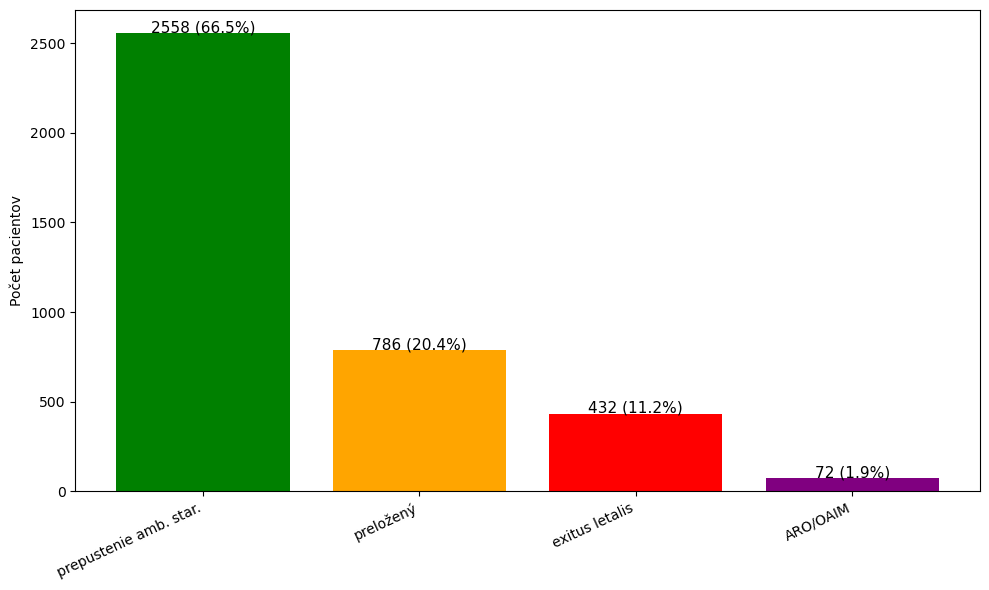

In [144]:
print(df_f["Stav prepustenia"].value_counts(dropna=False))
print(df_f["Kód prepustenia"].value_counts(dropna=False))

counts = df_f["Stav prepustenia"].value_counts()
percents = counts / len(df_f) * 100

colors = {
    "prepustenie amb. star.": "green",
    "preložený": "orange",
    "exitus letalis": "red",
    "ARO/OAIM": "purple",
    "Neznáme": "gray"
}

bar_colors = [
    colors.get(label, "gray")
    for label in counts.index
]

plt.figure(figsize=(10, 6))

bars = plt.bar(
    counts.index,
    counts.values,
    color=bar_colors
)

#plt.title("Rozdelenie pacientov podľa stavu prepustenia", fontsize=14)
plt.ylabel("Počet pacientov")
plt.xticks(rotation=25, ha="right")

for i, bar in enumerate(bars):
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 5,
        f"{counts.values[i]} ({percents.values[i]:.1f}%)",
        ha="center",
        fontsize=11
    )

plt.tight_layout()
plt.show()

## 7.1 Extrakcia nameraných saturácií

V tejto časti sa z textových stĺpcov `Objektívny nález`, `Terajšie ochorenie` a `Epikríza` extrahujú hodnoty saturácie kyslíka uvedené v percentách.

Pomocou regulárneho výrazu sa vyhľadávajú číselné hodnoty vo formáte napríklad `92 %`, `95%` alebo `100 %`.  
Následne sa podľa okolitého textového kontextu rozlišuje, či bola saturácia meraná:

- **bez oxygenoterapie**,
- **s oxygenoterapiou / pri podávaní O₂**.
- **neurčené / bez jasného O2 kontextu**.

 Do neurčených hodnôt sa zaraďujú iba percentá, ktoré majú
v okolí saturácii podobný kontext, napr. sat, SpO2, saturácia.

Hodnoty mimo realistického rozsahu sa odfiltrujú a výsledky sa ukladajú do dvoch nových stĺpcov:

- `sat_bez_o2` – zoznam saturácií zachytených bez podávania kyslíka,
- `sat_s_o2` – zoznam saturácií zachytených pri oxygenoterapii alebo pri uvedenom prietoku kyslíka v l/min.

In [145]:

sat_pattern = r"(\d{2,3})\s*%"

context_o2 = [
      r"s\s*kyslíkom", r"s\s*o2", r"s\s*02", r"s oxygenoterapiou",
    r"po\s*o2", r"po\s*02", r"so\s*suplementáciou", r"\d+\s*l/?min"
]
context_bez_o2 = [
    r"bez\s*kyslíka", r"bez\s*o2", r"bez\s*02", r"bez\s*oxygenoterapie",
    r"pred\s*o2", r"pred\s*02", r"eupnoická", r"eupnoicky", r"eupnoe"
]



def extract_saturation_split2(row, columns, sat_pattern, context_o2, context_bez_o2):
    sat_o2, sat_bez_o2 = [], []
    lmin_pattern = r"\d+\s*l/?min"
    for col in columns:
        text = str(row[col])
        matches = re.finditer(sat_pattern, text)
        for m in matches:
            value = float(m.group(1))
            if value <= 40 or value > 100:
                continue
            substring = text[max(0, m.start()-30):m.end()+30]
            # Najprv špeciálne skontrolovať l/min blízko hodnoty
            if re.search(lmin_pattern, substring, re.IGNORECASE):
                sat_o2.append(value)
            # Potom bežnými patternmi
            elif any(re.search(pattern, substring, re.IGNORECASE) for pattern in context_o2):
                sat_o2.append(value)
            elif any(re.search(pattern, substring, re.IGNORECASE) for pattern in context_bez_o2):
                sat_bez_o2.append(value)
    return pd.Series([sat_bez_o2, sat_o2])

columns_to_check = ["Objektívny nález", "Terajšie ochorenie", "Epikríza"]
df_f[['sat_bez_o2', 'sat_s_o2']] = df_f.apply(
    lambda row: extract_saturation_split2(row, columns_to_check, sat_pattern, context_o2, context_bez_o2), axis=1
)
print(df_f[["Poradie","Vek",'sat_bez_o2', 'sat_s_o2']].head(40))



    Poradie  Vek    sat_bez_o2            sat_s_o2
0         1   75        [96.0]                  []
1         2   65            []              [86.0]
2         3   64            []  [80.0, 94.0, 80.0]
3         4   67       [100.0]             [100.0]
4         5   82            []              [94.0]
5         6   74            []                  []
6         7   48        [92.0]                  []
7         8   36        [93.0]              [91.0]
8         9   79            []                  []
9        10   84            []              [94.0]
10       11   71            []              [90.0]
11       12   55            []                  []
12       13   45            []              [95.0]
13       14   81        [76.0]  [76.0, 91.0, 91.0]
14       15   62        [89.0]              [89.0]
15       16   65        [87.0]  [96.0, 87.0, 96.0]
16       17   76  [92.0, 92.0]                  []
17       18   70        [89.0]        [89.0, 95.0]
18       19   69            [] 

In [146]:
sat_pattern = r"(\d{2,3})\s*%"

context_o2 = [
    r"s\s*kyslíkom", r"s\s*o2", r"s\s*02", r"s oxygenoterapiou",
    r"po\s*o2", r"po\s*02", r"so\s*suplementáciou", r"\d+\s*l/?min"
]

context_bez_o2 = [
    r"bez\s*kyslíka", r"bez\s*o2", r"bez\s*02", r"bez\s*oxygenoterapie",
    r"pred\s*o2", r"pred\s*02", r"eupnoická", r"eupnoicky", r"eupnoe"
]


def _first_or_nan(lst):
    return float(lst[0]) if isinstance(lst, list) and len(lst) > 0 else np.nan


def _min_or_nan(lst):
    return float(np.min(lst)) if isinstance(lst, list) and len(lst) > 0 else np.nan


def extract_saturation_with_first_min(
    row,
    columns,
    sat_pattern,
    context_o2,
    context_bez_o2,
    window: int = 30
):
    sat_o2, sat_bez_o2, sat_neurcene = [], [], []
    lmin_pattern = r"\d+\s*l/?min"

    for col in columns:
        text = row.get(col, "")

        if pd.isna(text):
            continue

        text = str(text)

        for m in re.finditer(sat_pattern, text):
            value = float(m.group(1))

            # filtrácia nezmyslov mimo fyziologický rozsah
            if value <= 40 or value > 100:
                continue

            substring = text[
                max(0, m.start() - window):m.end() + window
            ]

            # prioritne "l/min" = s O2
            if re.search(lmin_pattern, substring, re.IGNORECASE):
                sat_o2.append(value)

            # potom explicitné kontexty s O2
            elif any(
                re.search(p, substring, re.IGNORECASE)
                for p in context_o2
            ):
                sat_o2.append(value)

            # explicitné kontexty bez O2
            elif any(
                re.search(p, substring, re.IGNORECASE)
                for p in context_bez_o2
            ):
                sat_bez_o2.append(value)

            # saturácia nájdená, ale bez jasného kontextu
            else:
                sat_neurcene.append(value)

    return pd.Series([
        sat_bez_o2,
        sat_o2,
        sat_neurcene,

        _first_or_nan(sat_bez_o2),
        _min_or_nan(sat_bez_o2),

        _first_or_nan(sat_o2),
        _min_or_nan(sat_o2),

        _first_or_nan(sat_neurcene),
        _min_or_nan(sat_neurcene),
    ])

columns_to_check = ["Objektívny nález", "Terajšie ochorenie", "Epikríza"]

df_f[[
    "sat_bez_o2",
    "sat_s_o2",
    "sat_neurcene",

    "sat_bez_o2_prva",
    "sat_bez_o2_min",

    "sat_s_o2_prva",
    "sat_s_o2_min",

    "sat_neurcene_prva",
    "sat_neurcene_min",
]] = df_f.apply(
    lambda row: extract_saturation_with_first_min(
        row,
        columns_to_check,
        sat_pattern,
        context_o2,
        context_bez_o2
    ),
    axis=1
)

df_f[[
    "Poradie",
    "Vek",
    "sat_bez_o2",
    "sat_bez_o2_prva",
    "sat_bez_o2_min",
    "sat_s_o2",
    "sat_s_o2_prva",
    "sat_s_o2_min",
    "sat_neurcene",
    "sat_neurcene_prva",
    "sat_neurcene_min",
]].head(40)

,Poradie,Vek,sat_bez_o2,sat_bez_o2_prva,sat_bez_o2_min,sat_s_o2,sat_s_o2_prva,sat_s_o2_min,sat_neurcene,sat_neurcene_prva,sat_neurcene_min
0,1,75,[96.0],96.0,96.0,[],NaN,NaN,[],NaN,NaN
1,2,65,[],NaN,NaN,[86.0],86.0,86.0,[86.0],86.0,86.0
2,3,64,[],NaN,NaN,"[80.0, 94.0, 80.0]",80.0,80.0,"[80.0, 95.0]",80.0,80.0
3,4,67,[100.0],100.0,100.0,[100.0],100.0,100.0,[],NaN,NaN
4,5,82,[],NaN,NaN,[94.0],94.0,94.0,[94.0],94.0,94.0
5,6,74,[],NaN,NaN,[],NaN,NaN,[],NaN,NaN
6,7,48,[92.0],92.0,92.0,[],NaN,NaN,[],NaN,NaN
7,8,36,[93.0],93.0,93.0,[91.0],91.0,91.0,[],NaN,NaN
8,9,79,[],NaN,NaN,[],NaN,NaN,[],NaN,NaN
9,10,84,[],NaN,NaN,[94.0],94.0,94.0,[],NaN,NaN


In [147]:
print("Počet pacientov so saturáciou bez O2:")
print(df_f["sat_bez_o2"].apply(lambda x: len(x) > 0).sum())

print("\nPočet pacientov so saturáciou s O2:")
print(df_f["sat_s_o2"].apply(lambda x: len(x) > 0).sum())

print("\nPočet pacientov so saturáciou bez určeného kontextu:")
print(df_f["sat_neurcene"].apply(lambda x: len(x) > 0).sum())

Počet pacientov so saturáciou bez O2:
2750

Počet pacientov so saturáciou s O2:
2370

Počet pacientov so saturáciou bez určeného kontextu:
1381


In [148]:
lmin_pattern = r"\d+\s*l/?min"

sat_anchor_patterns = [
    r"\bsat\b",
    r"satur",
    r"spo2",
    r"sp\s*o2",
    r"sat\.?\s*o2",
]


def _first_or_nan(lst):
    return float(lst[0]) if isinstance(lst, list) and len(lst) > 0 else np.nan


def _min_or_nan(lst):
    return float(np.min(lst)) if isinstance(lst, list) and len(lst) > 0 else np.nan


def extract_sat_from_text(text: str, window: int = 30):

    sat_bez, sat_o2, sat_neurcene = [], [], []

    if pd.isna(text):
        return sat_bez, sat_o2, sat_neurcene

    text = str(text)

    for m in re.finditer(sat_pattern, text):
        value = float(m.group(1))

        # fyziologický filter
        if value <= 40 or value > 100:
            continue

        substring = text[
            max(0, m.start() - window):m.end() + window
        ]

        if re.search(lmin_pattern, substring, re.IGNORECASE):
            sat_o2.append(value)

        elif any(re.search(p, substring, re.IGNORECASE) for p in context_o2):
            sat_o2.append(value)

        elif any(re.search(p, substring, re.IGNORECASE) for p in context_bez_o2):
            sat_bez.append(value)

        elif any(re.search(p, substring, re.IGNORECASE) for p in sat_anchor_patterns):
            sat_neurcene.append(value)

    return sat_bez, sat_o2, sat_neurcene

def summarize_sats_per_column(
    df: pd.DataFrame,
    columns: list,
    id_col: str = "Poradie"
) -> pd.DataFrame:

    rows = []

    def stats_from_all(vals):
        if len(vals) == 0:
            return {
                "min": np.nan,
                "q1": np.nan,
                "med": np.nan,
                "q3": np.nan,
                "max": np.nan
            }

        arr = np.array(vals, dtype=float)

        return {
            "min": float(np.min(arr)),
            "q1": float(np.quantile(arr, 0.25)),
            "med": float(np.median(arr)),
            "q3": float(np.quantile(arr, 0.75)),
            "max": float(np.max(arr)),
        }

    for col in columns:
        extracted = df[col].apply(lambda text: extract_sat_from_text(text))

        bez_lists = extracted.apply(lambda x: x[0])
        s_lists = extracted.apply(lambda x: x[1])
        neurcene_lists = extracted.apply(lambda x: x[2])

        bez_n = bez_lists.apply(len)
        s_n = s_lists.apply(len)
        neurcene_n = neurcene_lists.apply(len)

        bez_all = [v for lst in bez_lists for v in lst]
        s_all = [v for lst in s_lists for v in lst]
        neurcene_all = [v for lst in neurcene_lists for v in lst]

        bez_stats = stats_from_all(bez_all)
        s_stats = stats_from_all(s_all)
        neurcene_stats = stats_from_all(neurcene_all)

        rows.append({
            "Stĺpec": col,
            "N (riadkov)": len(df),

            "Bez O2: pacientov s 1 hodnotou": int((bez_n > 0).sum()),
            "Bez O2: všetkých nálezov": int(bez_n.sum()),
            "Bez O2: min": bez_stats["min"],
            "Bez O2: max": bez_stats["max"],

            "S O2: pacientov s 1 hodnotou": int((s_n > 0).sum()),
            "S O2: všetkých nálezov": int(s_n.sum()),
            "S O2: min": s_stats["min"],
            "S O2: max": s_stats["max"],

            "Neurčené: pacientov s 1 hodnotou": int((neurcene_n > 0).sum()),
            "Neurčené: všetkých nálezov": int(neurcene_n.sum()),
            "Neurčené: min": neurcene_stats["min"],
            "Neurčené: max": neurcene_stats["max"],
        })

    return pd.DataFrame(rows)

columns_to_check = [
    "Objektívny nález",
    "Terajšie ochorenie",
    "Epikríza"
]

summary_sat_cols = summarize_sats_per_column(
    df_f,
    columns_to_check
)

summary_sat_cols

,Stĺpec,N (riadkov),Bez O2: pacientov s 1 hodnotou,Bez O2: všetkých nálezov,Bez O2: min,Bez O2: max,S O2: pacientov s 1 hodnotou,S O2: všetkých nálezov,S O2: min,S O2: max,Neurčené: pacientov s 1 hodnotou,Neurčené: všetkých nálezov,Neurčené: min,Neurčené: max
0,Objektívny nález,3848,903,1024,50.0,100.0,2276,2717,47.0,100.0,464,500,42.0,100.0
1,Terajšie ochorenie,3848,144,188,45.0,100.0,57,71,50.0,99.0,215,246,60.0,100.0
2,Epikríza,3848,2349,3166,44.0,100.0,307,393,50.0,100.0,621,689,50.0,100.0


In [149]:
print("Saturácie:")
print([col for col in [
    "sat_bez_o2",
    "sat_s_o2",
    "sat_neurcene",
    "sat_bez_o2_prva",
    "sat_bez_o2_min",
    "sat_s_o2_prva",
    "sat_s_o2_min",
    "sat_neurcene_prva",
    "sat_neurcene_min"
] if col in df_f.columns])

Saturácie:
['sat_bez_o2', 'sat_s_o2', 'sat_neurcene', 'sat_bez_o2_prva', 'sat_bez_o2_min', 'sat_s_o2_prva', 'sat_s_o2_min', 'sat_neurcene_prva', 'sat_neurcene_min']


C:\Users\DELL\AppData\Local\Temp\ipykernel_31484\1379927805.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


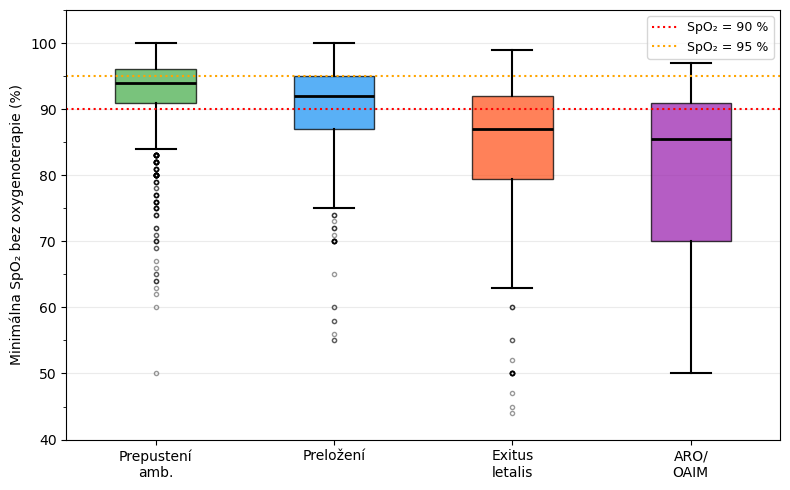

In [150]:
import matplotlib.ticker as mticker


order  = ["prepustenie amb. star.", "preložený", "exitus letalis", "ARO/OAIM"]
labels = ["Prepustení\namb.", "Preložení", "Exitus\nletalis", "ARO/\nOAIM"]
colors = ["#4CAF50", "#2196F3", "#FF5722", "#9C27B0"]

data_groups = [
    df_f.loc[df_f["Stav prepustenia"] == s, "sat_bez_o2_min"].dropna().values
    for s in order
]

fig, ax = plt.subplots(figsize=(8, 5))

bp = ax.boxplot(
    data_groups,
    labels=labels,
    patch_artist=True,
    medianprops=dict(color="black", linewidth=2),
    whiskerprops=dict(linewidth=1.5),
    capprops=dict(linewidth=1.5),
    flierprops=dict(marker="o", markersize=3, alpha=0.4)
)

for patch, color in zip(bp["boxes"], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.75)


ax.axhline(90, color="red",    linestyle=":", linewidth=1.5, label="SpO₂ = 90 %")
ax.axhline(95, color="orange", linestyle=":", linewidth=1.5, label="SpO₂ = 95 %")

ax.set_ylabel("Minimálna SpO₂ bez oxygenoterapie (%)")
ax.set_ylim(40, 105)
ax.yaxis.set_minor_locator(mticker.MultipleLocator(5))
ax.grid(axis="y", alpha=0.25)
ax.legend(fontsize=9)

plt.tight_layout()
##plt.savefig("spo2_boxplot.png", dpi=150, bbox_inches="tight")
plt.show()

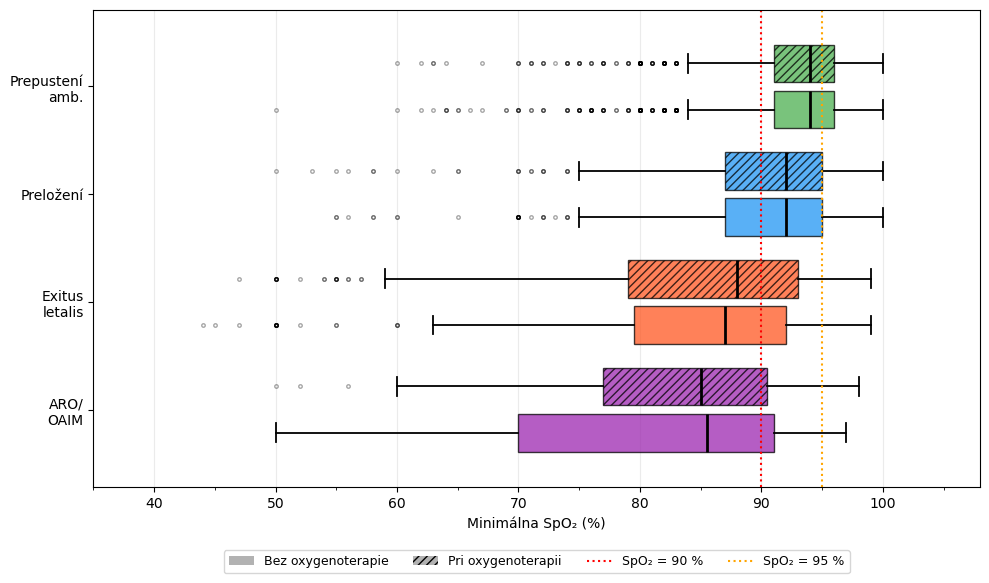

In [151]:

from matplotlib.patches import Patch

order  = ["ARO/OAIM", "exitus letalis", "preložený", "prepustenie amb. star."]
labels = ["ARO/\nOAIM", "Exitus\nletalis", "Preložení", "Prepustení\namb."]
colors = ["#9C27B0", "#FF5722", "#2196F3", "#4CAF50"]

fig, ax = plt.subplots(figsize=(10, 6))

width = 0.35
gap   = 0.08

for i, (s, color) in enumerate(zip(order, colors)):
    for j, (col, hatch) in enumerate(zip(
        ["sat_bez_o2_min", "sat_s_o2_min"],
        ["", "////"]
    )):
        grp = df_f.loc[df_f["Stav prepustenia"] == s, col].dropna().values
        pos = i + j * (width + gap) - (width + gap) / 2

        bp = ax.boxplot(
            grp,
            positions=[pos],
            widths=width,
            vert=False,
            patch_artist=True,
            medianprops=dict(color="black", linewidth=2),
            whiskerprops=dict(linewidth=1.3),
            capprops=dict(linewidth=1.3),
            flierprops=dict(marker="o", markersize=2.5, alpha=0.35)
        )

        bp["boxes"][0].set_facecolor(color)
        bp["boxes"][0].set_alpha(0.75)
        bp["boxes"][0].set_hatch(hatch)

ax.set_yticks(range(len(order)))
ax.set_yticklabels(labels)
ax.set_xlabel("Minimálna SpO₂ (%)")
ax.set_xlim(35, 108)
ax.xaxis.set_minor_locator(mticker.MultipleLocator(5))
ax.grid(axis="x", alpha=0.25)

ax.axvline(90, color="red",    linestyle=":", linewidth=1.5, label="SpO₂ = 90 %")
ax.axvline(95, color="orange", linestyle=":", linewidth=1.5, label="SpO₂ = 95 %")

legend_ctx = [
    Patch(facecolor="grey", alpha=0.6, label="Bez oxygenoterapie"),
    Patch(facecolor="grey", alpha=0.6, hatch="////", label="Pri oxygenoterapii"),
]

handles_ref = [
    plt.Line2D([0], [0], color="red",    linestyle=":", linewidth=1.5, label="SpO₂ = 90 %"),
    plt.Line2D([0], [0], color="orange", linestyle=":", linewidth=1.5, label="SpO₂ = 95 %"),
]

ax.legend(
    handles=legend_ctx + handles_ref,
    loc="upper center",
    bbox_to_anchor=(0.5, -0.12),
    ncol=4,
    frameon=True,
    fontsize=9
)

plt.tight_layout()
plt.subplots_adjust(bottom=0.18)
plt.show()

## 7.2 Extrakcia nameraných teplôt

Z textových stĺpcov sa pomocou regulárnych výrazov extrahujú hodnoty telesnej teploty
uvedené v stupňoch Celzia. Záznamy sa kategorizujú podľa klinických hraníc:
normálna teplota, febrilita (≥38 °C) a hyperpyrexia (≥40 °C).
Výsledky sa ukladajú do nového stĺpca a vizualizujú distribučným grafom.

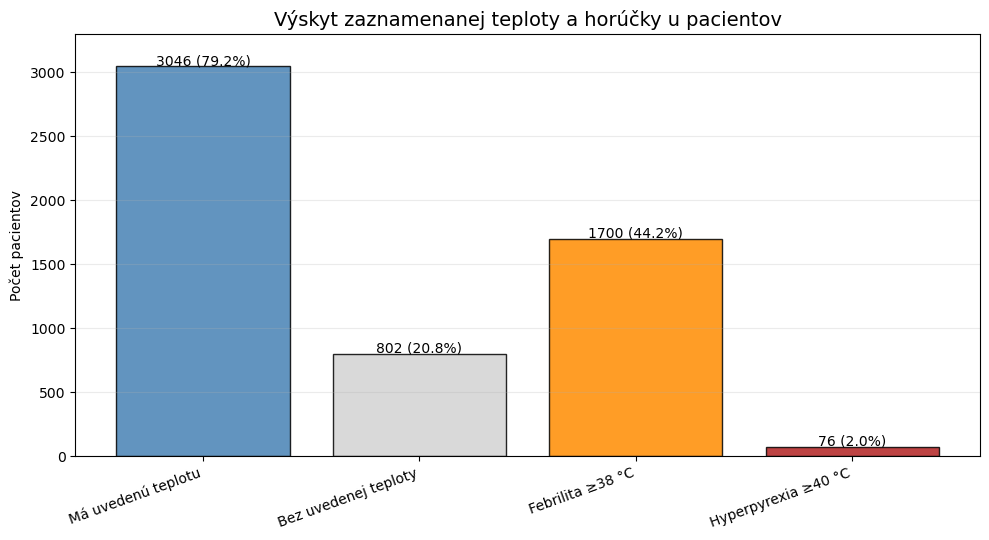

Priemer teploty: 37.92048588312541
Medián teploty: 38.0
Minimálna teplota: 31.0
Maximálna teplota: 45.0
Počet pacientov s uvedenou teplotou: 3046


In [152]:


temp_pattern = (
    r"(?:do|až|cez|nad)?[^\d]{0,5}"
    r"(?:teplota[^\d]{0,8})?"
    r"(\d{2}(?:[.,]\d)?)\s*[°º]?\s*[cC]"
)

columns_temp = [
    "Terajšie ochorenie",
    "Objektívny nález"
]


def extract_temperatures(row, columns, temp_pattern):

    temps = []

    for col in columns:
        text = row.get(col, "")

        if pd.isna(text):
            continue

        text = str(text)

        for match in re.finditer(temp_pattern, text):
            temp_str = match.group(1).replace(",", ".")
            temp = float(temp_str)

            # fyziologicky/plauzibilný rozsah
            if 30 <= temp <= 45:
                temps.append(temp)

    # odstránenie duplicít bez straty poradia
    temps_unique = list(dict.fromkeys(temps))

    return temps_unique


df_f["teploty"] = df_f.apply(
    lambda row: extract_temperatures(
        row,
        columns_temp,
        temp_pattern
    ),
    axis=1
)

df_f[["Poradie", "Vek", "teploty"]].head(40)
def list_min(x):
    if isinstance(x, list) and len(x) > 0:
        return float(np.nanmin(x))
    return np.nan


def list_max(x):
    if isinstance(x, list) and len(x) > 0:
        return float(np.nanmax(x))
    return np.nan


def list_median(x):
    if isinstance(x, list) and len(x) > 0:
        return float(np.nanmedian(x))
    return np.nan


def list_first(x):
    if isinstance(x, list) and len(x) > 0:
        return float(x[0])
    return np.nan

df_f["temp_min"] = df_f["teploty"].apply(list_min)
df_f["temp_max"] = df_f["teploty"].apply(list_max)
df_f["temp_med"] = df_f["teploty"].apply(list_median)
df_f["temp_first"] = df_f["teploty"].apply(list_first)

df_f["has_temp"] = df_f["teploty"].apply(
    lambda x: isinstance(x, list) and len(x) > 0
)

df_f["febrilita"] = df_f["temp_max"] >= 38.0
df_f["hyperpyrexia"] = df_f["temp_max"] >= 40.0

n_total = len(df_f)

summary_temp = pd.DataFrame({
    "Skupina": [
        "Má uvedenú teplotu",
        "Bez uvedenej teploty",
        "Febrilita ≥38 °C",
        "Hyperpyrexia ≥40 °C"
    ],
    "Počet": [
        df_f["has_temp"].sum(),
        (~df_f["has_temp"]).sum(),
        df_f["febrilita"].sum(),
        df_f["hyperpyrexia"].sum()
    ]
})

summary_temp["Percento (%)"] = (
    summary_temp["Počet"] / n_total * 100
).round(1)

summary_temp
labels = summary_temp["Skupina"]
counts = summary_temp["Počet"]
percents = summary_temp["Percento (%)"]

colors = [
    "steelblue",
    "lightgray",
    "darkorange",
    "firebrick"
]

plt.figure(figsize=(10, 5.5))

bars = plt.bar(
    labels,
    counts,
    color=colors,
    edgecolor="black",
    alpha=0.85
)

plt.title("Výskyt zaznamenanej teploty a horúčky u pacientov", fontsize=14)
plt.ylabel("Počet pacientov")
plt.xticks(rotation=20, ha="right")
plt.grid(axis="y", alpha=0.25)

for i, bar in enumerate(bars):
    height = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 10,
        f"{counts.iloc[i]} ({percents.iloc[i]:.1f}%)",
        ha="center",
        fontsize=10
    )

plt.ylim(0, counts.max() + 250)

plt.tight_layout()
plt.show()
temp_values = df_f["temp_max"].dropna()

print("Priemer teploty:", temp_values.mean())
print("Medián teploty:", temp_values.median())
print("Minimálna teplota:", temp_values.min())
print("Maximálna teplota:", temp_values.max())
print("Počet pacientov s uvedenou teplotou:", len(temp_values))


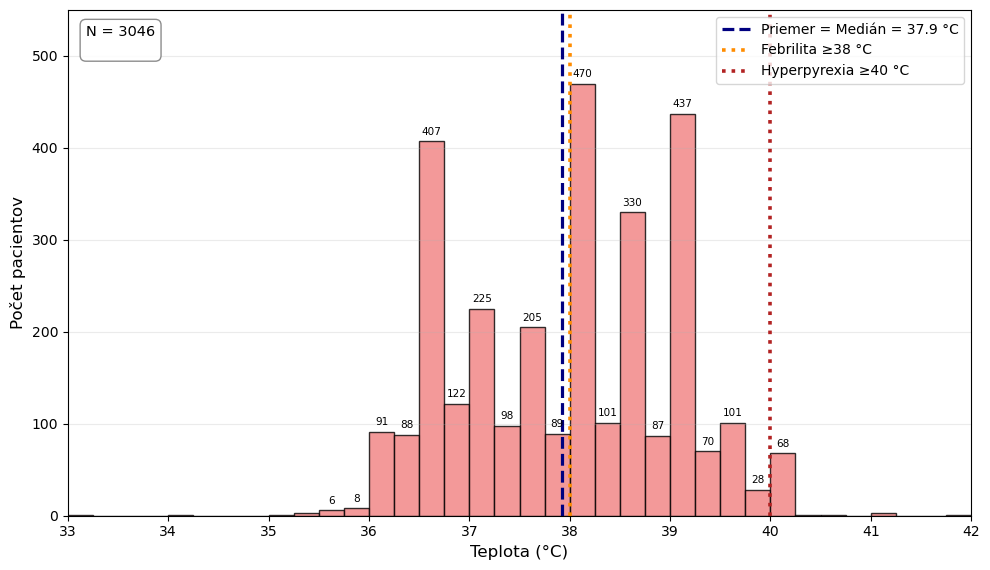

In [153]:
fig, ax = plt.subplots(figsize=(10, 5.8))

temp_values = df_f["temp_max"].dropna()
mean_temp   = temp_values.mean()
n_temp      = len(temp_values)

bins = np.arange(33, 42.25, 0.25)
counts, edges, patches = ax.hist(
    temp_values,
    bins=bins,
    color="lightcoral",
    edgecolor="black",
    alpha=0.8
)

for count, edge in zip(counts, edges):
    if count >= 5:
        ax.text(
            edge + 0.125,
            count + 5,
            f"{int(count)}",
            ha="center", va="bottom",
            fontsize=7.5, color="black"
        )

ax.axvline(mean_temp, color="navy", linestyle="--", linewidth=2.3,
           label=f"Priemer = Medián = {mean_temp:.1f} °C")
ax.axvline(38.0, color="darkorange", linestyle=":", linewidth=2.6,
           label="Febrilita ≥38 °C")
ax.axvline(40.0, color="firebrick", linestyle=":", linewidth=2.6,
           label="Hyperpyrexia ≥40 °C")

ax.set_xlabel("Teplota (°C)", fontsize=12)
ax.set_ylabel("Počet pacientov", fontsize=12)
ax.set_xlim(33, 42)
ax.set_ylim(0, counts.max() + 80)
ax.grid(axis="y", alpha=0.25)

ax.legend(loc="upper right", frameon=True, fontsize=10)

ax.text(
    0.02, 0.97,
    f"N = {n_temp}\n",
    transform=ax.transAxes,
    ha="left", va="top", fontsize=10.5,
    bbox=dict(boxstyle="round,pad=0.4", facecolor="white", edgecolor="gray", alpha=0.9)
)

plt.tight_layout()
plt.show()

## 7.3 Extrakcia symptómov

Z textových stĺpcov sa na základe kľúčových slov detekuje prítomnosť
vybraných symptómov — kašeľ, hnačka, triaska/zimnica, zvracanie a nechutenstvo.
Pre každý symptóm vznikne samostatný binárny stĺpec
a výsledky sa sumarizujú do prehľadovej tabuľky s počtami a percentami.

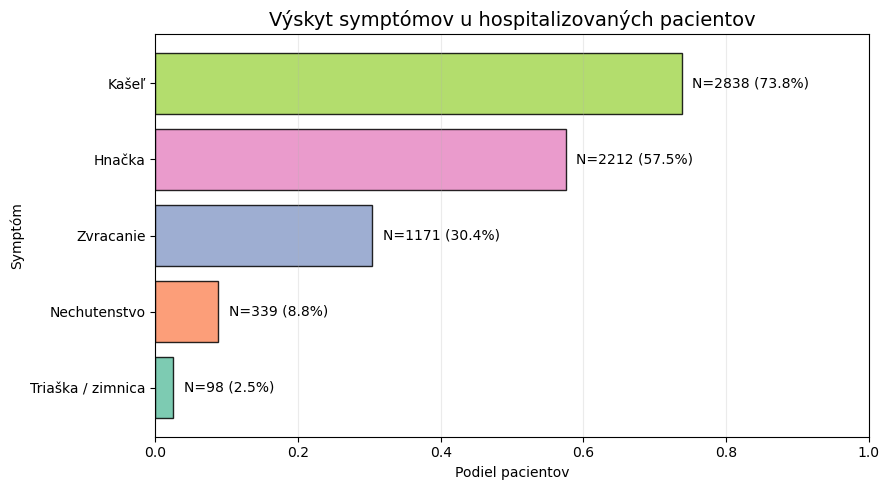

In [154]:
def extract_symptoms_bool(
    df: pd.DataFrame,
    column: str = "Terajšie ochorenie"
) -> pd.DataFrame:

    df = df.copy()

    symptom_patterns = {
        "kasel": r"(ka[šs]e[ľl]|ka[šs]le|such[ýaéi] ka[šs]e[ľl])",

        "hnacka": r"(hna[čc]ka|hna[čc]k[uyiea]|má hna[čc]ku)",

        "triaska_zimnica": r"(tria[šs]ka|zimnic[auiy])",

        "zvracanie": r"(zvracal[ao]?|zvracanie|zvracia[lmns]?|bol[o]? zvracanie)",

        "nechutenstvo": (
            r"(nechutenstv[ioyau]|"
            r"nechut[íia]\s*(jes[tť])?|"
            r"nem[aá] chu[ťt]|"
            r"nepoci[ťt]uje\s*hlad|"
            r"nem[aá] hlad|"
            r"bez chuti do jedla|"
            r"strata apet[ií]tu|"
            r"odmieta jedlo)"
        ),
    }

    for symptom_name, pattern in symptom_patterns.items():
        df[symptom_name] = df[column].apply(
            lambda text: bool(
                re.search(pattern, str(text), re.IGNORECASE)
            )
        )

    return df

symptom_columns = [
    "kasel",
    "hnacka",
    "triaska_zimnica",
    "zvracanie",
    "nechutenstvo"
]

df_f = extract_symptoms_bool(
    df_f,
    column="Terajšie ochorenie"
)

df_f[["Poradie", "Vek"] + symptom_columns].head(20)

symptoms = [
    "kasel",
    "hnacka",
    "triaska_zimnica",
    "zvracanie",
    "nechutenstvo"
]

symptom_labels = {
    "kasel": "Kašeľ",
    "hnacka": "Hnačka",
    "triaska_zimnica": "Triaška / zimnica",
    "zvracanie": "Zvracanie",
    "nechutenstvo": "Nechutenstvo"
}

n_total = len(df_f)

# Súhrn počtov a percent
symptom_summary = pd.DataFrame({
    "Symptóm": symptoms,
    "Počet": [df_f[col].sum() for col in symptoms],
    "Podiel": [df_f[col].mean() for col in symptoms]
})

symptom_summary["Percento"] = symptom_summary["Podiel"] * 100
symptom_summary["Symptóm_label"] = symptom_summary["Symptóm"].map(symptom_labels)

symptom_summary = symptom_summary.sort_values(
    "Podiel",
    ascending=True
)

symptom_summary
plt.figure(figsize=(9, 5))

colors = plt.cm.Set2(range(len(symptom_summary)))

bars = plt.barh(
    symptom_summary["Symptóm_label"],
    symptom_summary["Podiel"],
    color=colors,
    edgecolor="black",
    alpha=0.85
)

for bar, count, percent in zip(
    bars,
    symptom_summary["Počet"],
    symptom_summary["Percento"]
):
    plt.text(
        bar.get_width() + 0.015,
        bar.get_y() + bar.get_height() / 2,
        f"N={int(count)} ({percent:.1f}%)",
        va="center",
        fontsize=10
    )

plt.title("Výskyt symptómov u hospitalizovaných pacientov", fontsize=14)
plt.xlabel("Podiel pacientov")
plt.ylabel("Symptóm")
plt.xlim(0, 1.0)

plt.grid(axis="x", alpha=0.25)

plt.tight_layout()
plt.show()

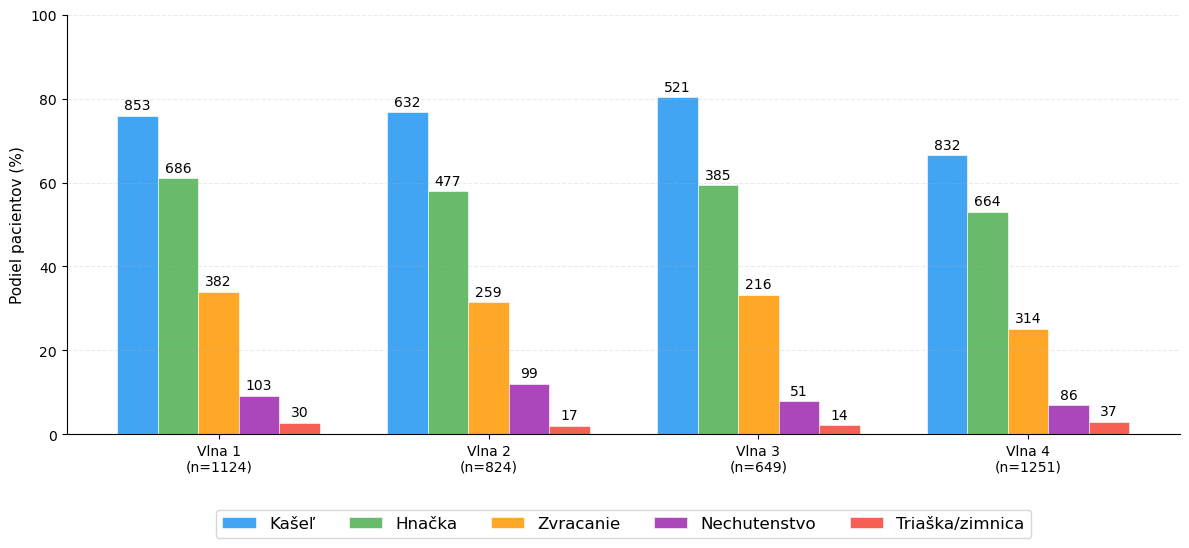

In [155]:
symptomy = {
    "Kašeľ":           "kasel",
    "Hnačka":          "hnacka",
    "Zvracanie":       "zvracanie",
    "Nechutenstvo":    "nechutenstvo",
    "Triaška/zimnica": "triaska_zimnica"
}

vlny = [1, 2, 3, 4]
total_per_wave = df_f.groupby("vlna").size()

x = np.arange(len(vlny))
width = 0.15
colors = ["#2196F3", "#4CAF50", "#FF9800", "#9C27B0", "#F44336"]

fig, ax = plt.subplots(figsize=(12, 5.5))

for i, (label, col) in enumerate(symptomy.items()):
    vals = [
        df_f.loc[df_f["vlna"] == v, col].mean() * 100
        for v in vlny
    ]
    counts = [
        df_f.loc[df_f["vlna"] == v, col].sum()
        for v in vlny
    ]

    bars = ax.bar(
        x + i * width, vals, width=width,
        label=label, color=colors[i],
        alpha=0.85, edgecolor="white", linewidth=0.5
    )

    for bar, val, cnt in zip(bars, vals, counts):
        if val >= 2:
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.8,
                f"{cnt}",
                ha="center", va="bottom",
                fontsize=10, color="black"
            )

# n= pod názvami vĺn
ax.set_xticks(x + width * 2)
ax.set_xticklabels(
    [f"Vlna {v}\n(n={total_per_wave[v]})" for v in vlny],
    fontsize=10
)

ax.set_ylabel("Podiel pacientov (%)", fontsize=11)
ax.set_ylim(0, 100)
ax.grid(axis="y", alpha=0.25, linestyle="--")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, -0.16),
    ncol=5, frameon=True, fontsize=12
)

plt.tight_layout()
plt.subplots_adjust(bottom=0.2)
plt.show()

## 8. Výpočet požadovaných indexov

Na základe extrahovaných laboratórnych hodnôt a poskytnutých vzorcov lekárov UNLP sa vypočítavajú odvodené indexy
zápalového a imunitného stavu pacienta. Tie su rozdelené na 4 skupiny: 
- hematologicé, 
- biochemické, 
- koagulačné,
- kardio-špecifické indexy.

Každá skupina indexov má vlastnú funkciu (`add_hematology_indexes`,
`add_biochemistry_indexes`, `add_coagulation_indexes`, `add_cardiac_indexes`).
`sanitize_indexes` následne ošetrí extrémne a záporné hodnoty vzniknuté
pri výpočte z neúplných dát.

In [156]:
def safe_div(numerator, denominator):
    return numerator / denominator.replace(0, np.nan)

def check_required_columns(df: pd.DataFrame, required_columns: list):

    missing_columns = [
        col for col in required_columns
        if col not in df.columns
    ]

    if missing_columns:
        raise ValueError(
            "V datasete chýbajú tieto stĺpce potrebné na výpočet indexov:\n"
            + "\n".join(missing_columns)
        )

In [157]:
def add_hematology_indexes(df: pd.DataFrame) -> pd.DataFrame:
    df["Monocyty_odhad_prva"] = (
        df["WBC_prva_hodnota"]
        - df["Neu abs_prva_hodnota"]
        - df["Ly abs_prva_hodnota"]
    )

    df["dNLR_prva"] = safe_div(
        df["Neu abs_prva_hodnota"],
        df["WBC_prva_hodnota"] - df["Neu abs_prva_hodnota"]
    )

    # PLR – Platelet-to-Lymphocyte Ratio
    df["PLR_prva"] = safe_div(
        df["PLT_prva_hodnota"],
        df["Ly abs_prva_hodnota"]
    )

    # MLR – Monocyte-to-Lymphocyte Ratio
    df["MLR_dNLR_prva"] = safe_div(
        df["dNLR_prva"],
        df["Ly abs_prva_hodnota"]
    )

    df["MLR_mon_prva"] = safe_div(
        df["Monocyty_odhad_prva"],
        df["Ly abs_prva_hodnota"]
    )

    # NMR – Neutrophil-to-Monocyte Ratio
    df["NMR_dNLR_prva"] = safe_div(
        df["Neu abs_prva_hodnota"],
        df["dNLR_prva"]
    )

    df["NMR_mon_prva"] = safe_div(
        df["Neu abs_prva_hodnota"],
        df["Monocyty_odhad_prva"]
    )

    # SII – Systemic Immune-Inflammation Index
    df["SII_prva"] = safe_div(
        df["PLT_prva_hodnota"] * df["Neu abs_prva_hodnota"],
        df["Ly abs_prva_hodnota"]
    )

    # SIRI – Systemic Inflammatory Response Index
    df["SIRI_dNLR_prva"] = safe_div(
        df["Neu abs_prva_hodnota"] * df["dNLR_prva"],
        df["Ly abs_prva_hodnota"]
    )

    df["SIRI_mon_prva"] = safe_div(
        df["Neu abs_prva_hodnota"] * df["Monocyty_odhad_prva"],
        df["Ly abs_prva_hodnota"]
    )

    # AISI – Aggregate Index of Systemic Inflammation
    df["AISI_prva"] = safe_div(
        df["Neu abs_prva_hodnota"] *
        df["dNLR_prva"] *
        df["PLT_prva_hodnota"],
        df["Ly abs_prva_hodnota"]
    )

    df["AISI_mon_prva"] = safe_div(
        df["Neu abs_prva_hodnota"] *
        df["Monocyty_odhad_prva"] *
        df["PLT_prva_hodnota"],
        df["Ly abs_prva_hodnota"]
    )

    return df

In [158]:
def add_biochemistry_indexes(df: pd.DataFrame) -> pd.DataFrame:

    df["CAR_prva"] = safe_div(
        df["S-CRP_prva_hodnota"],
        df["S-Alb_prva_hodnota"]
    )

    df["CLR_prva"] = safe_div(
        df["S-CRP_prva_hodnota"],
        df["Ly abs_prva_hodnota"]
    )

    df["FER_Ly_prva"] = safe_div(
        df["S-FER_prva_hodnota"],
        df["Ly abs_prva_hodnota"]
    )

    df["FAR_prva"] = safe_div(
        df["Fib_prva_hodnota"],
        df["S-Alb_prva_hodnota"]
    )

    df["Urea_Cr_prva"] = safe_div(
        df["S-Urea_prva_hodnota"],
        df["S-Kreat_prva_hodnota"]
    )

    df["BUN_Cr_prva"] = safe_div(
        df["S-Urea_prva_hodnota"] * 2.8,
        df["S-Kreat_prva_hodnota"]
    )

    df["DeRitis_prva"] = safe_div(
        df["S-AST_prva_hodnota"],
        df["S-ALT_prva_hodnota"]
    )

    df["AST_PLT_prva"] = safe_div(
        df["S-AST_prva_hodnota"],
        df["PLT_prva_hodnota"]
    )

    df["AST_Alb_prva"] = safe_div(
        df["S-AST_prva_hodnota"],
        df["S-Alb_prva_hodnota"]
    )

    df["LDH_Alb_prva"] = safe_div(
        df["S-LD_prva_hodnota"],
        df["S-Alb_prva_hodnota"]
    )

    return df

In [159]:
def add_coagulation_indexes(df: pd.DataFrame) -> pd.DataFrame:

    df["DLR_prva"] = safe_div(
        df["D-dimér HS_prva_hodnota"],
        df["Ly abs_prva_hodnota"]
    )

    df["D-dimer_Alb_prva"] = safe_div(
        df["D-dimér HS_prva_hodnota"],
        df["S-Alb_prva_hodnota"]
    )

    df["Fib_Ly_prva"] = safe_div(
        df["Fib_prva_hodnota"],
        df["Ly abs_prva_hodnota"]
    )

    df["PLT_Fib_prva"] = safe_div(
        df["PLT_prva_hodnota"],
        df["Fib_prva_hodnota"]
    )

    return df

In [160]:
def add_cardiac_indexes(df: pd.DataFrame) -> pd.DataFrame:

    df["BNP_Ly_prva"] = safe_div(
        df["S-PBNP_prva_hodnota"],
        df["Ly abs_prva_hodnota"]
    )

    df["ILD_prva"] = (
        df["NE/LY(NLR)_prva_hodnota"] *
        df["DeRitis_prva"]
    )

    df["IRD_prva"] = (
        df["NE/LY(NLR)_prva_hodnota"] *
        safe_div(
            df["S-Kreat_prva_hodnota"],
            df["S-Alb_prva_hodnota"]
        )
    )

    df["ICoag_prva"] = (
        df["NE/LY(NLR)_prva_hodnota"] *
        safe_div(
            df["D-dimér HS_prva_hodnota"],
            df["PLT_prva_hodnota"]
        )
    )

    df["IROD_satbezO2_prva"] = safe_div(
        df["NE/LY(NLR)_prva_hodnota"] *
        df["S-Kreat_prva_hodnota"],
        df["sat_bez_o2_prva"]
    )

    df["IROD_satO2_prva"] = safe_div(
        df["NE/LY(NLR)_prva_hodnota"] *
        df["S-Kreat_prva_hodnota"],
        df["sat_s_o2_prva"]
    )

    df["CLIF_COVID_prva"] = (
        df["NE/LY(NLR)_prva_hodnota"] *
        df["D-dimér HS_prva_hodnota"] *
        df["DeRitis_prva"]
    )

    return df

In [161]:
def sanitize_indexes(df: pd.DataFrame, index_cols: list = None) -> pd.DataFrame:

    if index_cols is None:
        index_cols = [c for c in df.columns if c.endswith("_prva")]

    report = []

    for col in index_cols:
        if col not in df.columns:
            continue

        neg_mask = df[col] < 0
        neg_count = neg_mask.sum()

        if neg_count > 0:
            df.loc[neg_mask, col] = np.nan
            report.append({
                "Index": col,
                "Nahradených NaN": neg_count,
                "Percento (%)": round(neg_count / len(df) * 100, 2)
            })

    if report:
        print("=== Záporné hodnoty nahradené NaN ===")
        print(pd.DataFrame(report).to_string(index=False))
    else:
        print("Žiadne záporné hodnoty nenájdené.")

    return df

In [162]:
#  Výpočet odvodených klinicko-laboratórnych indexov
def add_all_indexes_first(df: pd.DataFrame) -> pd.DataFrame:

    df = df.copy()

    required_columns = [
        "WBC_prva_hodnota",
        "Neu abs_prva_hodnota",
        "Ly abs_prva_hodnota",
        "PLT_prva_hodnota",
        "S-CRP_prva_hodnota",
        "S-Alb_prva_hodnota",
        "S-FER_prva_hodnota",
        "Fib_prva_hodnota",
        "S-Urea_prva_hodnota",
        "S-Kreat_prva_hodnota",
        "S-AST_prva_hodnota",
        "S-ALT_prva_hodnota",
        "S-LD_prva_hodnota",
        "D-dimér HS_prva_hodnota",
        "S-PBNP_prva_hodnota",
        "NE/LY(NLR)_prva_hodnota",
        "sat_bez_o2_prva",
        "sat_s_o2_prva",
    ]

    check_required_columns(df, required_columns)

    df = add_hematology_indexes(df)
    df = add_biochemistry_indexes(df)
    df = add_coagulation_indexes(df)
    df = add_cardiac_indexes(df)

    df.replace([np.inf, -np.inf], np.nan, inplace=True)

    return df


# Výpočet indexov
df_f = add_all_indexes_first(df_f)

#  Kontrola vytvorených indexov
index_columns_first = [
    "Monocyty_odhad_prva",
    "dNLR_prva",
    "PLR_prva",
    "MLR_dNLR_prva",
    "MLR_mon_prva",
    "NMR_dNLR_prva",
    "NMR_mon_prva",
    "SII_prva",
    "SIRI_dNLR_prva",
    "SIRI_mon_prva",
    "AISI_prva",
    "AISI_mon_prva",
    "CAR_prva",
    "CLR_prva",
    "FER_Ly_prva",
    "FAR_prva",
    "Urea_Cr_prva",
    "BUN_Cr_prva",
    "DeRitis_prva",
    "AST_PLT_prva",
    "AST_Alb_prva",
    "LDH_Alb_prva",
    "DLR_prva",
    "D-dimer_Alb_prva",
    "Fib_Ly_prva",
    "PLT_Fib_prva",
    "BNP_Ly_prva",
    "ILD_prva",
    "IRD_prva",
    "ICoag_prva",
    "IROD_satbezO2_prva",
    "IROD_satO2_prva",
    "CLIF_COVID_prva",
]

index_columns_first_existing = [
    col for col in index_columns_first
    if col in df_f.columns
]

missing_index_cols = [
    col for col in index_columns_first
    if col not in df_f.columns
]

print(f"Dostupné indexy: {len(index_columns_first_existing)} / {len(index_columns_first)}")

if missing_index_cols:
    print("\nChýbajúce indexy:")
    print(missing_index_cols)
else:
    print("\nVšetky očakávané indexy boli vytvorené.")



#  Náhľad vybraných dôležitých stĺpcov po výpočte indexov
preview_columns = [
    "Poradie",
    "Vek",
    "Pohlavie",
    "Kód prepustenia",
    "Stav prepustenia",

    "sat_bez_o2_prva",
    "sat_bez_o2_min",
    "sat_s_o2_prva",
    "sat_s_o2_min",
    "sat_neurcene_prva",
    "sat_neurcene_min",

    "temp_max",
    "febrilita",
    "hyperpyrexia",

    "NE/LY(NLR)_prva_hodnota",
    "S-CRP_prva_hodnota",
    "S-Alb_prva_hodnota",
    "S-Kreat_prva_hodnota",
    "D-dimér HS_prva_hodnota",

    "PLR_prva",
    "SII_prva",
    "DeRitis_prva",
    "ILD_prva",
    "IRD_prva",
    "CLIF_COVID_prva",
]

preview_columns_existing = [
    col for col in preview_columns
    if col in df_f.columns
]

df_f[preview_columns_existing].head(20)

Dostupné indexy: 33 / 33

Všetky očakávané indexy boli vytvorené.


,Poradie,Vek,Pohlavie,Kód prepustenia,Stav prepustenia,sat_bez_o2_prva,sat_bez_o2_min,sat_s_o2_prva,sat_s_o2_min,sat_neurcene_prva,...,S-CRP_prva_hodnota,S-Alb_prva_hodnota,S-Kreat_prva_hodnota,D-dimér HS_prva_hodnota,PLR_prva,SII_prva,DeRitis_prva,ILD_prva,IRD_prva,CLIF_COVID_prva
0,1,75,Žena,1,prepustenie amb. star.,96.0,96.0,NaN,NaN,NaN,...,111.81,34.9,50.0,0.725,280.526316,1357.747368,1.176471,3.000000,3.653295,2.175000
1,2,65,Žena,1,preložený,NaN,NaN,86.0,86.0,86.0,...,46.79,NaN,73.8,1.086,242.622951,1567.344262,1.046512,9.879070,NaN,10.728670
2,3,64,Žena,6,exitus letalis,NaN,NaN,80.0,80.0,80.0,...,309.14,35.1,118.3,0.986,114.035088,245.175439,1.265306,1.644898,4.381481,1.621869
3,4,67,Muž,1,prepustenie amb. star.,100.0,100.0,100.0,100.0,NaN,...,29.83,34.1,77.2,0.301,197.457627,1190.669492,0.878788,4.455455,11.478123,1.341092
4,5,82,Muž,6,exitus letalis,NaN,NaN,94.0,94.0,94.0,...,258.95,38.7,133.6,14.242,21.428571,133.928571,2.500000,15.875000,21.921447,226.091750
5,6,74,Žena,3,preložený,NaN,NaN,NaN,NaN,NaN,...,42.42,35.4,98.7,1.565,110.416667,447.187500,1.687500,11.542500,19.070847,18.064012
6,7,48,Muž,1,prepustenie amb. star.,92.0,92.0,NaN,NaN,NaN,...,77.75,45.0,89.5,0.408,194.782609,1291.408696,0.526316,NaN,NaN,NaN
7,8,36,Muž,1,prepustenie amb. star.,93.0,93.0,91.0,91.0,NaN,...,123.15,30.3,140.8,0.947,137.500000,867.625000,1.176829,7.425793,29.321716,7.032226
8,9,79,Žena,3,preložený,NaN,NaN,NaN,NaN,NaN,...,48.63,38.0,178.4,NaN,192.307692,953.846154,1.076923,7.193846,31.360842,NaN
9,10,84,Muž,3,ARO/OAIM,NaN,NaN,94.0,94.0,NaN,...,142.93,NaN,66.5,1.938,108.227848,364.727848,2.137255,9.339804,NaN,18.100540


In [163]:
df_f = add_hematology_indexes(df_f)
df_f = add_biochemistry_indexes(df_f)
df_f = add_coagulation_indexes(df_f)
df_f = add_cardiac_indexes(df_f)

# Kontrola a sanitizácia
df_f = sanitize_indexes(df_f)

=== Záporné hodnoty nahradené NaN ===
              Index  Nahradených NaN  Percento (%)
Monocyty_odhad_prva                9          0.23
          dNLR_prva                4          0.10
      MLR_dNLR_prva                4          0.10
       MLR_mon_prva                9          0.23
      NMR_dNLR_prva                4          0.10
       NMR_mon_prva                9          0.23
     SIRI_dNLR_prva                4          0.10
      SIRI_mon_prva                9          0.23
          AISI_prva                4          0.10
      AISI_mon_prva                9          0.23


In [164]:
df_f[index_columns_first_existing].describe().T.round(3)

,count,mean,std,min,25%,50%,75%,max
Monocyty_odhad_prva,3799.0,0.741,5.838,0.030,0.330,0.510,0.770,347.480
dNLR_prva,3804.0,3.653,15.812,0.007,1.545,2.590,4.248,961.000
PLR_prva,3808.0,249.293,213.864,1.103,128.571,193.016,302.565,3614.286
MLR_dNLR_prva,3804.0,5.956,32.706,0.000,1.071,2.319,5.339,1635.417
MLR_mon_prva,3799.0,0.638,1.174,0.008,0.302,0.452,0.703,46.957
NMR_dNLR_prva,3804.0,2.134,6.895,0.010,1.180,1.660,2.270,354.880
NMR_mon_prva,3799.0,10.504,7.687,0.008,5.349,8.434,13.293,80.000
SII_prva,3808.0,1488.011,2311.120,4.949,401.602,824.901,1672.667,32893.575
SIRI_dNLR_prva,3804.0,45.807,286.148,0.002,3.374,9.929,30.236,12838.021
SIRI_mon_prva,3799.0,6.648,149.544,0.012,0.906,1.926,4.143,9200.260


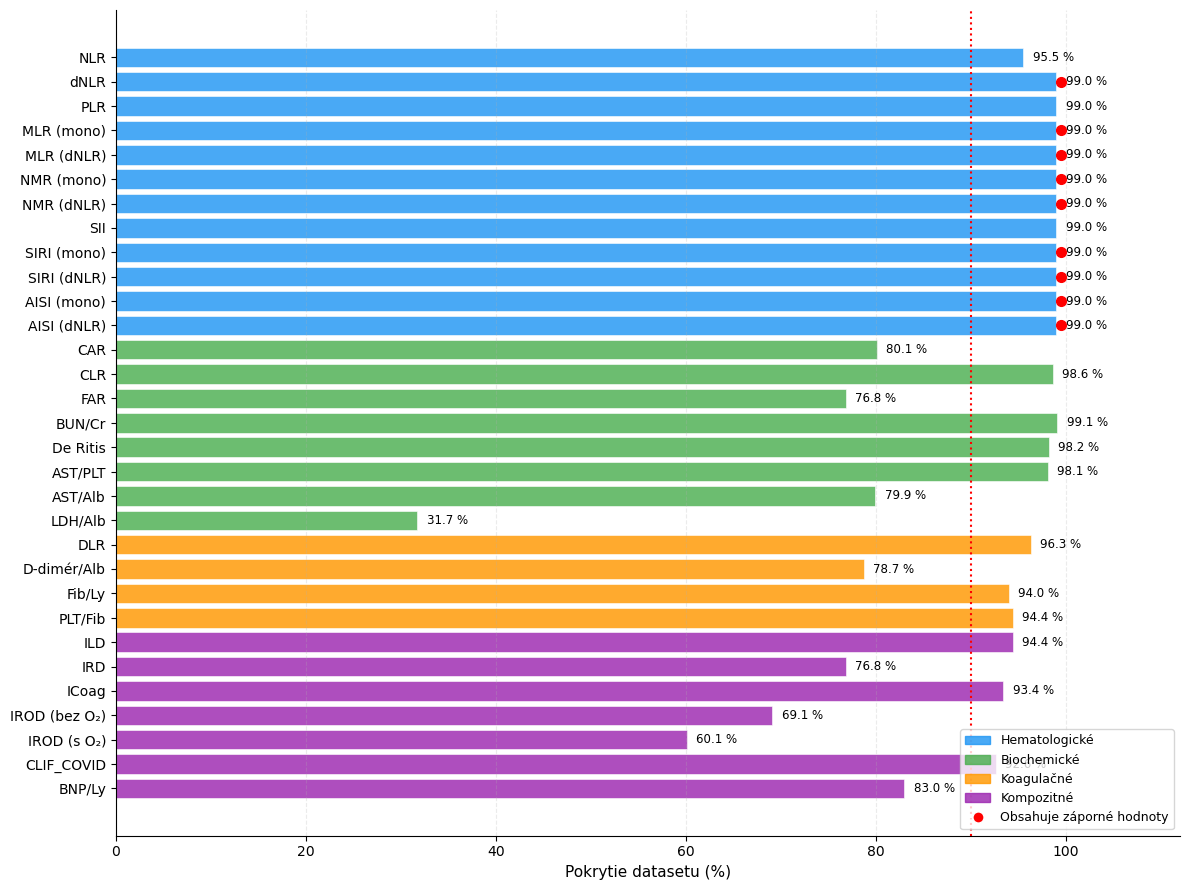

In [165]:
import matplotlib.patches as mpatches
# Dáta
data = {
    'Index':    ['NLR','dNLR','PLR','MLR (mono)','MLR (dNLR)','NMR (mono)','NMR (dNLR)',
                 'SII','SIRI (mono)','SIRI (dNLR)','AISI (mono)','AISI (dNLR)',
                 'CAR','CLR','FAR','BUN/Cr','De Ritis','AST/PLT','AST/Alb','LDH/Alb',
                 'DLR','D-dimér/Alb','Fib/Ly','PLT/Fib',
                 'ILD','IRD','ICoag','IROD (bez O₂)','IROD (s O₂)','CLIF_COVID','BNP/Ly'],
    'Skupina':  (['Hematologické']*12 + ['Biochemické']*8 +
                 ['Koagulačné']*4 + ['Kompozitné']*7),
    'Pokrytie': [95.5,99.0,99.0,99.0,99.0,99.0,99.0,99.0,99.0,99.0,99.0,99.0,
                 80.1,98.6,76.8,99.1,98.2,98.1,79.9,31.7,
                 96.3,78.7,94.0,94.4,
                 94.4,76.8,93.4,69.1,60.1,92.6,83.0],
    'Záporné':  [0,4,0,9,4,9,4,0,9,4,9,4,
                 0,0,0,0,0,0,0,0,
                 0,0,0,0,
                 0,0,0,0,0,0,0],
}

df_idx = pd.DataFrame(data)

# Farby skupín
group_colors = {
    'Hematologické': '#2196F3',
    'Biochemické':   '#4CAF50',
    'Koagulačné':    '#FF9800',
    'Kompozitné':    '#9C27B0'
}

colors = [group_colors[g] for g in df_idx['Skupina']]

fig, ax = plt.subplots(figsize=(12, 9))

bars = ax.barh(
    df_idx['Index'],
    df_idx['Pokrytie'],
    color=colors,
    alpha=0.82,
    edgecolor='white',
    linewidth=0.5
)

# Červená bodka pre indexy so zápornými hodnotami
for i, (neg, pct) in enumerate(zip(df_idx['Záporné'], df_idx['Pokrytie'])):
    if neg > 0:
        ax.plot(pct + 0.5, i, marker='o', color='red',
                markersize=7, zorder=5)

# Percentá na konci stĺpcov
for bar, val in zip(bars, df_idx['Pokrytie']):
    ax.text(val + 1, bar.get_y() + bar.get_height()/2,
            f'{val:.1f} %', va='center', fontsize=8.5)

ax.axvline(90, color='red', linestyle=':', linewidth=1.5, label='90 % hranica')
ax.set_xlim(0, 112)
ax.set_xlabel('Pokrytie datasetu (%)', fontsize=11)
ax.grid(axis='x', alpha=0.25, linestyle='--')
ax.invert_yaxis()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Legenda skupín
patches = [mpatches.Patch(color=c, label=g, alpha=0.82)
           for g, c in group_colors.items()]
red_dot = plt.Line2D([0],[0], marker='o', color='w',
                     markerfacecolor='red', markersize=8,
                     label='Obsahuje záporné hodnoty')
ax.legend(handles=patches + [red_dot],
          loc='lower right', fontsize=9, frameon=True)

plt.tight_layout()
plt.show()

In [166]:
negative_mono = df_f[df_f["Monocyty_odhad_prva"] < 0]

negative_mono[
    [
        "Poradie",
        "WBC_prva_hodnota",
        "Neu abs_prva_hodnota",
        "Ly abs_prva_hodnota",
        "Monocyty_odhad_prva"
    ]
].head(30)



,Poradie,WBC_prva_hodnota,Neu abs_prva_hodnota,Ly abs_prva_hodnota,Monocyty_odhad_prva


In [167]:
dnlr_check = df_f[
    (df_f["dNLR_prva"] < 0) |
    (df_f["dNLR_prva"] > 100)
]

dnlr_check[
    [
        "Poradie",
        "WBC_prva_hodnota",
        "Neu abs_prva_hodnota",
        "Ly abs_prva_hodnota",
        "dNLR_prva"
    ]
].head(30)

,Poradie,WBC_prva_hodnota,Neu abs_prva_hodnota,Ly abs_prva_hodnota,dNLR_prva
929,930,9.62,9.61,0.98,961.0


In [168]:
extreme_cols = [
    "dNLR_prva",
    "AISI_prva",
    "BNP_Ly_prva",
    "DeRitis_prva",
    "ILD_prva",
    "CLIF_COVID_prva"
]

for col in extreme_cols:
    print(f"\n{col}")
    display(
        df_f[
            [
                "Poradie",
                col,
                "WBC_prva_hodnota",
                "Neu abs_prva_hodnota",
                "Ly abs_prva_hodnota",
                "PLT_prva_hodnota",
                "S-AST_prva_hodnota",
                "S-ALT_prva_hodnota",
                "S-PBNP_prva_hodnota"
            ]
        ].sort_values(col, ascending=False).head(10)
    )


dNLR_prva


,Poradie,dNLR_prva,WBC_prva_hodnota,Neu abs_prva_hodnota,Ly abs_prva_hodnota,PLT_prva_hodnota,S-AST_prva_hodnota,S-ALT_prva_hodnota,S-PBNP_prva_hodnota
929,930,961.000000,9.62,9.61,0.98,230.0,1.32,0.81,239.2
2969,2970,49.062500,8.01,7.85,0.03,77.0,0.15,0.53,1462.0
1290,1291,36.292683,15.29,14.88,0.17,175.0,0.83,0.39,NaN
2497,2498,28.546875,18.91,18.27,0.22,277.0,2.70,2.74,11689.0
3716,3717,25.407767,27.20,26.17,0.66,56.0,0.49,0.41,2432.0
1840,1841,24.031746,15.77,15.14,0.22,228.0,0.70,0.38,5356.0
2787,2788,23.635514,26.36,25.29,0.32,242.0,1.61,1.23,8045.0
2920,2921,23.111111,6.51,6.24,0.15,54.0,1.10,0.69,697.4
241,242,22.552239,31.56,30.22,0.73,50.0,0.86,0.23,904.9
2674,2675,22.535714,13.18,12.62,0.22,325.0,0.32,0.16,3449.0



AISI_prva


,Poradie,AISI_prva,WBC_prva_hodnota,Neu abs_prva_hodnota,Ly abs_prva_hodnota,PLT_prva_hodnota,S-AST_prva_hodnota,S-ALT_prva_hodnota,S-PBNP_prva_hodnota
929,930,2.167447e+06,9.62,9.61,0.98,230.0,1.32,0.81,239.2
2969,2970,9.885276e+05,8.01,7.85,0.03,77.0,0.15,0.53,1462.0
2497,2498,6.566806e+05,18.91,18.27,0.22,277.0,2.70,2.74,11689.0
2068,2069,6.425770e+05,32.24,30.67,0.40,429.0,0.36,0.15,27021.0
1290,1291,5.559185e+05,15.29,14.88,0.17,175.0,0.83,0.39,NaN
161,162,4.679555e+05,19.28,18.02,0.38,690.0,NaN,NaN,NaN
2787,2788,4.520425e+05,26.36,25.29,0.32,242.0,1.61,1.23,8045.0
2674,2675,4.201374e+05,13.18,12.62,0.22,325.0,0.32,0.16,3449.0
3564,3565,4.081482e+05,12.03,11.44,0.15,276.0,NaN,NaN,NaN
3507,3508,3.913504e+05,13.67,12.88,0.22,410.0,1.04,0.91,NaN



BNP_Ly_prva


...

,Poradie,DeRitis_prva,WBC_prva_hodnota,Neu abs_prva_hodnota,Ly abs_prva_hodnota,PLT_prva_hodnota,S-AST_prva_hodnota,S-ALT_prva_hodnota,S-PBNP_prva_hodnota
1379,1380,244.206897,6.60,4.32,1.58,189.0,70.82,0.29,11086.0
2694,2695,12.166667,10.02,7.55,1.42,197.0,0.73,0.06,163.9
535,536,11.000000,3.50,1.87,1.00,179.0,0.33,0.03,29220.0
1169,1170,8.196429,17.88,16.29,0.50,209.0,4.59,0.56,4003.0
3323,3324,7.371429,7.81,5.81,1.44,179.0,2.58,0.35,13265.0
127,128,6.857143,5.01,4.20,0.52,213.0,0.96,0.14,1177.0
2923,2924,6.647482,9.62,7.72,1.16,130.0,9.24,1.39,286.2
3637,3638,6.544248,15.95,13.07,1.13,217.0,14.79,2.26,1443.0
3299,3300,6.108108,3.26,2.25,0.59,25.0,2.26,0.37,405.1
2871,2872,5.924171,7.67,6.44,0.71,162.0,12.50,2.11,2686.0



ILD_prva


,Poradie,ILD_prva,WBC_prva_hodnota,Neu abs_prva_hodnota,Ly abs_prva_hodnota,PLT_prva_hodnota,S-AST_prva_hodnota,S-ALT_prva_hodnota,S-PBNP_prva_hodnota
1379,1380,12041.842069,6.60,4.32,1.58,189.0,70.82,0.29,11086.0
155,156,334.844390,15.08,13.94,0.66,121.0,1.58,0.82,7264.0
1169,1170,268.596964,17.88,16.29,0.50,209.0,4.59,0.56,4003.0
2972,2973,237.275294,8.79,7.91,0.09,160.0,0.42,0.17,3230.0
2718,2719,214.173529,15.33,13.96,0.21,289.0,2.79,0.85,26578.0
2405,2406,209.554000,12.11,11.17,0.75,316.0,0.29,0.15,286.0
3393,3394,191.850968,402.23,311.13,2.98,17.0,1.14,0.62,5304.0
2068,2069,184.944000,32.24,30.67,0.40,429.0,0.36,0.15,27021.0
1290,1291,182.025385,15.29,14.88,0.17,175.0,0.83,0.39,NaN
364,365,171.327724,10.22,9.64,0.17,222.0,20.57,8.48,6807.0



CLIF_COVID_prva


,Poradie,CLIF_COVID_prva,WBC_prva_hodnota,Neu abs_prva_hodnota,Ly abs_prva_hodnota,PLT_prva_hodnota,S-AST_prva_hodnota,S-ALT_prva_hodnota,S-PBNP_prva_hodnota
2436,2437,7855.623231,4.63,3.95,0.54,211.0,0.57,0.28,797.3
175,176,5617.434753,5.55,4.19,1.16,153.0,1.31,0.91,2023.0
1169,1170,5315.802520,17.88,16.29,0.50,209.0,4.59,0.56,4003.0
184,185,4856.317625,11.36,9.96,0.67,201.0,0.62,0.22,2955.0
3393,3394,4677.710295,402.23,311.13,2.98,17.0,1.14,0.62,5304.0
2350,2351,4052.261285,16.39,14.38,0.95,276.0,8.18,3.01,2614.0
927,928,3992.235595,9.38,8.16,0.78,162.0,0.99,0.29,851.6
1562,1563,2901.305829,10.01,8.50,1.12,195.0,2.00,0.70,NaN
1543,1544,2315.895579,11.53,8.91,1.65,59.0,0.45,0.29,2218.0
2914,2915,2188.413709,13.97,12.19,0.77,120.0,3.18,2.43,11784.0


## 9. Vizualizácia dát

In [169]:

def list_min(x):
    if isinstance(x, list) and len(x) > 0:
        return float(np.nanmin(x))
    return np.nan

def list_median(x):
    if isinstance(x, list) and len(x) > 0:
        return float(np.nanmedian(x))
    return np.nan

df_f["sat_bez_o2_min"] = df_f["sat_bez_o2"].apply(list_min)
df_f["sat_s_o2_min"] = df_f["sat_s_o2"].apply(list_min)

df_f["sat_bez_o2_med"] = df_f["sat_bez_o2"].apply(list_median)
df_f["sat_s_o2_med"] = df_f["sat_s_o2"].apply(list_median)

df_f["sat_neurcene_min"] = df_f["sat_neurcene"].apply(list_min)
df_f["sat_neurcene_med"] = df_f["sat_neurcene"].apply(list_median)

In [170]:
def spo2_category_table(series: pd.Series, label: str) -> pd.DataFrame:
    """
    Vytvorí tabuľku kategórií SpO₂ pre zadanú sériu hodnôt.
    """
    spo2 = series.dropna()

    bins = [0, 80, 90, 95, 101]
    labels = ["<80 %", "80–89 %", "90–94 %", "≥95 %"]

    groups = pd.cut(
        spo2,
        bins=bins,
        labels=labels,
        right=False
    )

    counts = groups.value_counts().sort_index()
    percents = (counts / len(spo2) * 100).round(1)

    return pd.DataFrame({
        "Kategória": counts.index.astype(str),
        f"{label} N": counts.values.astype(int),
        f"{label} %": percents.values
    })

# Tabuľky pre jednotlivé typy saturácie
t_bez = spo2_category_table(df_f["sat_bez_o2_min"], "Bez O₂")
t_o2 = spo2_category_table(df_f["sat_s_o2_min"], "S O₂")
t_neurcene = spo2_category_table(df_f["sat_neurcene_min"], "Neurčené")

# Spojenie do jednej tabuľky
spo2_summary_table = (
    t_bez
    .merge(t_o2, on="Kategória", how="outer")
    .merge(t_neurcene, on="Kategória", how="outer")
    .fillna(0)
)

spo2_summary_table

,Kategória,Bez O₂ N,Bez O₂ %,S O₂ N,S O₂ %,Neurčené N,Neurčené %
0,80–89 %,538,19.6,463,19.5,243,17.6
1,90–94 %,1006,36.6,816,34.4,413,29.9
2,<80 %,175,6.4,163,6.9,238,17.2
3,≥95 %,1031,37.5,928,39.2,487,35.3


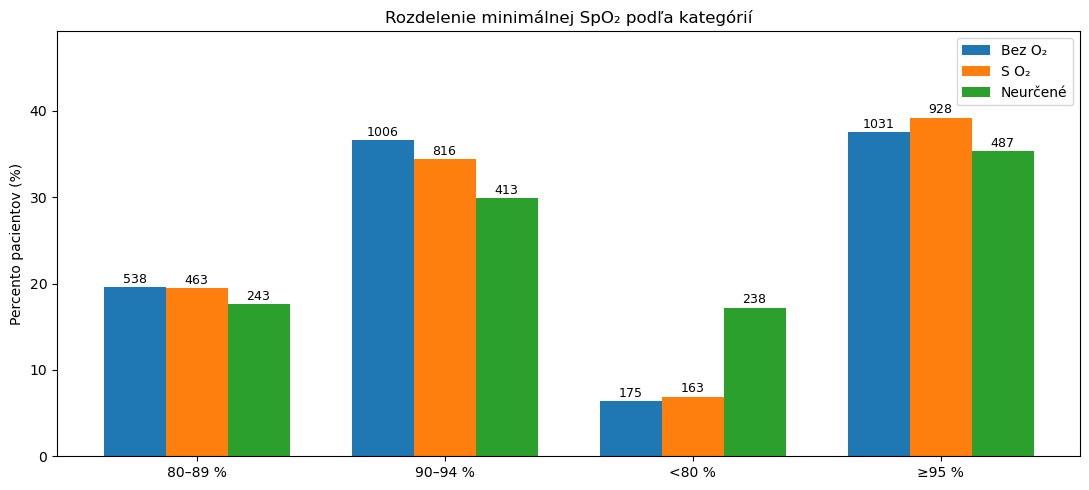

In [171]:
x = np.arange(len(spo2_summary_table["Kategória"]))
width = 0.25

plt.figure(figsize=(11, 5))

bars_bez = plt.bar(
    x - width,
    spo2_summary_table["Bez O₂ %"],
    width,
    label="Bez O₂"
)

bars_o2 = plt.bar(
    x,
    spo2_summary_table["S O₂ %"],
    width,
    label="S O₂"
)

bars_neurcene = plt.bar(
    x + width,
    spo2_summary_table["Neurčené %"],
    width,
    label="Neurčené"
)

# Počty nad stĺpcami
for bars, n_col in [
    (bars_bez, "Bez O₂ N"),
    (bars_o2, "S O₂ N"),
    (bars_neurcene, "Neurčené N")
]:
    for i, bar in enumerate(bars):
        n = int(spo2_summary_table[n_col].iloc[i])
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.5,
            f"{n}",
            ha="center",
            fontsize=9
        )

plt.xticks(x, spo2_summary_table["Kategória"])
plt.ylabel("Percento pacientov (%)")
plt.title("Rozdelenie minimálnej SpO₂ podľa kategórií")
plt.legend()

plt.ylim(
    0,
    max(
        spo2_summary_table["Bez O₂ %"].max(),
        spo2_summary_table["S O₂ %"].max(),
        spo2_summary_table["Neurčené %"].max()
    ) + 10
)

plt.tight_layout()
plt.show()

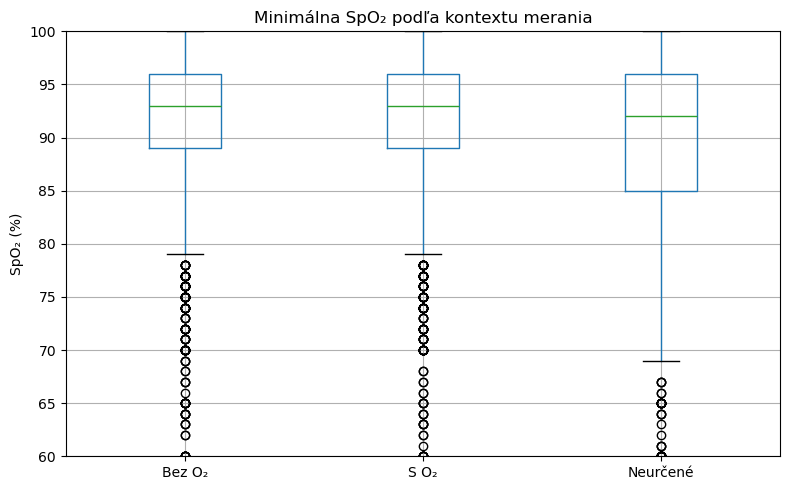

In [172]:
spo2_boxplot_df = df_f[
    [
        "sat_bez_o2_min",
        "sat_s_o2_min",
        "sat_neurcene_min"
    ]
].copy()

spo2_boxplot_df = spo2_boxplot_df.rename(columns={
    "sat_bez_o2_min": "Bez O₂",
    "sat_s_o2_min": "S O₂",
    "sat_neurcene_min": "Neurčené"
})

plt.figure(figsize=(8, 5))

spo2_boxplot_df.boxplot()

plt.title("Minimálna SpO₂ podľa kontextu merania")
plt.ylabel("SpO₂ (%)")
plt.ylim(60, 100)

plt.tight_layout()
plt.show()

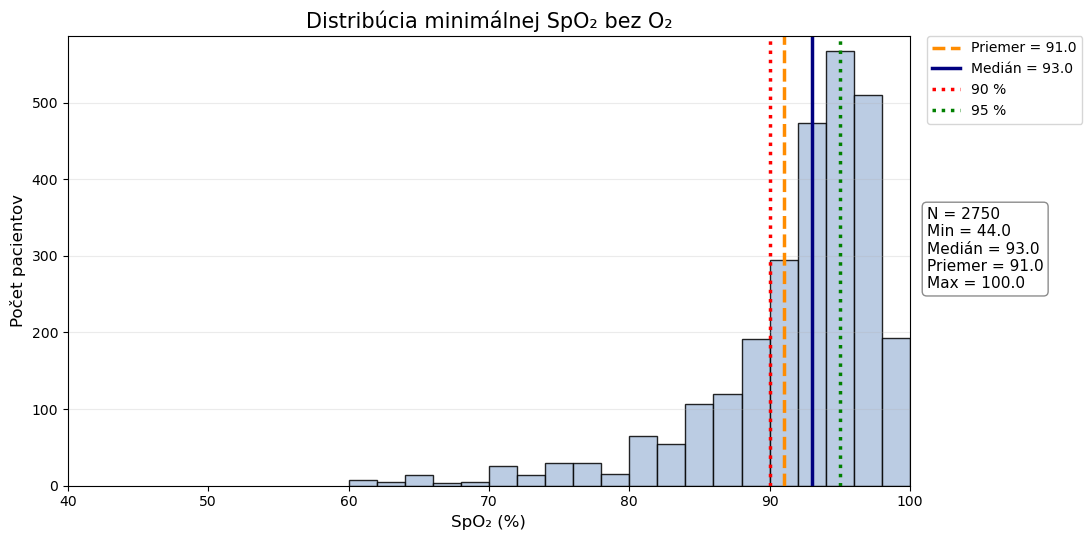

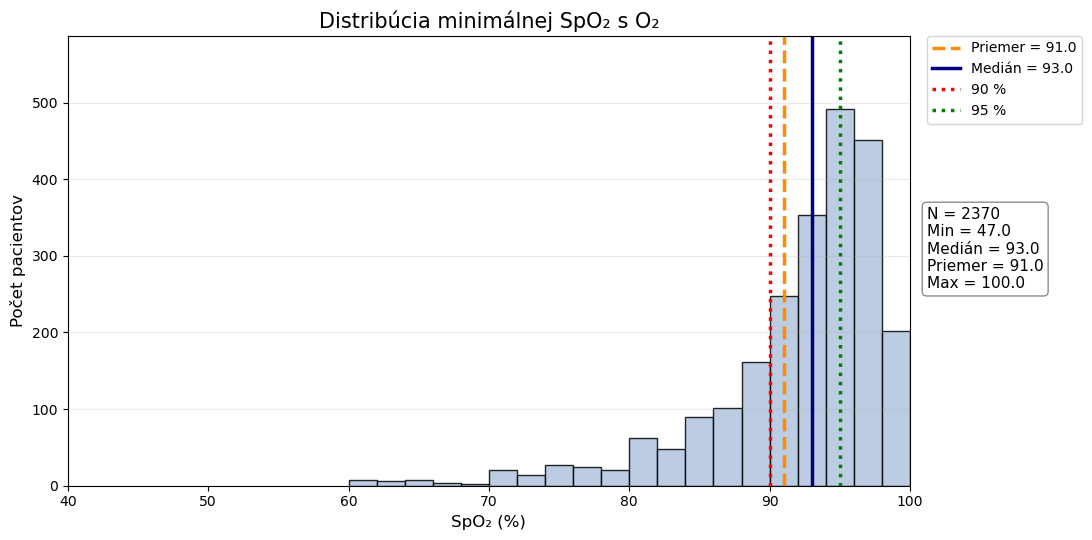

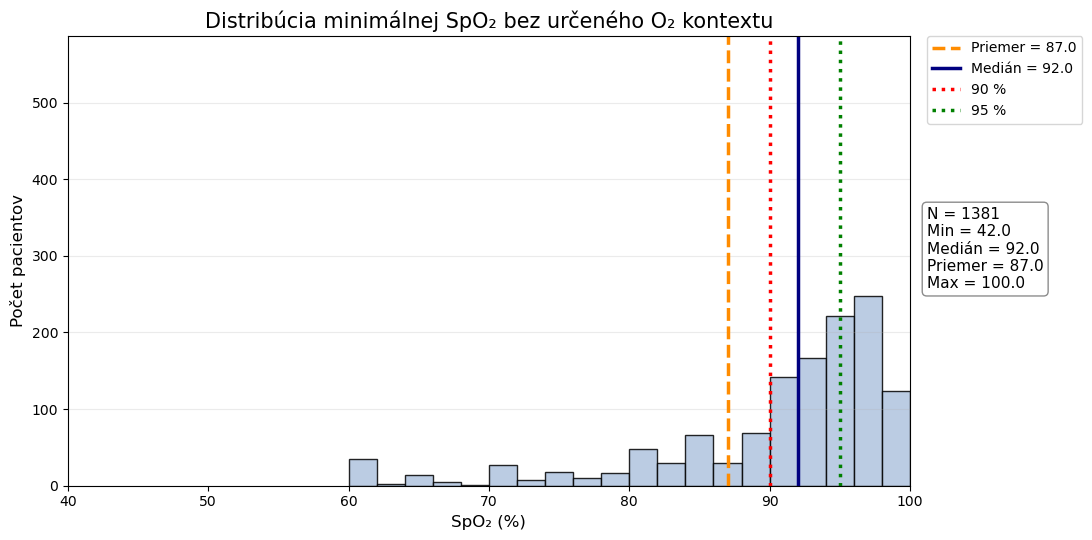

In [173]:
def plot_spo2_hist(series, title, bins=None, ymax=None):
    series = series.dropna()

    if len(series) == 0:
        print(f"Pre graf '{title}' nie sú dostupné žiadne údaje.")
        return

    # ak bins nie sú zadané, vytvor ich automaticky
    if bins is None:
        bins = range(60, 102, 2)

    mean_val = series.mean()
    median_val = series.median()
    min_val = series.min()
    max_val = series.max()
    n_val = len(series)

    plt.figure(figsize=(11, 5.5))

    # Histogram
    plt.hist(
        series,
        bins=bins,
        color="lightsteelblue",
        edgecolor="black",
        linewidth=1,
        alpha=0.85
    )

    # Vodiace čiary
    plt.axvline(
        mean_val,
        color="darkorange",
        linestyle="--",
        linewidth=2.5,
        label=f"Priemer = {mean_val:.1f}"
    )

    plt.axvline(
        median_val,
        color="navy",
        linestyle="-",
        linewidth=2.5,
        label=f"Medián = {median_val:.1f}"
    )

    plt.axvline(
        90,
        color="red",
        linestyle=":",
        linewidth=2.5,
        label="90 %"
    )

    plt.axvline(
        95,
        color="green",
        linestyle=":",
        linewidth=2.5,
        label="95 %"
    )

    # Osi a titulok
    plt.title(title, fontsize=15)
    plt.xlabel("SpO₂ (%)", fontsize=12)
    plt.ylabel("Počet pacientov", fontsize=12)

    plt.xlim(40, 100)

    if ymax is not None:
        plt.ylim(0, ymax + 20)

    # Mriežka
    plt.grid(axis="y", alpha=0.25)

    # Info box
    info_text = (
        f"N = {n_val}\n"
        f"Min = {min_val:.1f}\n"
        f"Medián = {median_val:.1f}\n"
        f"Priemer = {mean_val:.1f}\n"
        f"Max = {max_val:.1f}"
    )

    ax = plt.gca()

    # Legenda mimo grafu
    ax.legend(
        loc="upper left",
        bbox_to_anchor=(1.02, 1.00),
        borderaxespad=0.,
        frameon=True
    )

    # Box s číslami mimo grafu
    ax.text(
        1.02,
        0.62,
        info_text,
        transform=ax.transAxes,
        ha="left",
        va="top",
        fontsize=11,
        bbox=dict(
            boxstyle="round",
            facecolor="white",
            edgecolor="gray",
            alpha=0.9
        )
    )

    plt.subplots_adjust(right=0.78)
    plt.tight_layout()
    plt.show()

spo2_series = {
    "Distribúcia minimálnej SpO₂ bez O₂": df_f["sat_bez_o2_min"],
    "Distribúcia minimálnej SpO₂ s O₂": df_f["sat_s_o2_min"],
    "Distribúcia minimálnej SpO₂ bez určeného O₂ kontextu": df_f["sat_neurcene_min"],
}

# spoločné bins
bins = range(60, 102, 2)

# spoločný ymax, aby všetky grafy mali rovnakú výšku osi Y
global_ymax = 0
for series in spo2_series.values():
    clean_series = series.dropna()
    if len(clean_series) > 0:
        counts, _ = np.histogram(clean_series, bins=bins)
        global_ymax = max(global_ymax, counts.max())


for title, series in spo2_series.items():
    plot_spo2_hist(series, title, bins=bins, ymax=global_ymax)

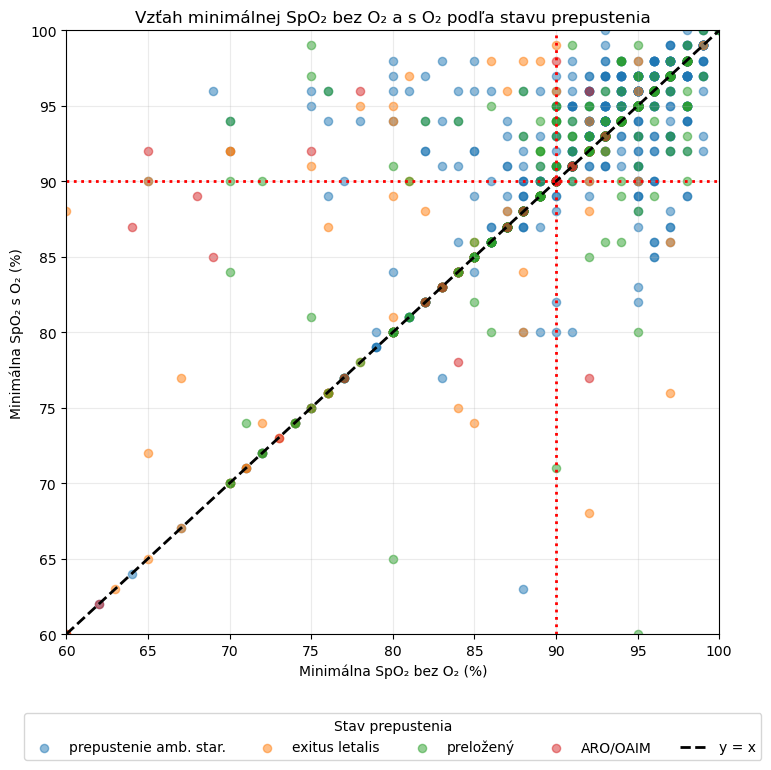

In [174]:
spo2_pair_df = df_f[
    ["sat_bez_o2_min", "sat_s_o2_min", "Stav prepustenia"]
].dropna().copy()

spo2_pair_df["rozdiel_s_o2_minus_bez_o2"] = (
    spo2_pair_df["sat_s_o2_min"] - spo2_pair_df["sat_bez_o2_min"]
)

plt.figure(figsize=(8, 8))

for status in spo2_pair_df["Stav prepustenia"].unique():
    subset = spo2_pair_df[
        spo2_pair_df["Stav prepustenia"] == status
    ]

    plt.scatter(
        subset["sat_bez_o2_min"],
        subset["sat_s_o2_min"],
        alpha=0.5,
        s=35,
        label=status
    )

# diagonála y = x
plt.plot(
    [60, 100],
    [60, 100],
    linestyle="--",
    linewidth=2,
    color="black",
    label="y = x"
)

# klinické hranice
plt.axvline(90, linestyle=":", linewidth=2, color="red")
plt.axhline(90, linestyle=":", linewidth=2, color="red")

plt.title("Vzťah minimálnej SpO₂ bez O₂ a s O₂ podľa stavu prepustenia")
plt.xlabel("Minimálna SpO₂ bez O₂ (%)")
plt.ylabel("Minimálna SpO₂ s O₂ (%)")

plt.xlim(60, 100)
plt.ylim(60, 100)

plt.grid(alpha=0.25)

plt.legend(
    title="Stav prepustenia",
    loc="upper center",
    bbox_to_anchor=(0.5, -0.12),
    ncol=5,
    frameon=True
)

plt.tight_layout()
plt.subplots_adjust(bottom=0.2)
plt.show()

['Kategória', 'Bez O₂ N', 'Bez O₂ %', 'S O₂ N', 'S O₂ %', 'Neurčené N', 'Neurčené %']


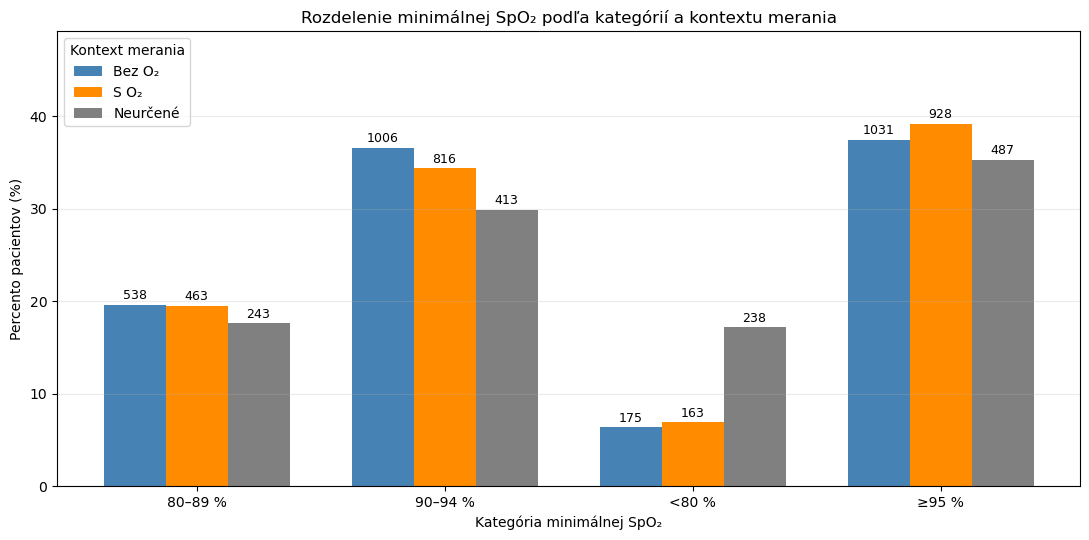

In [175]:

t_bez = spo2_category_table(df_f["sat_bez_o2_min"], "Bez O₂")
t_o2 = spo2_category_table(df_f["sat_s_o2_min"], "S O₂")
t_neurcene = spo2_category_table(df_f["sat_neurcene_min"], "Neurčené")

final_table = (
    t_bez
    .merge(t_o2, on="Kategória", how="outer")
    .merge(t_neurcene, on="Kategória", how="outer")
    .fillna(0)
)

print(final_table.columns.tolist())

x = np.arange(len(final_table["Kategória"]))
width = 0.25

plt.figure(figsize=(11, 5.5))

bars_bez = plt.bar(
    x - width,
    final_table["Bez O₂ %"],
    width,
    label="Bez O₂",
    color="steelblue"
)

bars_o2 = plt.bar(
    x,
    final_table["S O₂ %"],
    width,
    label="S O₂",
    color="darkorange"
)

bars_neurcene = plt.bar(
    x + width,
    final_table["Neurčené %"],
    width,
    label="Neurčené",
    color="gray"
)

# Počty nad stĺpcami
for bars, n_col in [
    (bars_bez, "Bez O₂ N"),
    (bars_o2, "S O₂ N"),
    (bars_neurcene, "Neurčené N")
]:
    for i, bar in enumerate(bars):
        n = int(final_table[n_col].iloc[i])

        plt.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.6,
            f"{n}",
            ha="center",
            fontsize=9
        )

plt.xticks(x, final_table["Kategória"])
plt.ylabel("Percento pacientov (%)")
plt.xlabel("Kategória minimálnej SpO₂")
plt.title("Rozdelenie minimálnej SpO₂ podľa kategórií a kontextu merania")

plt.grid(axis="y", alpha=0.25)
plt.legend(title="Kontext merania")

plt.ylim(
    0,
    max(
        final_table["Bez O₂ %"].max(),
        final_table["S O₂ %"].max(),
        final_table["Neurčené %"].max()
    ) + 10
)

plt.tight_layout()
plt.show()

In [176]:
df_f["has_sat_bez_o2"] = df_f["sat_bez_o2"].apply(
    lambda x: isinstance(x, list) and len(x) > 0
)

df_f["has_sat_s_o2"] = df_f["sat_s_o2"].apply(
    lambda x: isinstance(x, list) and len(x) > 0
)

df_f["has_sat_neurcene"] = df_f["sat_neurcene"].apply(
    lambda x: isinstance(x, list) and len(x) > 0
)

# Pacient má aspoň jednu zachytenú saturáciu v ktoromkoľvek kontexte
df_f["has_any_sat"] = (
    df_f["has_sat_bez_o2"] |
    df_f["has_sat_s_o2"] |
    df_f["has_sat_neurcene"]
)

# Pacient bez akejkoľvek zachytenej saturácie
df_f["no_sat"] = ~df_f["has_any_sat"]

# Počty
pocet_bez_o2 = df_f["has_sat_bez_o2"].sum()
pocet_s_o2 = df_f["has_sat_s_o2"].sum()
pocet_neurcene = df_f["has_sat_neurcene"].sum()
pocet_any_sat = df_f["has_any_sat"].sum()
pocet_no_sat = df_f["no_sat"].sum()

sat_availability_summary = pd.DataFrame({
    "Kategória": [
        "Bez O₂",
        "S O₂",
        "Neurčené",
        "Akákoľvek saturácia",
        "Bez saturácie"
    ],
    "Počet riadkov": [
        pocet_bez_o2,
        pocet_s_o2,
        pocet_neurcene,
        pocet_any_sat,
        pocet_no_sat
    ]
})

sat_availability_summary["Percento"] = (
    sat_availability_summary["Počet riadkov"] / len(df_f) * 100
).round(1)

sat_availability_summary

,Kategória,Počet riadkov,Percento
0,Bez O₂,2750,71.5
1,S O₂,2370,61.6
2,Neurčené,1381,35.9
3,Akákoľvek saturácia,3713,96.5
4,Bez saturácie,135,3.5


## 10. Prehľad dát a export 

In [177]:
#  Kontrola prítomnosti komorbidít a vakcinačných premenných
#  pred exportom finálneho datasetu
expected_feature_cols = [
    "Hypertenzia",
    "Diabetes mellitus",
    "Kardiovaskulárne ochorenia",
    "Chronické respiračné ochorenia",
    "Pečeňové ochorenia",
    "Onkologické ochorenia",
    "Imunosupresia",
    "Vakcinácia",
    "Typ vakcíny",
    "Počet dávok"
]

existing_feature_cols = [
    col for col in expected_feature_cols
    if col in df_f.columns
]

missing_feature_cols = [
    col for col in expected_feature_cols
    if col not in df_f.columns
]

print("Dostupné stĺpce vo df_f:")
print(existing_feature_cols)

print("\nChýbajúce stĺpce vo df_f:")
print(missing_feature_cols)

print("\nPočet dostupných z očakávaných stĺpcov:")
print(f"{len(existing_feature_cols)} / {len(expected_feature_cols)}")

Dostupné stĺpce vo df_f:
['Hypertenzia', 'Diabetes mellitus', 'Kardiovaskulárne ochorenia', 'Chronické respiračné ochorenia', 'Pečeňové ochorenia', 'Onkologické ochorenia', 'Imunosupresia', 'Vakcinácia', 'Typ vakcíny', 'Počet dávok']

Chýbajúce stĺpce vo df_f:
[]

Počet dostupných z očakávaných stĺpcov:
10 / 10


In [178]:
def analyze_pred_exportom(df: pd.DataFrame) -> pd.DataFrame:

    def classify_col(col: str) -> str:
        # časové údaje
        if col.endswith(("_datum_prva_hodnota", "_datum_posledna_hodnota")):
            return "lab_datum"
        # extrahované laboratórne hodnoty
        if col.endswith(("_prva_hodnota", "_minimum", "_median",
                         "_maximum", "_posledna_hodnota")):
            return "lab_summary"
        # status voči referenčnému rozsahu
        if col.endswith("_status"):
            return "lab_ref_status"
        # vypočítané indexy (CAR_prva, NLR_prva, ...)
        if col.endswith("_prva"):
            return "index"
        # saturácie a teploty
        if col.startswith("sat_"):
            return "saturacia"
        if col.startswith("temp_") or "teplota" in col.lower():
            return "teplota"
        # raw laboratóriá zo zdroja
        if col.startswith(("S-", "P-")):
            return "lab_raw"
        # meta
        if col in {"Poradie", "Meno", "Vek", "Pohlavie", "vlna",
                   "Dátum príjmu", "Dátum prepustenia",
                   "Kód príjmu", "Kód prepustenia",
                   "Stav prepustenia", "Skupiny_Kod_prepustenia",
                   "Pocet dni hospitalizacie", "Počet dní hospitalizácie"}:
            return "meta"
        # voľný text
        if col in {"Epikríza", "Epidemiologická anamnéza",
                   "Osobná anamnéza", "Diagnózy"}:
            return "text_source"
        # klinické príznaky / komorbidity / návyky / symptómy
        if col in {"Hypertenzia", "Diabetes mellitus",
                   "Kardiovaskulárne ochorenia", "Chronické respiračné ochorenia",
                   "Pečeňové ochorenia", "Onkologické ochorenia", "Imunosupresia",
                   "Vakcinácia", "Typ vakcíny", "Počet dávok",
                   "Fajčenie", "Alkohol",
                   "kasel", "hnacka", "triaska_zimnica",
                   "zvracanie", "nechutenstvo"}:
            return "feature_klinicka"
        return "ostatne"

    info = pd.DataFrame({
        "stlpec":   df.columns,
        "dtype":    df.dtypes.astype(str).values,
        "non_null": df.notna().sum().values,
        "nan_%":    (df.isna().mean() * 100).round(2).values,
        "skupina":  [classify_col(c) for c in df.columns],
    })

    n_rows, n_cols = df.shape
    mb = df.memory_usage(deep=True).sum() / 1024**2

    print(f"DataFrame: {n_rows} riadkov × {n_cols} stĺpcov   ({mb:.1f} MB)")
    print()
    print("Dtype prehľad:")
    print(df.dtypes.astype(str).value_counts().to_string())
    print()
    print("Stĺpce podľa skupiny:")
    print(info["skupina"].value_counts().to_string())
    print()
    print("Top 10 stĺpcov s najviac NaN:")
    print(info.sort_values("nan_%", ascending=False).head(10).to_string(index=False))

    return info.sort_values(["skupina", "stlpec"]).reset_index(drop=True)


def analyza_to_excel(info: pd.DataFrame, path: str) -> None:

    with pd.ExcelWriter(path, engine="openpyxl") as writer:
        info.to_excel(writer, index=False, sheet_name="stlpce")
        (info["skupina"].value_counts()
              .rename_axis("skupina").reset_index(name="pocet_stlpcov")
              .to_excel(writer, index=False, sheet_name="skupiny"))

        # približný auto-fit
        for ws in writer.sheets.values():
            for col_idx, _ in enumerate(ws[1], start=1):
                letter = get_column_letter(col_idx)
                values = [str(c.value) for c in ws[letter] if c.value is not None]
                max_len = max((len(v) for v in values), default=10)
                ws.column_dimensions[letter].width = max(12, min(60, max_len + 2))

    print(f"Analýza uložená: {path}")



In [179]:
def export_df_to_excel_full(
    df: pd.DataFrame,
    path: str,
    sheet_name: str = "data",
    date_width: int = 16,
    min_col_width: int = 10,
    max_col_width: int = 45,
):
  
    info = analyze_pred_exportom(df)  # vypíše súhrn + vráti DataFrame

    date_cols = [
        c for c in df.columns
        if ("Dátum" in c)
        or c.endswith("_datum_prva_hodnota")
        or c.endswith("_datum_posledna_hodnota")
    ]

    with pd.ExcelWriter(path, engine="openpyxl") as writer:
        # ===== Hárok 1: celé dáta =====
        df.to_excel(writer, index=False, sheet_name=sheet_name)
        ws = writer.sheets[sheet_name]

        for col_idx, col_name in enumerate(df.columns, start=1):
            letter = get_column_letter(col_idx)

            if col_name in date_cols:
                ws.column_dimensions[letter].width = date_width
                for row_idx in range(2, ws.max_row + 1):
                    cell = ws.cell(row=row_idx, column=col_idx)
                    cell.number_format = "DD.MM.YYYY"
                    cell.alignment = Alignment(horizontal="center")
            else:
                sample = df[col_name].astype(str).head(500)
                max_len = max([len(col_name)] + sample.map(len).tolist())
                ws.column_dimensions[letter].width = max(
                    min_col_width, min(max_col_width, max_len + 2)
                )

        for cell in ws[1]:
            cell.alignment = Alignment(
                wrap_text=True, horizontal="center", vertical="center"
            )

        # ===== Hárok 2: detail stĺpcov =====
        info.to_excel(writer, index=False, sheet_name="stlpce")

        # ===== Hárok 3: počty po skupinách =====
        (info["skupina"].value_counts()
              .rename_axis("skupina").reset_index(name="pocet_stlpcov")
              .to_excel(writer, index=False, sheet_name="skupiny"))

        # auto-fit pre analytické hárky
        for s in ("stlpce", "skupiny"):
            ws_a = writer.sheets[s]
            for col_idx, _ in enumerate(ws_a[1], start=1):
                letter = get_column_letter(col_idx)
                values = [str(c.value) for c in ws_a[letter] if c.value is not None]
                max_len = max((len(v) for v in values), default=10)
                ws_a.column_dimensions[letter].width = max(12, min(60, max_len + 2))

    print(f"Export hotový: {path}")
    print(f"   Hárky: '{sheet_name}', 'stlpce', 'skupiny'")


# Použitie pred parquet exportom
export_df_to_excel_full(df_f, "02_extrakcia_zo_stlpcov.xlsx", sheet_name="df_f")

DataFrame: 3848 riadkov × 671 stĺpcov   (88.0 MB)

Dtype prehľad:
float64           281
category          190
datetime64[ns]     96
object             71
bool               21
int64              12

Stĺpce podľa skupiny:
skupina
lab_summary         235
lab_ref_status      188
lab_datum            94
ostatne              46
index                36
lab_raw              29
feature_klinicka     15
meta                 11
saturacia             9
text_source           4
teplota               4

Top 10 stĺpcov s najviac NaN:
                        stlpec    dtype  non_null  nan_%        skupina
     S-AMS_prva_allowed_status category         0  100.0 lab_ref_status
   S-Bil-D_posledna_ref_status category         0  100.0 lab_ref_status
     S-IgA_posledna_ref_status category         0  100.0 lab_ref_status
       S-Bil-D_prva_ref_status category         0  100.0 lab_ref_status
S-Ig M_posledna_allowed_status category         0  100.0 lab_ref_status
    S-Ig M_posledna_ref_status category     

In [180]:
expected_feature_groups = {
    "index_cols": [
        "PLR_prva",
        "SII_prva",
        "CAR_prva",
        "DLR_prva",
        "DeRitis_prva",
        "CLIF_COVID_prva"
    ],
    "sat_cols": [
        "sat_bez_o2",
        "sat_s_o2",
        "sat_neurcene",
        "sat_bez_o2_min",
        "sat_s_o2_min",
        "sat_neurcene_min"
    ],
    "temp_cols": [
        "teploty",
        "temp_max",
        "temp_med",
        "temp_first",
        "febrilita",
        "hyperpyrexia"
    ],
    "symptom_cols": [
        "kasel",
        "hnacka",
        "triaska_zimnica",
        "zvracanie",
        "nechutenstvo"
    ],
    "comorbidity_cols": [
        "Hypertenzia",
        "Diabetes mellitus",
        "Kardiovaskulárne ochorenia",
        "Chronické respiračné ochorenia",
        "Pečeňové ochorenia",
        "Onkologické ochorenia",
        "Imunosupresia"
    ],
    "vaccination_cols": [
        "Vakcinácia",
        "Typ vakcíny",
        "Počet dávok"
    ]
}

for group_name, cols in expected_feature_groups.items():
    existing = [col for col in cols if col in df_f.columns]
    missing = [col for col in cols if col not in df_f.columns]

    print(f"\n{group_name}: {len(existing)} / {len(cols)}")
    print("Dostupné:", existing)
    print("Chýbajúce:", missing)


index_cols: 6 / 6
Dostupné: ['PLR_prva', 'SII_prva', 'CAR_prva', 'DLR_prva', 'DeRitis_prva', 'CLIF_COVID_prva']
Chýbajúce: []

sat_cols: 6 / 6
Dostupné: ['sat_bez_o2', 'sat_s_o2', 'sat_neurcene', 'sat_bez_o2_min', 'sat_s_o2_min', 'sat_neurcene_min']
Chýbajúce: []

temp_cols: 6 / 6
Dostupné: ['teploty', 'temp_max', 'temp_med', 'temp_first', 'febrilita', 'hyperpyrexia']
Chýbajúce: []

symptom_cols: 5 / 5
Dostupné: ['kasel', 'hnacka', 'triaska_zimnica', 'zvracanie', 'nechutenstvo']
Chýbajúce: []

comorbidity_cols: 7 / 7
Dostupné: ['Hypertenzia', 'Diabetes mellitus', 'Kardiovaskulárne ochorenia', 'Chronické respiračné ochorenia', 'Pečeňové ochorenia', 'Onkologické ochorenia', 'Imunosupresia']
Chýbajúce: []

vaccination_cols: 3 / 3
Dostupné: ['Vakcinácia', 'Typ vakcíny', 'Počet dávok']
Chýbajúce: []


## Export pre nadväzujúci notebook

In [181]:
out_parquet = "02_extrakcia_zo_stlpcov.parquet"

df_f.to_parquet(out_parquet, index=False)

print(f"Exportované: {out_parquet}")

Exportované: 02_extrakcia_zo_stlpcov.parquet


In [182]:
df_check = pd.read_parquet(out_parquet)
print(f"Exportované: {out_parquet}")
print(f"Tvar exportovaného datasetu: {df_check.shape}")

for group_name, cols in expected_feature_groups.items():
    existing = [col for col in cols if col in df_check.columns]
    missing = [col for col in cols if col not in df_check.columns]

    print(f"\n{group_name}: {len(existing)} / {len(cols)}")
    print("Dostupné:", existing)
    print("Chýbajúce:", missing)

Exportované: 02_extrakcia_zo_stlpcov.parquet
Tvar exportovaného datasetu: (3848, 671)

index_cols: 6 / 6
Dostupné: ['PLR_prva', 'SII_prva', 'CAR_prva', 'DLR_prva', 'DeRitis_prva', 'CLIF_COVID_prva']
Chýbajúce: []

sat_cols: 6 / 6
Dostupné: ['sat_bez_o2', 'sat_s_o2', 'sat_neurcene', 'sat_bez_o2_min', 'sat_s_o2_min', 'sat_neurcene_min']
Chýbajúce: []

temp_cols: 6 / 6
Dostupné: ['teploty', 'temp_max', 'temp_med', 'temp_first', 'febrilita', 'hyperpyrexia']
Chýbajúce: []

symptom_cols: 5 / 5
Dostupné: ['kasel', 'hnacka', 'triaska_zimnica', 'zvracanie', 'nechutenstvo']
Chýbajúce: []

comorbidity_cols: 7 / 7
Dostupné: ['Hypertenzia', 'Diabetes mellitus', 'Kardiovaskulárne ochorenia', 'Chronické respiračné ochorenia', 'Pečeňové ochorenia', 'Onkologické ochorenia', 'Imunosupresia']
Chýbajúce: []

vaccination_cols: 3 / 3
Dostupné: ['Vakcinácia', 'Typ vakcíny', 'Počet dávok']
Chýbajúce: []
